<a href="https://colab.research.google.com/github/najmul19/diabetics_classification_from_daily_activities/blob/main/Evaluation_the_models_and_performance_maping_peace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10 

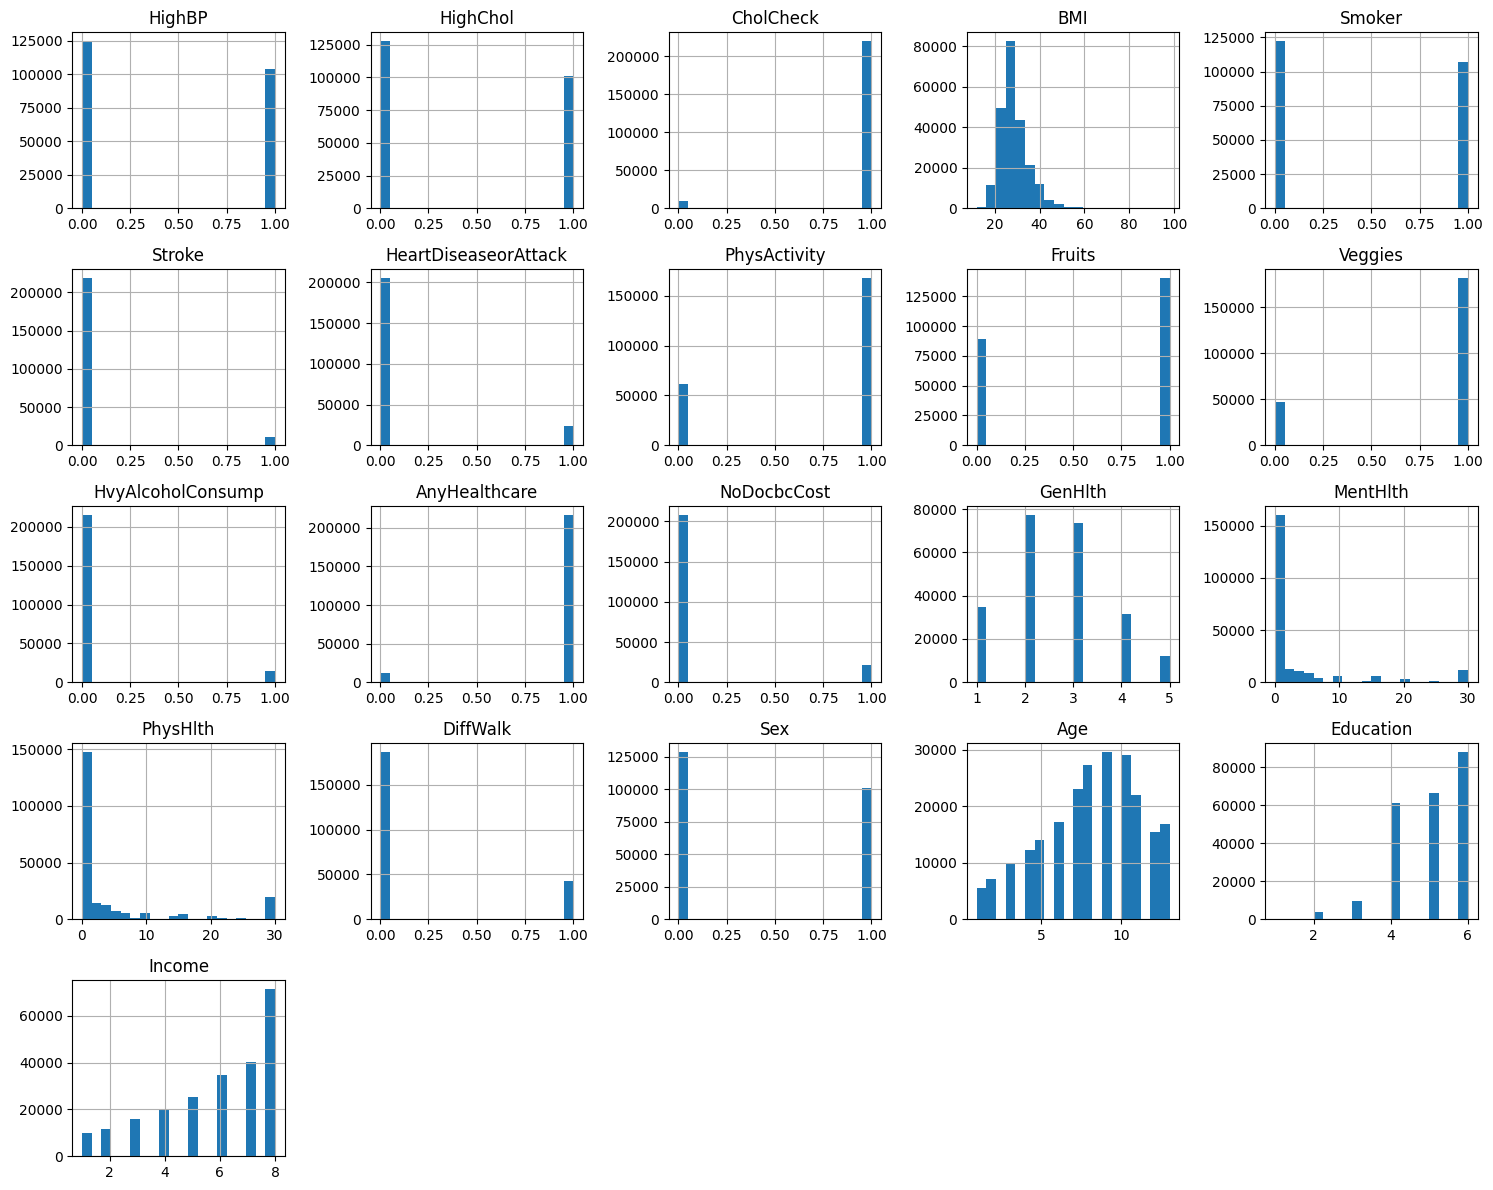

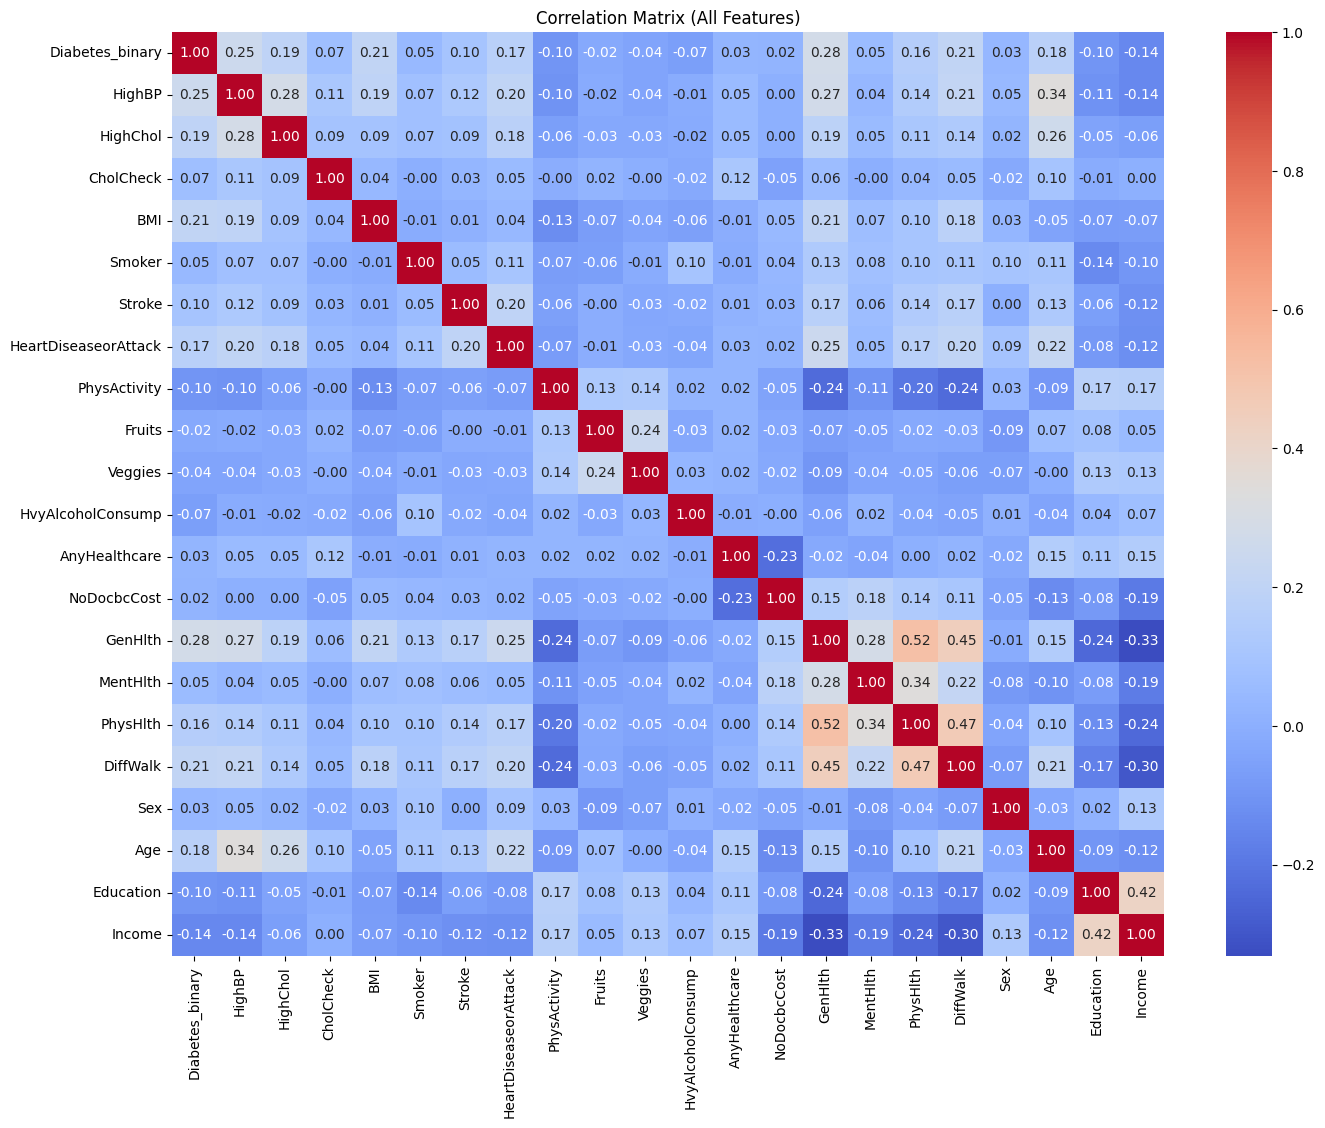

Correlation with Diabetes_binary:

GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
Phy

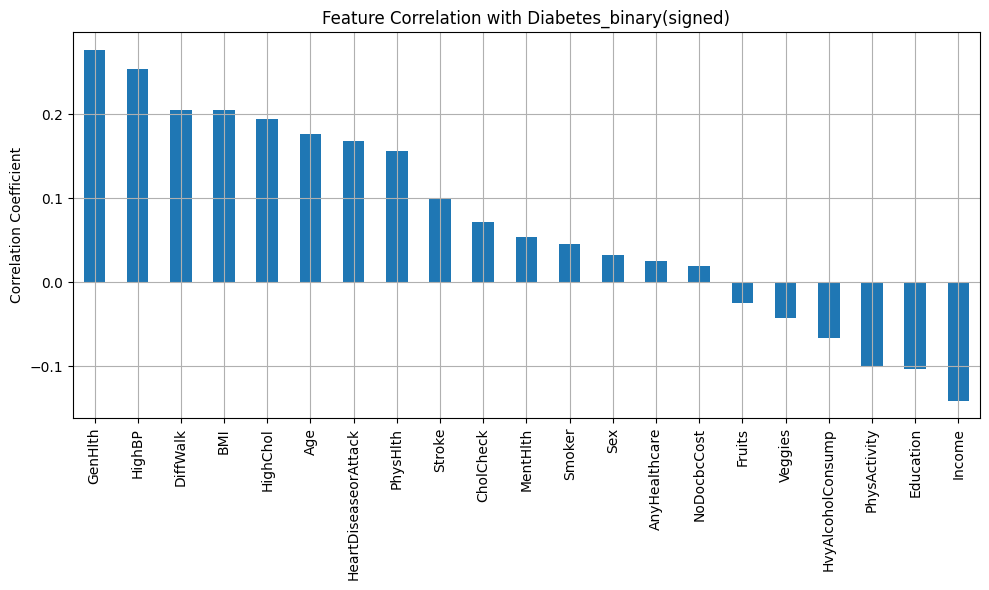

/tmp/ipython-input-1054288185.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=t_cor.values, y=t_cor.index, palette='coolwarm')


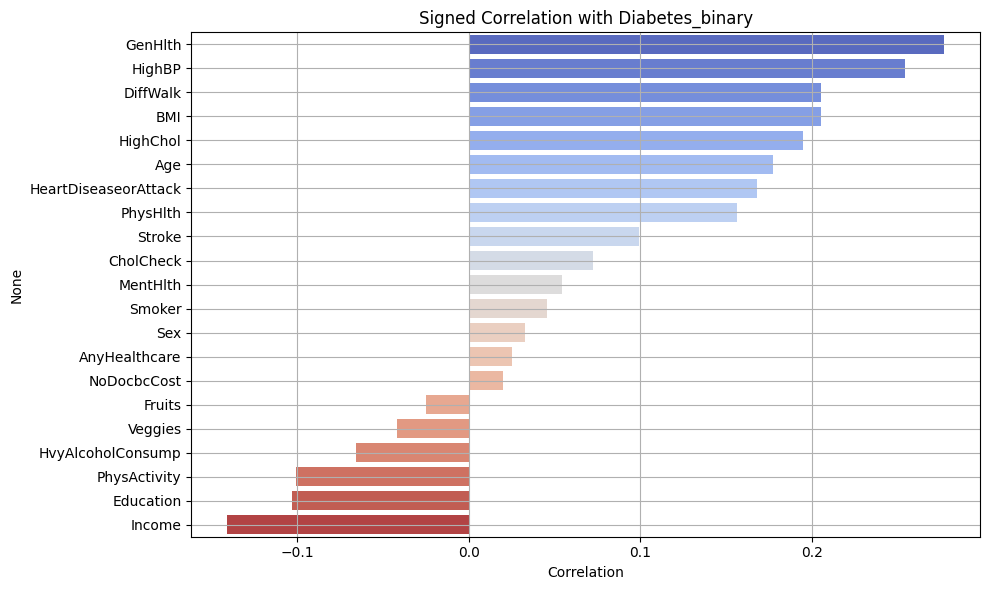

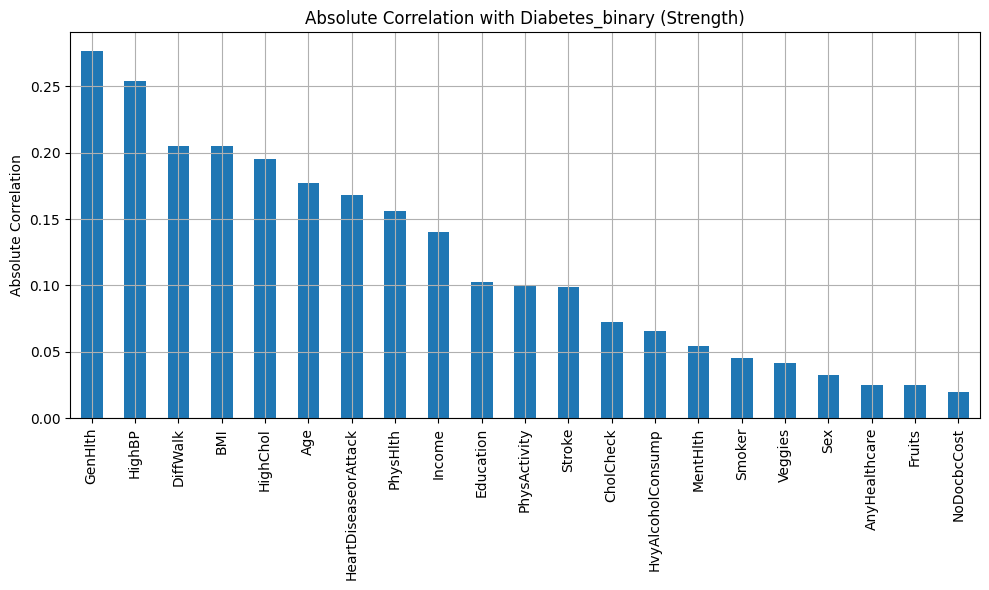

/tmp/ipython-input-1054288185.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_abs.values, y=corr_abs.index, palette='Blues_r')


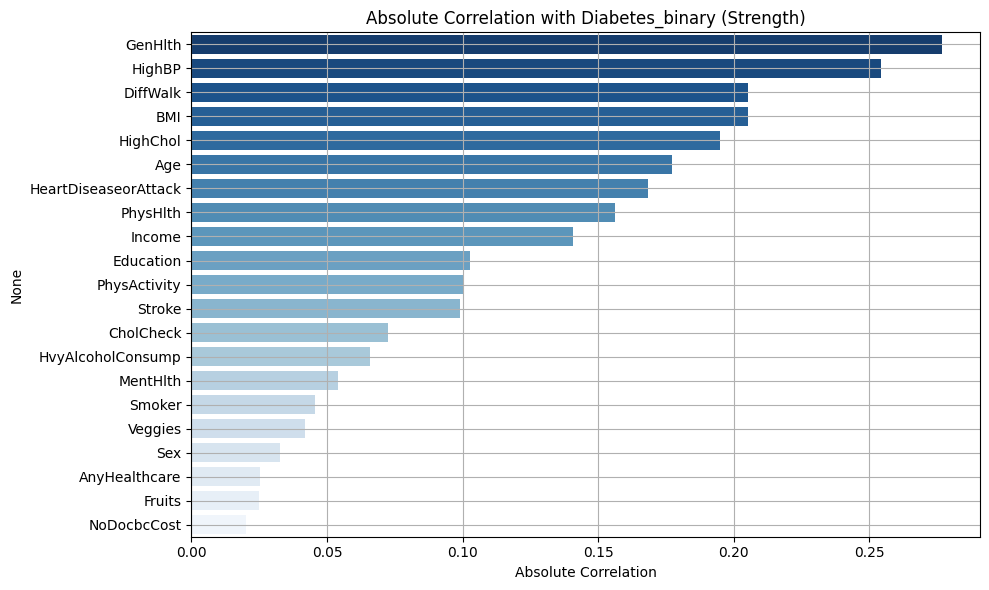

                 Feature       VIF
13               GenHlth  1.716096
15              PhysHlth  1.594297
16              DiffWalk  1.511628
20                Income  1.430313
18                   Age  1.353317
0                 HighBP  1.301200
19             Education  1.272080
14              MentHlth  1.221587
6   HeartDiseaseorAttack  1.167062
1               HighChol  1.158112
12           NoDocbcCost  1.135647
7           PhysActivity  1.130509
3                    BMI  1.121050
11         AnyHealthcare  1.109839
9                Veggies  1.098133
8                 Fruits  1.097947
5                 Stroke  1.077470
4                 Smoker  1.076032
17                   Sex  1.075743
2              CholCheck  1.035274
10     HvyAlcoholConsump  1.026354


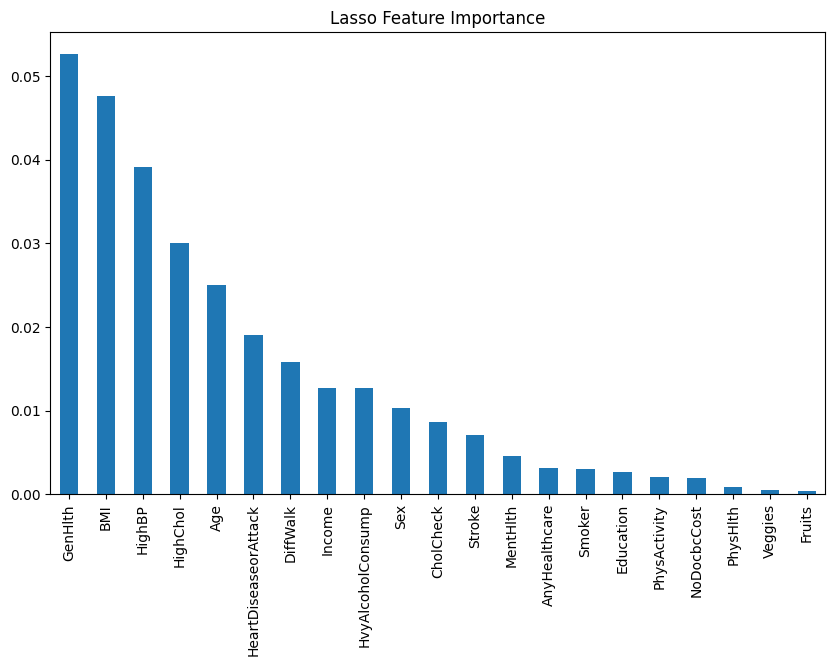

Top Features from RFE: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'Sex', 'Age', 'Income']


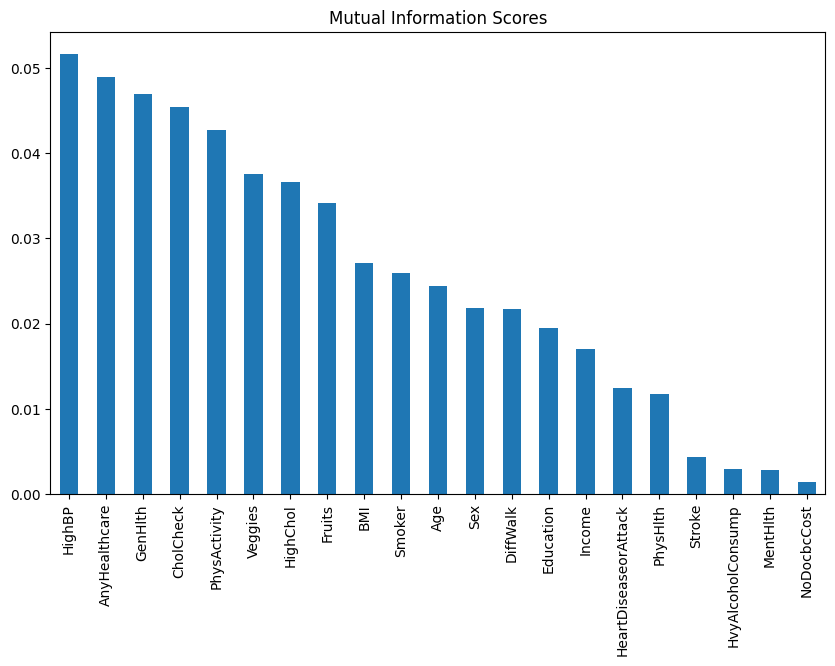


Combined Feature Rankings:
                      LassoRank  MIRank  RFERank  AverageRank
GenHlth                     1.0     3.0      4.0         2.67
HighBP                      3.0     1.0     10.0         4.67
BMI                         2.0     9.0      7.0         6.00
Age                         5.0    11.0      2.0         6.00
HighChol                    4.0     7.0      9.0         6.67
CholCheck                  11.0     4.0      8.0         7.67
Income                      8.0    15.0      1.0         8.00
Sex                        10.0    12.0      3.0         8.33
HeartDiseaseorAttack        6.0    16.0      6.0         9.33
HvyAlcoholConsump           9.0    19.0      5.0        11.00
AnyHealthcare              14.0     2.0     22.0        12.67
DiffWalk                    7.0    13.0     22.0        14.00
PhysActivity               17.0     5.0     22.0        14.67
Smoker                     15.0    10.0     22.0        15.67
Veggies                    20.0     6.0   

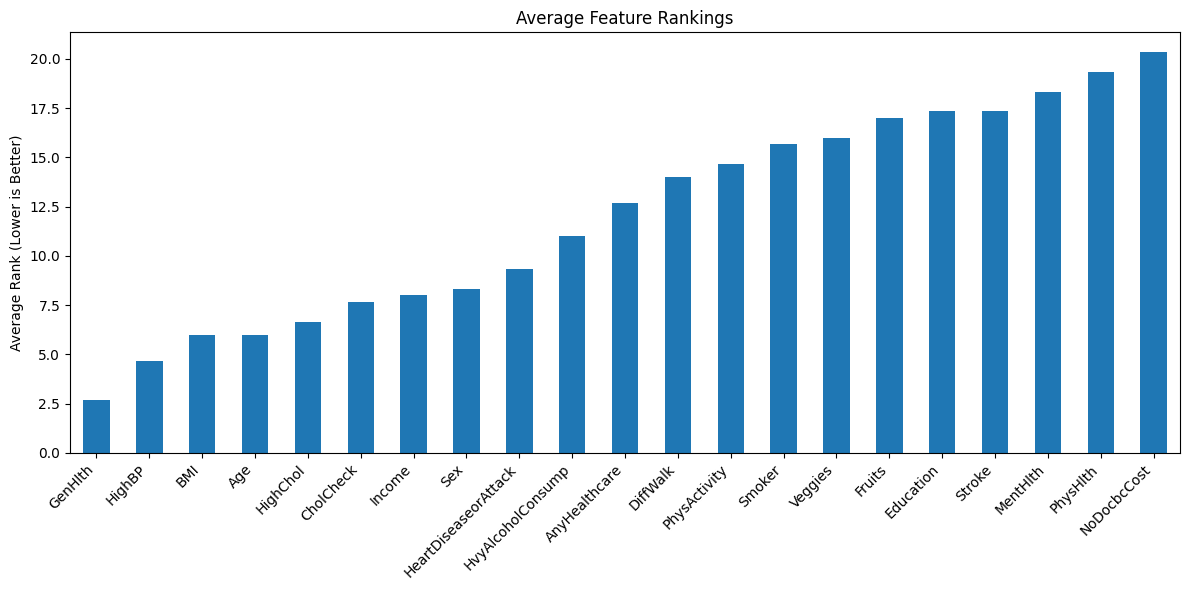

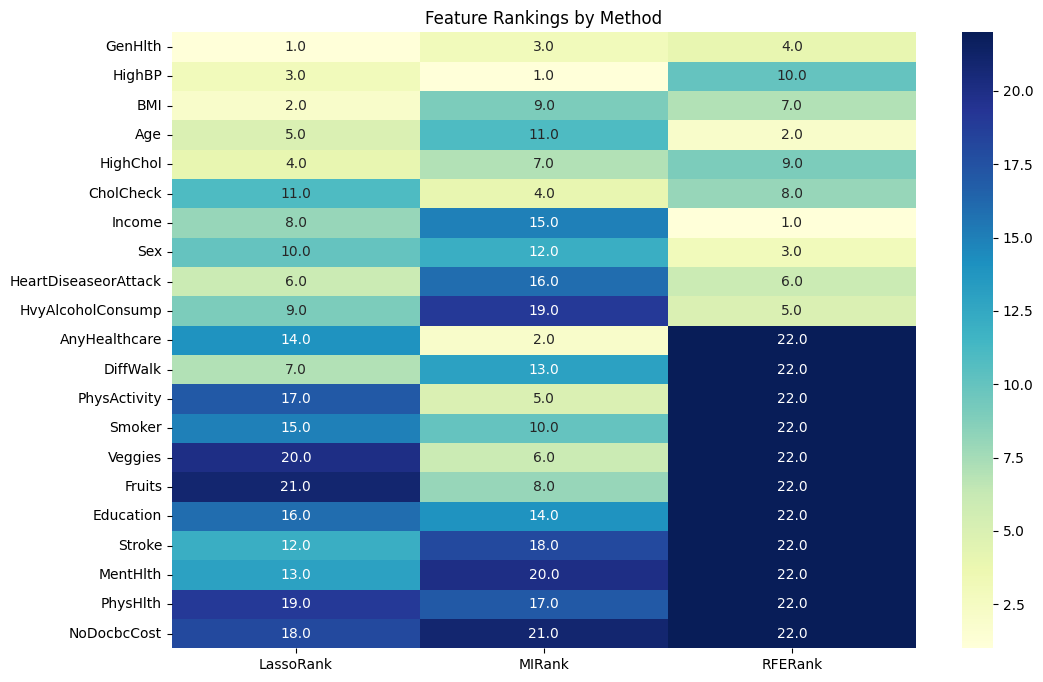

Original class distribution:
Diabetes_binary
0.0    194377
1.0     35097
Name: count, dtype: int64


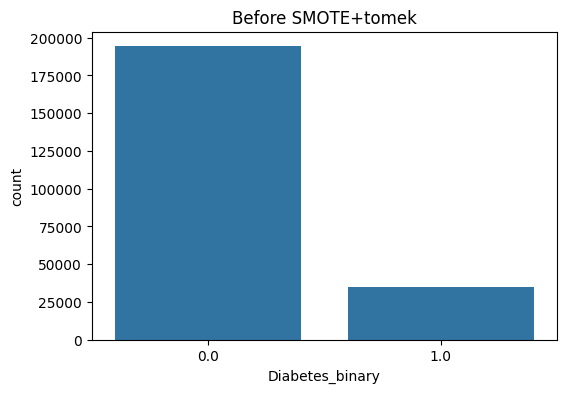

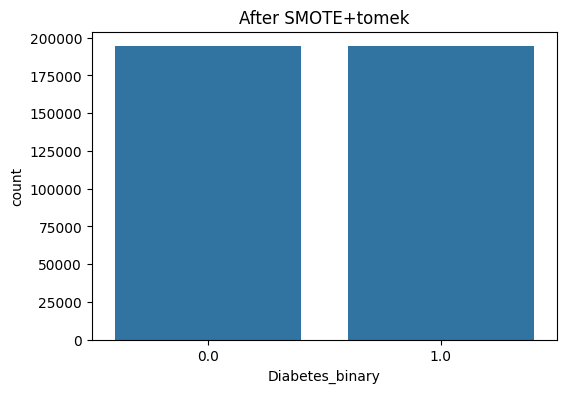

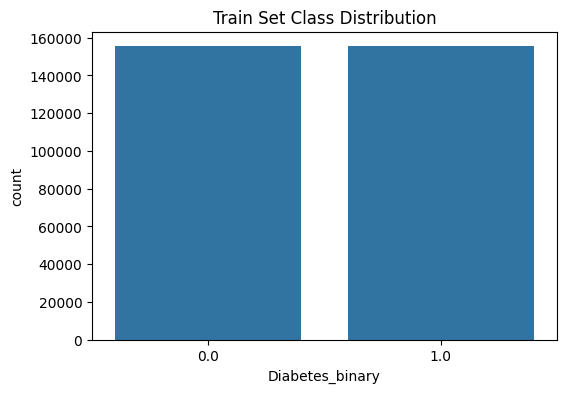

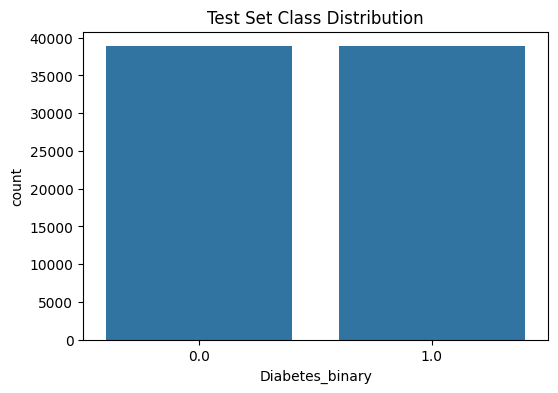

Train set:
 Diabetes_binary
0.0    0.5
1.0    0.5
Name: proportion, dtype: float64

Test set:
 Diabetes_binary
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64
Train set count:
 Diabetes_binary
0.0    155446
1.0    155446
Name: count, dtype: int64

Test set count:
 Diabetes_binary
1.0    38862
0.0    38862
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
df = pd.read_csv("/content/sample_data/diabetes_binary_health_indicators_BRFSS2015.csv")
df.head()
# Step 1: Data Preprocessing
# Check for nulls and data types
missing_values = df.isnull().sum()
missing_values
d_types = df.dtypes
d_types
#Check duplicate rows
duplicate_c = df.duplicated().sum()
duplicate_c
df
feature_names = df.drop("Diabetes_binary", axis=1).columns.tolist()
print(feature_names)
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]
X.head()
df.info()
#duplicates value remove
df = df.drop_duplicates()
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]
X,y
#Check duplicate rows again
duplicate_c = df.duplicated().sum()
duplicate_c
y.value_counts(normalize=True)
#See features have <1% variance
low_variance = (X.nunique() / len(X)) < 0.01
print(X.columns[low_variance])
#step2: feature analysis
import seaborn as sns
#histograms
X.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()
#Correlation Matrix(all features)
plt.figure(figsize=(16, 12))
c_matrix = df.corr(numeric_only=True)
sns.heatmap(c_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (All Features)")
plt.show()
#Correlation with Target
t_cor = c_matrix["Diabetes_binary"].drop("Diabetes_binary").sort_values(ascending=False)
print("Correlation with Diabetes_binary:\n")
print(t_cor)
#corr_abs t_cor = c_matrix["Diabetes_binary"].drop("Diabetes_binary").abs().sort_values(ascending=False)
corr_abs =t_cor.abs().sort_values(ascending=False)
#top correlated features
print(corr_abs)
#Visual correlations with target signed
plt.figure(figsize=(10, 6))
t_cor.plot(kind='bar')
plt.title("Feature Correlation with Diabetes_binary(signed)")
plt.ylabel("Correlation Coefficient")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
sns.barplot(x=t_cor.values, y=t_cor.index, palette='coolwarm')
plt.title("Signed Correlation with Diabetes_binary")
plt.xlabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()
#Visual absolute correlations
plt.figure(figsize=(10, 6))
corr_abs.plot(kind='bar')
plt.title("Absolute Correlation with Diabetes_binary (Strength)")
plt.ylabel("Absolute Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()
#Visual absolute correlations
plt.figure(figsize=(10, 6))
sns.barplot(x=corr_abs.values, y=corr_abs.index, palette='Blues_r')
plt.title("Absolute Correlation with Diabetes_binary (Strength)")
plt.xlabel("Absolute Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()
#Multicollinearity Check(VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_const = add_constant(X)
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]  # i+1 because of const
print(vif_data.sort_values("VIF", ascending=False))
#Feature Importance Using Lasso Regression(Selection)
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = LassoCV(cv=5, random_state=0)
lasso.fit(X_scaled, y)

feature_importance = pd.Series(np.abs(lasso.coef_), index=X.columns)
feature_importance = feature_importance[feature_importance > 0]
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,6), title="Lasso Feature Importance")
plt.show()
#Recursive Feature Elimination (RFE) with Logistic
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
rfe = RFE(model, n_features_to_select=10)
rfe.fit(X_scaled, y)

selected_features = X.columns[rfe.support_]
print("Top Features from RFE:", selected_features.tolist())
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
mi_series.plot(kind='bar', figsize=(10,6), title='Mutual Information Scores')
plt.show()
#Combine Feature Rankings

import pandas as pd

#Convert RFE feature list into ranking (1 = most important)
rfe_ranks = pd.Series(
    data=[len(selected_features) - i for i in range(len(selected_features))],
    index=selected_features,
    name='RFERank'
)
#Normalize Lasso & MI into Rankings
lasso_rank = feature_importance.abs().rank(ascending=False).rename('LassoRank')
mi_rank = mi_series.rank(ascending=False).rename('MIRank')
#Combine All Rankings into One DataFrame

feature_rank_df = pd.concat([lasso_rank, mi_rank, rfe_ranks], axis=1)

#Fill missing RFE ranks with worst rank(total number of features + 1)
feature_rank_df['RFERank'] = feature_rank_df['RFERank'].fillna(len(feature_rank_df) + 1)

#Compute Average Ranking
feature_rank_df['AverageRank'] = feature_rank_df[['LassoRank', 'MIRank', 'RFERank']].mean(axis=1)

#Sort by Average Ranking
combined_rank = feature_rank_df.sort_values(by='AverageRank')

print("\nCombined Feature Rankings:")
print(combined_rank.round(2))
#Bar plot of average ranks
combined_rank['AverageRank'].plot(kind='bar', figsize=(12,6), title='Average Feature Rankings')
plt.ylabel('Average Rank (Lower is Better)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
ordered_df = combined_rank.sort_values('AverageRank')

#Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(ordered_df[['LassoRank', 'MIRank', 'RFERank']], annot=True, cmap='YlGnBu', fmt=".1f")
plt.title("Feature Rankings by Method")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

#menually drop low imapacted feature
top_features = combined_rank.head(18).index.tolist()
X_selected = X[top_features]
X_selected
#Step 3: Balancing the Data using SMOTE
#before going to next step check it
print("Original class distribution:")
print(y.value_counts())
#start step3 from here, with SMOTE
#from imblearn.over_sampling import SMOTE
#smote = SMOTE(random_state=42)

#for x_selected
#X_resampled, y_resampled = smote.fit_resample(X_selected, y)
#X_resampled, y_resampled = smote.fit_resample(X, y)
# Before SMOTE
#plt.figure(figsize=(6,4))
#sns.countplot(x=y)
#plt.title("Before SMOTE")
#plt.show()

# After SMOTE
#plt.figure(figsize=(6,4))
#sns.countplot(x=y_resampled)
#plt.title("After SMOTE")
#plt.show()
#print(y_resampled.value_counts(normalize=True))
#step4: Train / Test split

# Use SMOTE + Tomek Links balanced data
#SMOTE + Tomek Links
from imblearn.combine import SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_bal, y_bal = smote_tomek.fit_resample(X_selected, y)
# Before SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Before SMOTE+tomek")
plt.show()

# After SMOTE
plt.figure(figsize=(6,4))
sns.countplot(x=y_bal)
plt.title("After SMOTE+tomek")
plt.show()

X_final = X_bal
y_final = y_bal
#train test, for testing it will be 20%
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)
# Training set distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Train Set Class Distribution")
plt.show()

# Testing set distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y_test)
plt.title("Test Set Class Distribution")
plt.show()
print("Train set:\n", y_train.value_counts(normalize=True))
print("\nTest set:\n", y_test.value_counts(normalize=True))
print("Train set count:\n", y_train.value_counts())
print("\nTest set count:\n", y_test.value_counts())


In [ ]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)  # or X_train after split
joblib.dump(scaler, "scaler.pkl")  # Save scaler


['scaler.pkl']

In [ ]:
X_selected

,GenHlth,HighBP,BMI,Age,HighChol,CholCheck,Income,Sex,HeartDiseaseorAttack,HvyAlcoholConsump,AnyHealthcare,DiffWalk,PhysActivity,Smoker,Veggies,Fruits,Education,Stroke
0,5.0,1.0,40.0,9.0,1.0,1.0,3.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,4.0,0.0
1,3.0,0.0,25.0,7.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,6.0,0.0
2,5.0,1.0,28.0,9.0,1.0,1.0,8.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,4.0,0.0
3,2.0,1.0,27.0,11.0,0.0,1.0,6.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,3.0,0.0
4,2.0,1.0,24.0,11.0,1.0,1.0,4.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,5.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,3.0,1.0,45.0,5.0,1.0,1.0,7.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,6.0,0.0
253676,4.0,1.0,18.0,11.0,1.0,1.0,4.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0
253677,1.0,0.0,28.0,2.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,5.0,0.0
253678,3.0,1.0,23.0,7.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,5.0,0.0


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


In [ ]:
import os

# Create a folder to store plots
os.makedirs("plots", exist_ok=True)

# Example of saving instead of just showing
X.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.savefig("plots/histograms.png", dpi=300, bbox_inches="tight")
plt.close()

# Correlation Matrix
plt.figure(figsize=(16, 12))
c_matrix = df.corr(numeric_only=True)
sns.heatmap(c_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (All Features)")
plt.savefig("plots/correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.close()

# Correlation with Target
plt.figure(figsize=(10, 6))
t_cor.plot(kind='bar')
plt.title("Feature Correlation with Diabetes_binary(signed)")
plt.ylabel("Correlation Coefficient")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/corr_signed_bar.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 6))
sns.barplot(x=t_cor.values, y=t_cor.index, palette='coolwarm')
plt.title("Signed Correlation with Diabetes_binary")
plt.xlabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/corr_signed_barplot.png", dpi=300, bbox_inches="tight")
plt.close()

# Absolute correlations
plt.figure(figsize=(10, 6))
corr_abs.plot(kind='bar')
plt.title("Absolute Correlation with Diabetes_binary (Strength)")
plt.ylabel("Absolute Correlation")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/abs_correlation_bar.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(10, 6))
sns.barplot(x=corr_abs.values, y=corr_abs.index, palette='Blues_r')
plt.title("Absolute Correlation with Diabetes_binary (Strength)")
plt.xlabel("Absolute Correlation")
plt.grid(True)
plt.tight_layout()
plt.savefig("plots/abs_correlation_barplot.png", dpi=300, bbox_inches="tight")
plt.close()

# Lasso Feature Importance
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,6), title="Lasso Feature Importance")
plt.savefig("plots/lasso_importance.png", dpi=300, bbox_inches="tight")
plt.close()

# Mutual Information
mi_series.plot(kind='bar', figsize=(10,6), title='Mutual Information Scores')
plt.savefig("plots/mutual_information.png", dpi=300, bbox_inches="tight")
plt.close()

# Combined Rankings
combined_rank['AverageRank'].plot(kind='bar', figsize=(12,6), title='Average Feature Rankings')
plt.ylabel('Average Rank (Lower is Better)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("plots/average_rankings.png", dpi=300, bbox_inches="tight")
plt.close()

# Heatmap of rankings
plt.figure(figsize=(12, 8))
sns.heatmap(ordered_df[['LassoRank', 'MIRank', 'RFERank','AverageRank']], annot=True, cmap='YlGnBu', fmt=".1f")
plt.title("Feature Rankings by Method")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.savefig("plots/feature_rankings_heatmap.png", dpi=300, bbox_inches="tight")
plt.close()

# SMOTE Distribution plots
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Before SMOTE+tomek")
plt.savefig("plots/before_smote.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(6,4))
sns.countplot(x=y_bal)
plt.title("After SMOTE+tomek")
plt.savefig("plots/after_smote.png", dpi=300, bbox_inches="tight")
plt.close()

# Train/Test Split Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y_train)
plt.title("Train Set Class Distribution")
plt.savefig("plots/train_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(6, 4))
sns.countplot(x=y_test)
plt.title("Test Set Class Distribution")
plt.savefig("plots/test_distribution.png", dpi=300, bbox_inches="tight")
plt.close()


/tmp/ipython-input-245531313.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=t_cor.values, y=t_cor.index, palette='coolwarm')
/tmp/ipython-input-245531313.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_abs.values, y=corr_abs.index, palette='Blues_r')


In [ ]:

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
L_GBM_params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": 7,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 1.0,
    "lambda_l2": 1.0,
    "n_estimators": 1000,
    "n_jobs": -1,
    "random_state": 42
}
lgbm = LGBMClassifier(**L_GBM_params)

knn=KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    p=1,
    n_jobs=-1
)


xgb = XGBClassifier(
    n_estimators=900,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


cat = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    task_type="CPU",
    verbose=0,
    od_type="Iter",
    od_wait=200
)








[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [06:23:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


                    Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                
LightGBM            0.910760   0.969361  0.848331  0.904817  0.965084
KNN                 0.902281   0.863474  0.955662  0.907232  0.941712
XGBoost             0.906308   0.964165  0.843982  0.900080  0.962846
RandomForest        0.909563   0.938868  0.876174  0.906438  0.967837
CatBoost            0.907415   0.959592  0.850647  0.901841  0.961927
LogisticRegression  0.738636   0.725726  0.767222  0.745897  0.813520
NaiveBayes          0.712852   0.668281  0.845269  0.746427  0.775023


FileNotFoundError: [Errno 2] No such file or directory: 'plots/base_model_comparison.png'

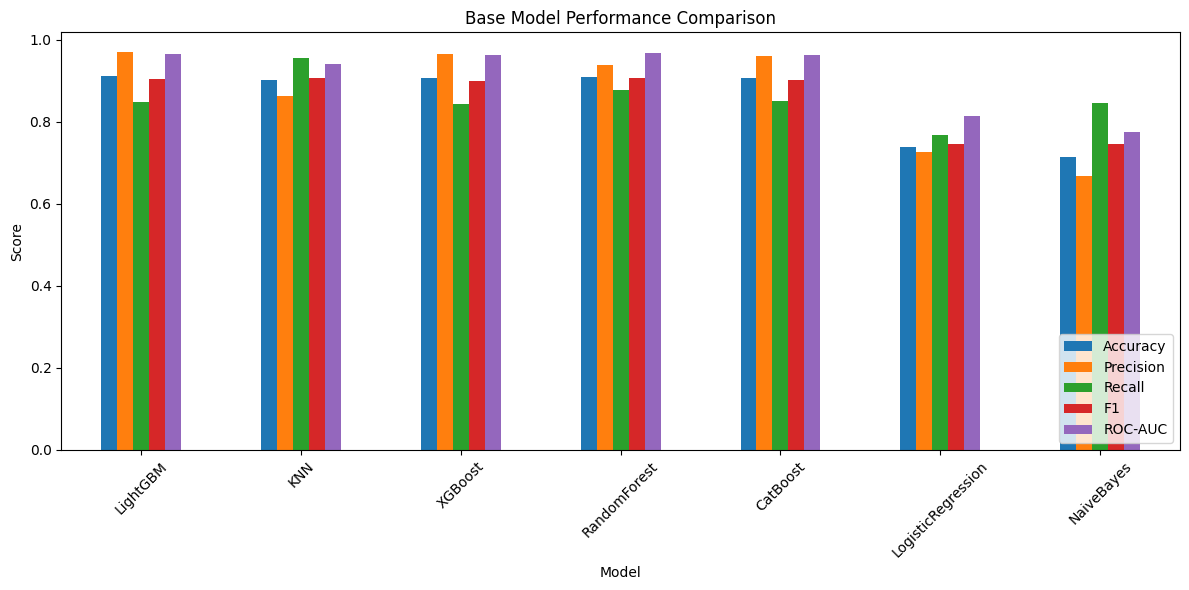

In [ ]:
# Step 5: Base Models Training & Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Define models
combine_models = {
    "LightGBM": lgbm,
    "KNN": knn,
    "XGBoost": xgb,
    "RandomForest": rf,
    "CatBoost": cat,
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "NaiveBayes": GaussianNB(),

}

results = []

for name, model in combine_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else None

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "ROC-AUC": auc
    })

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

# Plot model comparison
results_df.plot(kind="bar", figsize=(12,6))
plt.title("Base Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("base_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


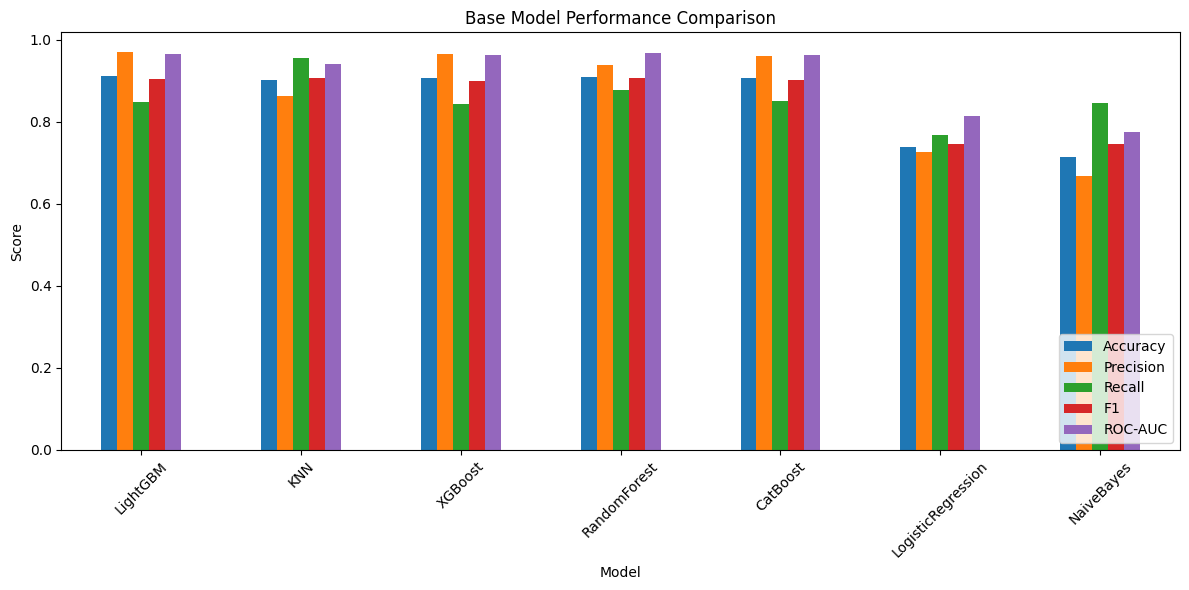

In [ ]:
# Plot model comparison
results_df.plot(kind="bar", figsize=(12,6))
plt.title("Base Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("base_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipython-input-3292293310.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('viridis', len(rank_df))
/tmp/ipython-input-3292293310.py:82: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax4.annotate(model, (metric, rank_df[metric][j]),


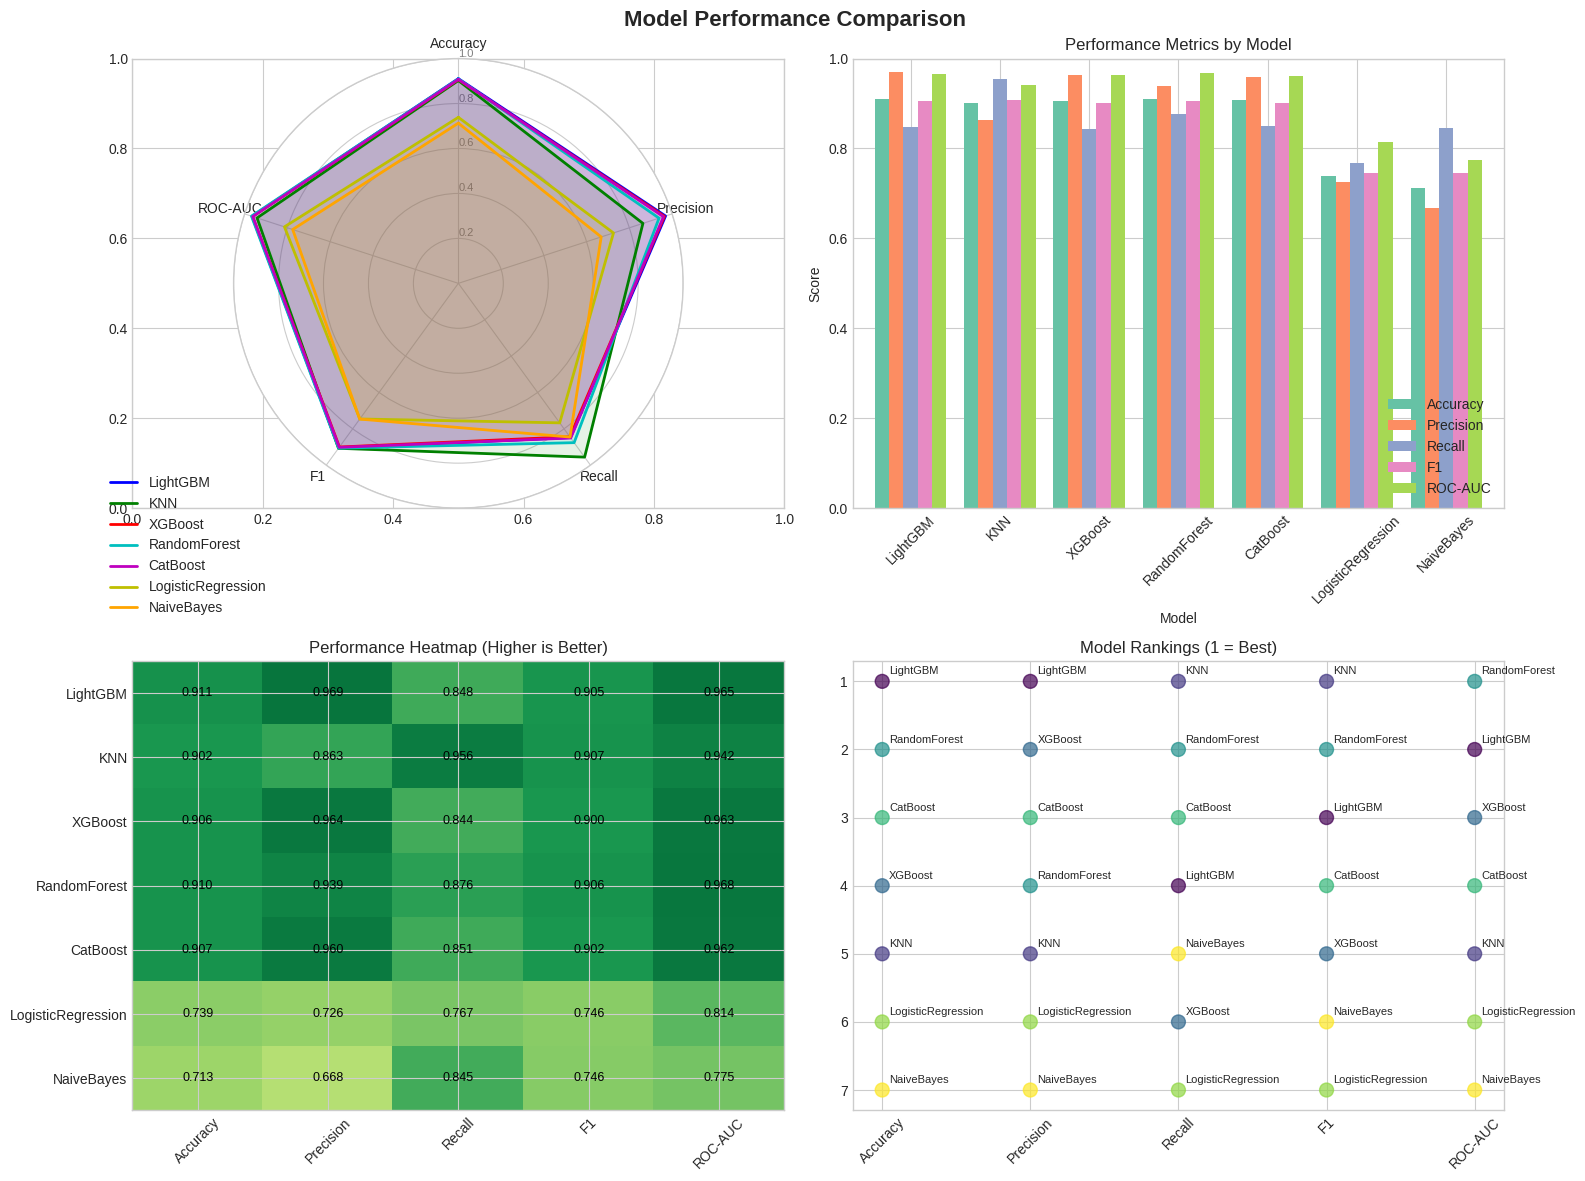

Model Performance Summary with Rankings:
                    Accuracy  Precision    Recall        F1   ROC-AUC  \
Model                                                                   
LightGBM            0.910760   0.969361  0.848331  0.904817  0.965084   
KNN                 0.902281   0.863474  0.955662  0.907232  0.941712   
XGBoost             0.906308   0.964165  0.843982  0.900080  0.962846   
RandomForest        0.909563   0.938868  0.876174  0.906438  0.967837   
CatBoost            0.907415   0.959592  0.850647  0.901841  0.961927   
LogisticRegression  0.738636   0.725726  0.767222  0.745897  0.813520   
NaiveBayes          0.712852   0.668281  0.845269  0.746427  0.775023   

                    Accuracy_Rank  Precision_Rank  Recall_Rank  F1_Rank  \
Model                                                                     
LightGBM                      1.0             1.0          4.0      3.0   
KNN                           5.0             5.0          1.0      1.0   
X

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set professional style for research paper
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Your existing code for model training and evaluation
# ... [your existing model training code] ...

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results).set_index("Model")

# Create a more comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# 1. Radar chart for comprehensive comparison
categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

# Create radar chart
ax = fig.add_subplot(2, 2, 1, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories)

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1)

# Plot each model
colors = ['b', 'g', 'r', 'c', 'm', 'y', 'orange', 'purple', 'brown', 'pink']

for i, (idx, row) in enumerate(results_df.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]  # Close the radar chart
    ax.plot(angles, values, color=colors[i], linewidth=2, linestyle='solid', label=idx)
    ax.fill(angles, values, color=colors[i], alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# 2. Bar chart with performance metrics
results_df.plot(kind='bar', ax=ax2, width=0.8)
ax2.set_title('Performance Metrics by Model')
ax2.set_ylabel('Score')
ax2.set_ylim(0, 1)
ax2.legend(loc='lower right')
ax2.tick_params(axis='x', rotation=45)

# 3. Heatmap for easy comparison
ax3.imshow(results_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(len(results_df.columns)))
ax3.set_yticks(range(len(results_df.index)))
ax3.set_xticklabels(results_df.columns, rotation=45)
ax3.set_yticklabels(results_df.index)

# Add text annotations on heatmap
for i in range(len(results_df.index)):
    for j in range(len(results_df.columns)):
        text = ax3.text(j, i, f'{results_df.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=9)
ax3.set_title('Performance Heatmap (Higher is Better)')

# 4. Ranking visualization
rank_df = results_df.rank(ascending=False)
colors = cm.get_cmap('viridis', len(rank_df))

for i, metric in enumerate(results_df.columns):
    ax4.scatter([metric]*len(rank_df), rank_df[metric],
               s=100, alpha=0.7, c=range(len(rank_df)), cmap='viridis')

    # Add model names
    for j, model in enumerate(rank_df.index):
        ax4.annotate(model, (metric, rank_df[metric][j]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

ax4.set_yticks(range(1, len(rank_df)+1))
ax4.invert_yaxis()  # So rank 1 is at the top
ax4.set_title('Model Rankings (1 = Best)')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("comprehensive_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Create a summary table with rankings
summary_df = results_df.copy()
for col in results_df.columns:
    summary_df[f'{col}_Rank'] = results_df[col].rank(ascending=False)

print("Model Performance Summary with Rankings:")
print("="*60)
print(summary_df)

# Find best model for each metric
best_models = {}
for metric in results_df.columns:
    best_idx = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    best_models[metric] = (best_idx, best_value)

print("\nBest Performing Models by Metric:")
print("="*40)
for metric, (model, value) in best_models.items():
    print(f"{metric}: {model} ({value:.4f})")

# Calculate overall ranking (average rank across all metrics)
overall_rank = summary_df[[col for col in summary_df.columns if 'Rank' in col]].mean(axis=1)
overall_rank.name = 'Overall_Rank'
best_overall = overall_rank.idxmin()

print(f"\nBest Overall Model: {best_overall} (Average Rank: {overall_rank.min():.2f})")

In [ ]:
import numpy as np
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, classification_report


estimators = [
   ('knn',knn),
    ('xgb', xgb),
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LGBMClassifier(random_state=42, n_estimators=200, learning_rate=0.03),
    cv=5,
    passthrough=True,
    stack_method='predict_proba',
)

# Fit
stacking.fit(X_train, y_train)



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:22:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:54:16] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:55:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:55:45] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [19:56:32] WARNING: /w

[LightGBM] [Info] Number of positive: 155446, number of negative: 155446
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.139067 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5099
[LightGBM] [Info] Number of data points in the train set: 310892, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


StackingClassifier(cv=5,
                   estimators=[('knn',
                                KNeighborsClassifier(n_jobs=-1, n_neighbors=3,
                                                     p=1, weights='distance')),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0.8, device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              f...
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=8,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=900, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LGBMClassifier(learning_rate=0.03,
                                                  n_estimators=200,
                                                  random_state=42),
                   passthrough=True, stack_method='predict_proba')

# ***Production***

In [ ]:
import joblib

joblib.dump(stacking, "diabetes_model.pkl")


['diabetes_model.pkl']

In [ ]:
y_proba_stack = stacking.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
y_pred_default = (y_proba_stack >= 0.5).astype(int)
print("Default Accuracy:", accuracy_score(y_test, y_pred_default))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_stack))
print("PR-AUC:", average_precision_score(y_test, y_proba_stack))
print(classification_report(y_test, y_pred_default))

Default Accuracy: 0.9467603314291596
ROC-AUC: 0.9891466818368726
PR-AUC: 0.9903952500252968
              precision    recall  f1-score   support

         0.0       0.96      0.93      0.95     38862
         1.0       0.93      0.96      0.95     38862

    accuracy                           0.95     77724
   macro avg       0.95      0.95      0.95     77724
weighted avg       0.95      0.95      0.95     77724



In [ ]:
y_pred_default = (y_proba_stack >= 0.5).astype(int)
print("Default Accuracy:", accuracy_score(y_test, y_pred_default))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_stack))
print("PR-AUC:", average_precision_score(y_test, y_proba_stack))
print(classification_report(y_test, y_pred_default))

Default Accuracy: 0.9476988793536019
ROC-AUC: 0.9894704852924163
PR-AUC: 0.9907061224596575
              precision    recall  f1-score   support

         0.0       0.96      0.93      0.95     38862
         1.0       0.93      0.96      0.95     38861

    accuracy                           0.95     77723
   macro avg       0.95      0.95      0.95     77723
weighted avg       0.95      0.95      0.95     77723



In [ ]:
best_acc = 0
best_thresh = 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_proba_stack >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print("\nBest Threshold:", best_thresh)
print("Best Accuracy:", best_acc)

y_pred_stacking = (y_proba_stack >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_stacking))


Best Threshold: 0.44999999999999984
Best Accuracy: 0.9482263937315852
              precision    recall  f1-score   support

         0.0       0.97      0.93      0.95     38862
         1.0       0.93      0.97      0.95     38861

    accuracy                           0.95     77723
   macro avg       0.95      0.95      0.95     77723
weighted avg       0.95      0.95      0.95     77723



In [ ]:
best_acc = 0
best_thresh = 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_proba_stack >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print("\nBest Threshold:", best_thresh)
print("Best Accuracy:", best_acc)

y_pred_stacking = (y_proba_stack >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_stacking))


Best Threshold: 0.46999999999999986
Best Accuracy: 0.9473264371365344
              precision    recall  f1-score   support

         0.0       0.97      0.93      0.95     38862
         1.0       0.93      0.97      0.95     38862

    accuracy                           0.95     77724
   macro avg       0.95      0.95      0.95     77724
weighted avg       0.95      0.95      0.95     77724



In [ ]:
# Evaluate Stacking model
y_proba_stack = stacking.predict_proba(X_test)[:, 1]
y_pred_stack = (y_proba_stack >= best_thresh).astype(int)  # using best threshold from your search

# Calculate metrics
acc = accuracy_score(y_test, y_pred_stack)
prec = precision_score(y_test, y_pred_stack)
rec = recall_score(y_test, y_pred_stack)
f1 = f1_score(y_test, y_pred_stack)
auc = roc_auc_score(y_test, y_proba_stack)

# Push into results
results.append({
    "Model": "Stacking",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1,
    "ROC-AUC": auc
})


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)


                    Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                
LightGBM            0.910760   0.969361  0.848331  0.904817  0.965084
KNN                 0.902281   0.863474  0.955662  0.907232  0.941712
XGBoost             0.906308   0.964165  0.843982  0.900080  0.962846
RandomForest        0.909563   0.938868  0.876174  0.906438  0.967837
CatBoost            0.907415   0.959592  0.850647  0.901841  0.961927
LogisticRegression  0.738636   0.725726  0.767222  0.745897  0.813520
NaiveBayes          0.712852   0.668281  0.845269  0.746427  0.775023
Stacking            0.948226   0.929334  0.970227  0.949340  0.989470


/tmp/ipython-input-1565398685.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax4.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])
/tmp/ipython-input-1565398685.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax4.annotate(model, (metric, rank_df[metric][j]),


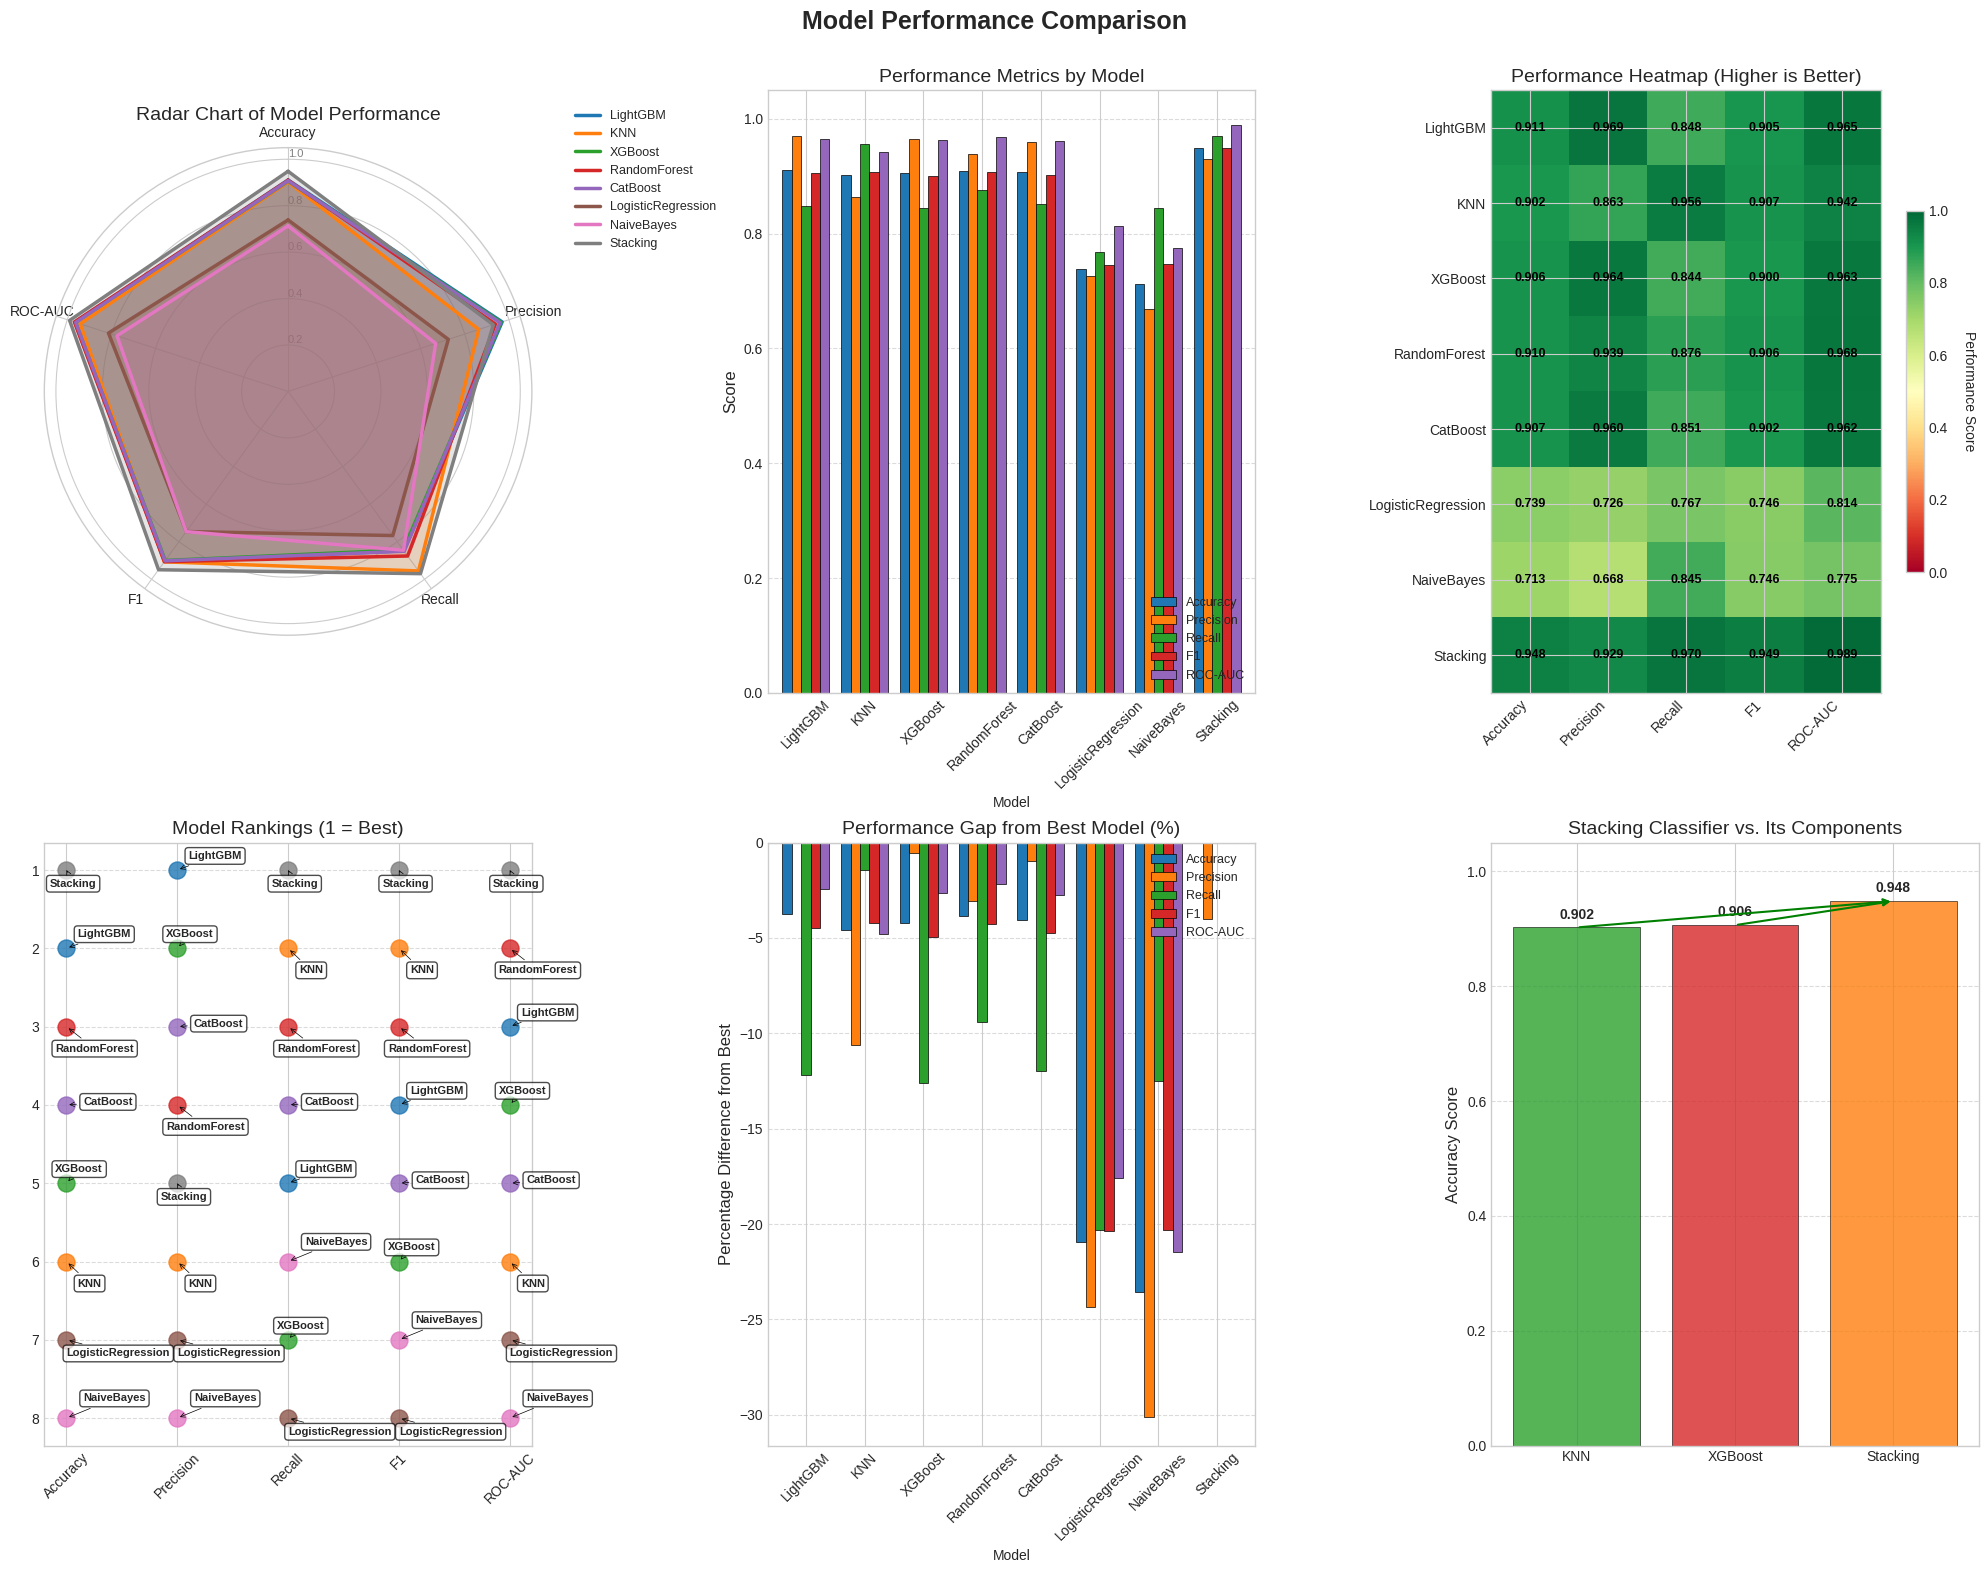

MODEL PERFORMANCE SUMMARY WITH RANKINGS
                    Accuracy  Precision  Recall      F1  ROC-AUC  \
Model                                                              
LightGBM              0.9108     0.9694  0.8483  0.9048   0.9651   
KNN                   0.9023     0.8635  0.9557  0.9072   0.9417   
XGBoost               0.9063     0.9642  0.8440  0.9001   0.9628   
RandomForest          0.9096     0.9389  0.8762  0.9064   0.9678   
CatBoost              0.9074     0.9596  0.8506  0.9018   0.9619   
LogisticRegression    0.7386     0.7257  0.7672  0.7459   0.8135   
NaiveBayes            0.7129     0.6683  0.8453  0.7464   0.7750   
Stacking              0.9482     0.9293  0.9702  0.9493   0.9895   

                    Accuracy_Rank  Precision_Rank  Recall_Rank  F1_Rank  \
Model                                                                     
LightGBM                      2.0             1.0          5.0      4.0   
KNN                           6.0             6.0     

In [ ]:
# Create a comprehensive visualization
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')

# 1. Radar chart for comprehensive comparison
ax1 = fig.add_subplot(2, 3, 1, polar=True)
categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontsize=10)

# Draw ylabels
ax1.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.05)

# Plot each model - using a color palette that works well with 8 models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
for i, (idx, row) in enumerate(results_df.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]  # Close the radar chart
    ax1.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=idx)
    ax1.fill(angles, values, color=colors[i], alpha=0.2)

ax1.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax1.set_title('Radar Chart of Model Performance', fontsize=14, pad=20)

# 2. Bar chart with performance metrics
ax2 = fig.add_subplot(2, 3, 2)
results_df.plot(kind='bar', ax=ax2, width=0.8, edgecolor='black', linewidth=0.5, color=colors)
ax2.set_title('Performance Metrics by Model', fontsize=14)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.legend(loc='lower right', fontsize=9)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Heatmap for easy comparison
ax3 = fig.add_subplot(2, 3, 3)
im = ax3.imshow(results_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(len(results_df.columns)))
ax3.set_yticks(range(len(results_df.index)))
ax3.set_xticklabels(results_df.columns, rotation=45, ha='right', fontsize=10)
ax3.set_yticklabels(results_df.index, fontsize=10)

# Add text annotations on heatmap
for i in range(len(results_df.index)):
    for j in range(len(results_df.columns)):
        text = ax3.text(j, i, f'{results_df.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=9, fontweight='bold')
ax3.set_title('Performance Heatmap (Higher is Better)', fontsize=14)

# Add colorbar for heatmap
cbar = plt.colorbar(im, ax=ax3, shrink=0.6)
cbar.set_label('Performance Score', rotation=270, labelpad=20)

# 4. Ranking visualization
ax4 = fig.add_subplot(2, 3, 4)
rank_df = results_df.rank(ascending=False)

# Create a scatter plot with consistent colors
for i, metric in enumerate(results_df.columns):
    for j, model in enumerate(rank_df.index):
        ax4.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])

        # Add model names with different offsets to avoid overlapping
        offsets = [(8, 8), (8, -18), (-8, 8), (-8, -18), (12, 0), (0, -12), (12, 12), (-12, -12)]
        ax4.annotate(model, (metric, rank_df[metric][j]),
                    xytext=offsets[j], textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0", lw=0.5))

ax4.set_yticks(range(1, len(rank_df)+1))
ax4.invert_yaxis()  # So rank 1 is at the top
ax4.set_title('Model Rankings (1 = Best)', fontsize=14)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Performance difference from best model
ax5 = fig.add_subplot(2, 3, 5)
best_scores = results_df.max()
performance_diff = (results_df - best_scores) * 100  # Convert to percentage difference

# Create a diverging colormap
performance_diff.plot(kind='bar', ax=ax5, width=0.8, color=colors, edgecolor='black', linewidth=0.5)
ax5.set_title('Performance Gap from Best Model (%)', fontsize=14)
ax5.set_ylabel('Percentage Difference from Best', fontsize=12)
ax5.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax5.tick_params(axis='x', rotation=45)
ax5.legend(loc='upper right', fontsize=9)
ax5.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Stacking classifier components visualization
ax6 = fig.add_subplot(2, 3, 6)

# Create a bar chart showing the performance of stacking vs its components
stacking_components = ['KNN', 'XGBoost', 'Stacking']
component_performance = [
    results_df.loc['KNN', 'Accuracy'],
    results_df.loc['XGBoost', 'Accuracy'],
    results_df.loc['Stacking', 'Accuracy']
]

bars = ax6.bar(stacking_components, component_performance,
               color=['#2ca02c', '#d62728', '#ff7f0e'],
               edgecolor='black', linewidth=0.5, alpha=0.8)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

ax6.set_ylabel('Accuracy Score', fontsize=12)
ax6.set_ylim(0, 1.05)
ax6.set_title('Stacking Classifier vs. Its Components', fontsize=14)
ax6.grid(axis='y', linestyle='--', alpha=0.7)

# Add improvement arrows
ax6.annotate('', xy=(2, results_df.loc['Stacking', 'Accuracy']),
            xytext=(0, results_df.loc['KNN', 'Accuracy']),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='green'))
ax6.annotate('', xy=(2, results_df.loc['Stacking', 'Accuracy']),
            xytext=(1, results_df.loc['XGBoost', 'Accuracy']),
            arrowprops=dict(arrowstyle='->', lw=1.5, color='green'))

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("comprehensive_model_comparison_with_stacking.png", dpi=300, bbox_inches="tight")
plt.show()

# Create a summary table with rankings
summary_df = results_df.copy()
for col in results_df.columns:
    summary_df[f'{col}_Rank'] = results_df[col].rank(ascending=False)

print("MODEL PERFORMANCE SUMMARY WITH RANKINGS")
print("="*80)
print(summary_df.round(4))

# Find best model for each metric
best_models = {}
for metric in results_df.columns:
    best_idx = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    best_models[metric] = (best_idx, best_value)

print("\nBEST PERFORMING MODELS BY METRIC")
print("="*50)
for metric, (model, value) in best_models.items():
    print(f"{metric:15}: {model:20} ({value:.4f})")

# Calculate overall ranking (average rank across all metrics)
overall_rank = summary_df[[col for col in summary_df.columns if 'Rank' in col]].mean(axis=1)
overall_rank.name = 'Overall_Rank'
best_overall = overall_rank.idxmin()

print(f"\nBEST OVERALL MODEL: {best_overall} (Average Rank: {overall_rank.min():.2f})")

# Compare stacking vs best base model (excluding Stacking itself)
base_models_df = results_df.drop('Stacking')
best_base_model = base_models_df.mean(axis=1).idxmax()
improvement = (results_df.loc['Stacking'] - results_df.loc[best_base_model]) / results_df.loc[best_base_model] * 100

print(f"\nSTACKING IMPROVEMENT OVER BEST BASE MODEL ({best_base_model})")
print("="*60)
for metric in results_df.columns:
    print(f"{metric:15}: {improvement[metric]:+7.2f}%")

# Additional analysis - show where Stacking excels the most
print(f"\nSTACKING EXCELS MOST IN: {improvement.idxmax()} ({improvement.max():.2f}% improvement)")

/tmp/ipython-input-316004389.py:68: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax4.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])
/tmp/ipython-input-316004389.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax4.annotate(model, (metric, rank_df[metric][j]),


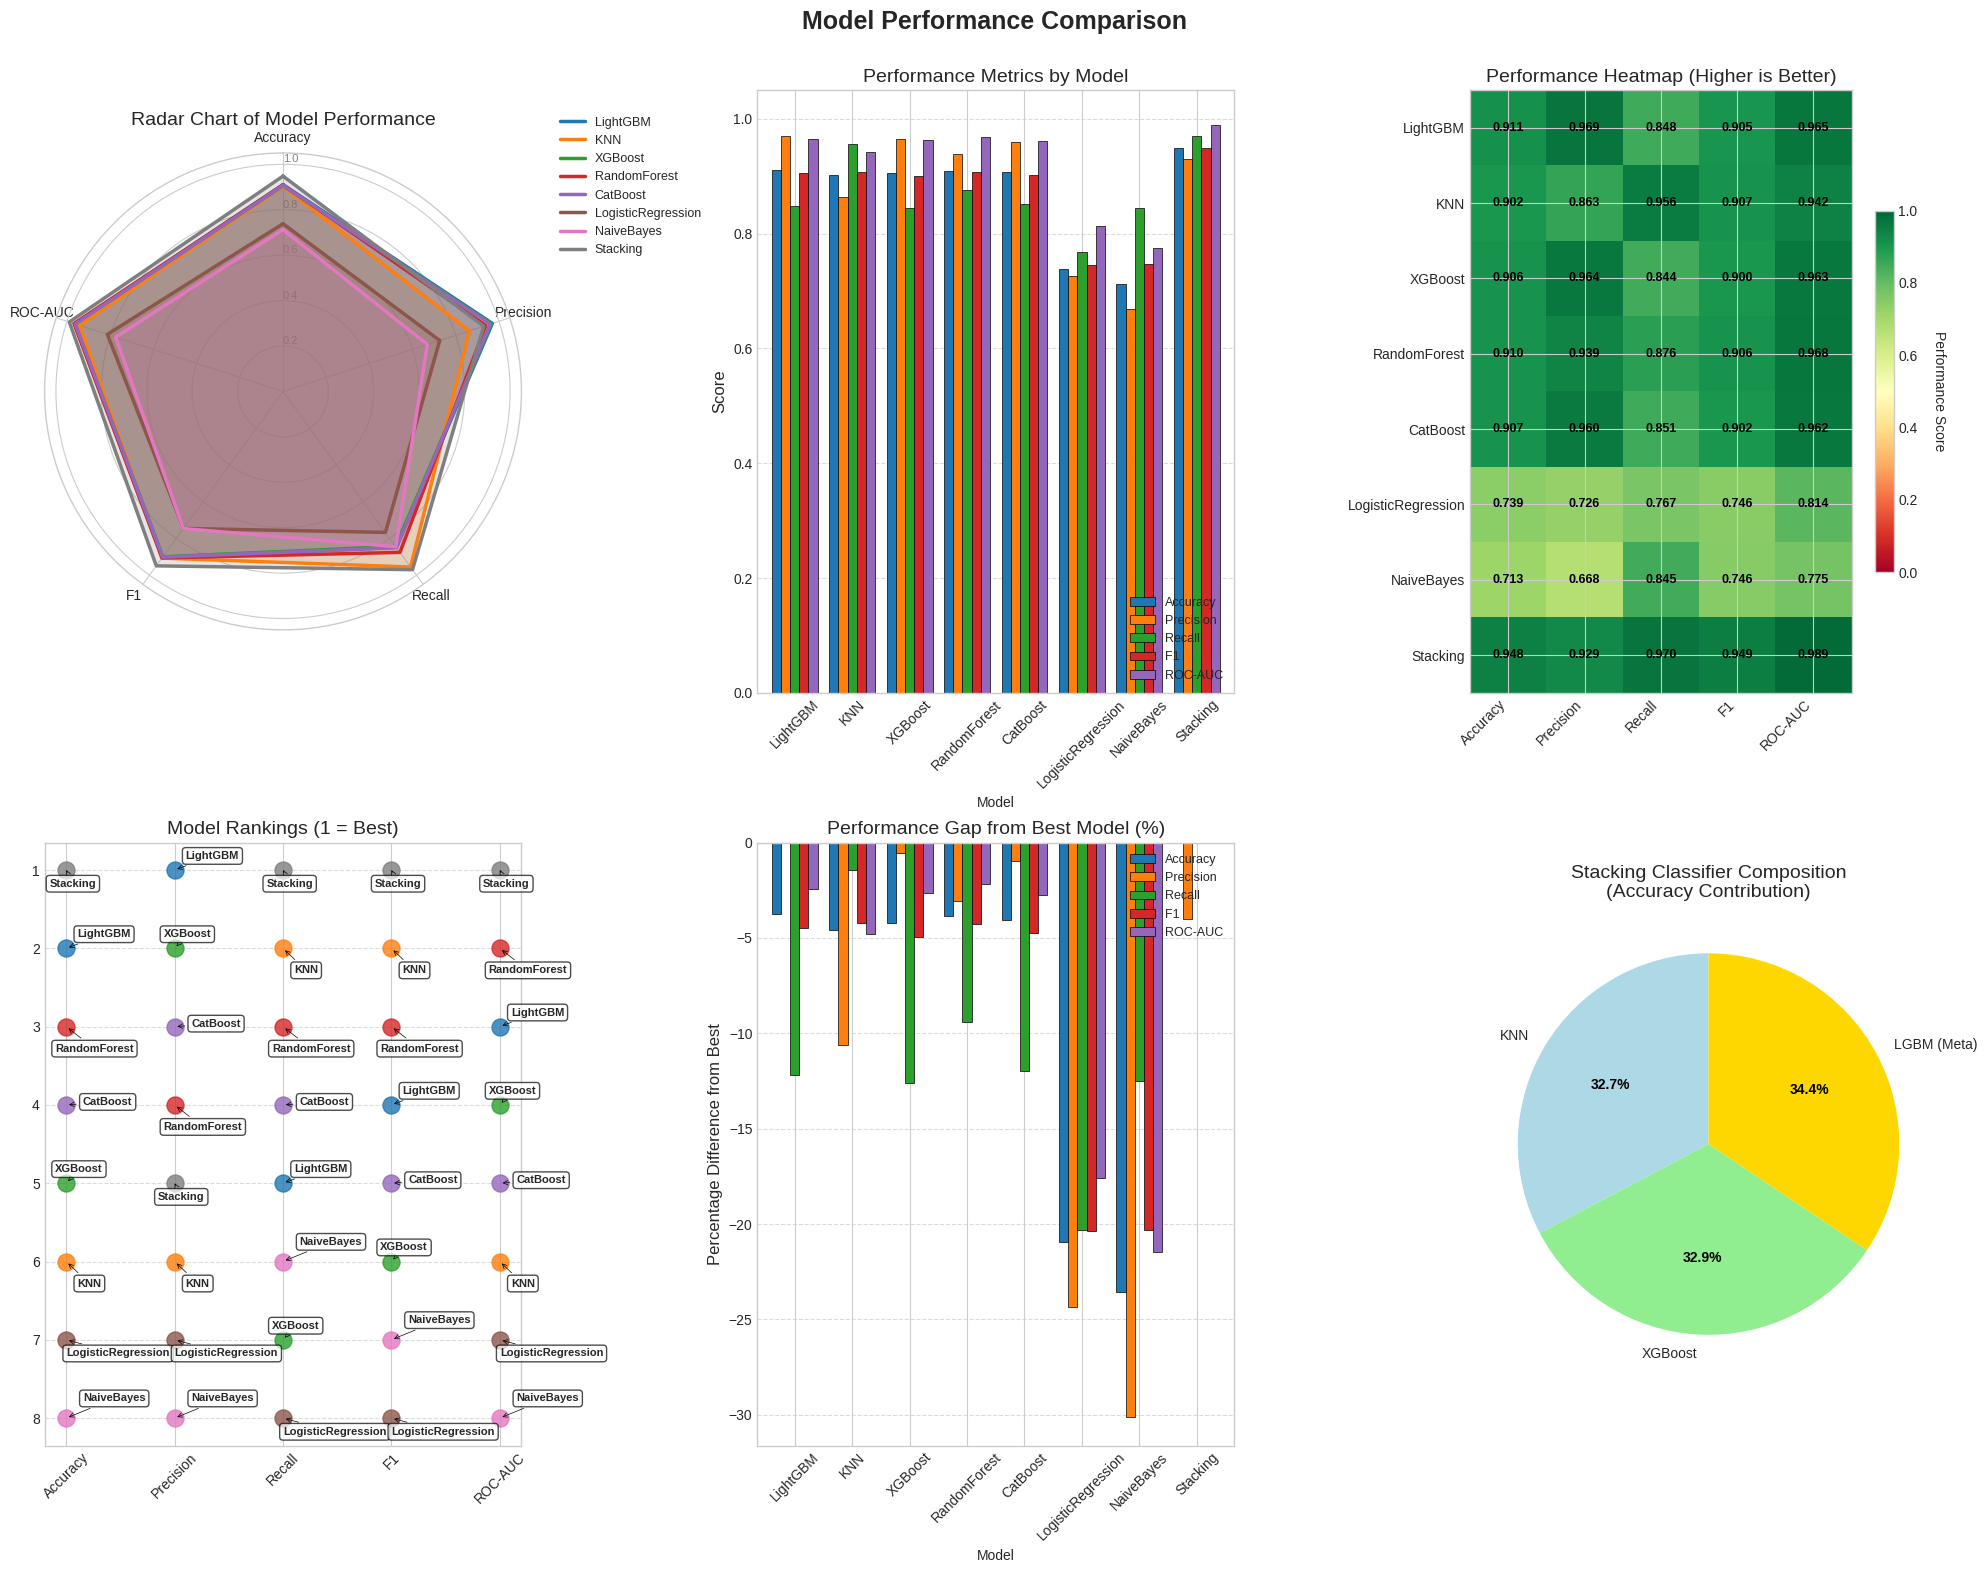

MODEL PERFORMANCE SUMMARY WITH RANKINGS
                    Accuracy  Precision  Recall      F1  ROC-AUC  \
Model                                                              
LightGBM              0.9108     0.9694  0.8483  0.9048   0.9651   
KNN                   0.9023     0.8635  0.9557  0.9072   0.9417   
XGBoost               0.9063     0.9642  0.8440  0.9001   0.9628   
RandomForest          0.9096     0.9389  0.8762  0.9064   0.9678   
CatBoost              0.9074     0.9596  0.8506  0.9018   0.9619   
LogisticRegression    0.7386     0.7257  0.7672  0.7459   0.8135   
NaiveBayes            0.7129     0.6683  0.8453  0.7464   0.7750   
Stacking              0.9482     0.9293  0.9702  0.9493   0.9895   

                    Accuracy_Rank  Precision_Rank  Recall_Rank  F1_Rank  \
Model                                                                     
LightGBM                      2.0             1.0          5.0      4.0   
KNN                           6.0             6.0     

In [ ]:
# Create a comprehensive visualization
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')

# 1. Radar chart for comprehensive comparison
ax1 = fig.add_subplot(2, 3, 1, polar=True)
categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontsize=10)

# Draw ylabels
ax1.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.05)

# Plot each model - using a color palette that works well with 8 models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
for i, (idx, row) in enumerate(results_df.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]  # Close the radar chart
    ax1.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=idx)
    ax1.fill(angles, values, color=colors[i], alpha=0.2)

ax1.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax1.set_title('Radar Chart of Model Performance', fontsize=14, pad=20)

# 2. Bar chart with performance metrics
ax2 = fig.add_subplot(2, 3, 2)
results_df.plot(kind='bar', ax=ax2, width=0.8, edgecolor='black', linewidth=0.5, color=colors)
ax2.set_title('Performance Metrics by Model', fontsize=14)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.legend(loc='lower right', fontsize=9)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# 3. Heatmap for easy comparison
ax3 = fig.add_subplot(2, 3, 3)
im = ax3.imshow(results_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax3.set_xticks(range(len(results_df.columns)))
ax3.set_yticks(range(len(results_df.index)))
ax3.set_xticklabels(results_df.columns, rotation=45, ha='right', fontsize=10)
ax3.set_yticklabels(results_df.index, fontsize=10)

# Add text annotations on heatmap
for i in range(len(results_df.index)):
    for j in range(len(results_df.columns)):
        text = ax3.text(j, i, f'{results_df.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=9, fontweight='bold')
ax3.set_title('Performance Heatmap (Higher is Better)', fontsize=14)

# Add colorbar for heatmap
cbar = plt.colorbar(im, ax=ax3, shrink=0.6)
cbar.set_label('Performance Score', rotation=270, labelpad=20)

# 4. Ranking visualization
ax4 = fig.add_subplot(2, 3, 4)
rank_df = results_df.rank(ascending=False)

# Create a scatter plot with consistent colors
for i, metric in enumerate(results_df.columns):
    for j, model in enumerate(rank_df.index):
        ax4.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])

        # Add model names with different offsets to avoid overlapping
        offsets = [(8, 8), (8, -18), (-8, 8), (-8, -18), (12, 0), (0, -12), (12, 12), (-12, -12)]
        ax4.annotate(model, (metric, rank_df[metric][j]),
                    xytext=offsets[j], textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0", lw=0.5))

ax4.set_yticks(range(1, len(rank_df)+1))
ax4.invert_yaxis()  # So rank 1 is at the top
ax4.set_title('Model Rankings (1 = Best)', fontsize=14)
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Performance difference from best model
ax5 = fig.add_subplot(2, 3, 5)
best_scores = results_df.max()
performance_diff = (results_df - best_scores) * 100  # Convert to percentage difference

# Create a diverging colormap
performance_diff.plot(kind='bar', ax=ax5, width=0.8, color=colors, edgecolor='black', linewidth=0.5)
ax5.set_title('Performance Gap from Best Model (%)', fontsize=14)
ax5.set_ylabel('Percentage Difference from Best', fontsize=12)
ax5.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax5.tick_params(axis='x', rotation=45)
ax5.legend(loc='upper right', fontsize=9)
ax5.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Stacking classifier components visualization
ax6 = fig.add_subplot(2, 3, 6)
stacking_models = ['KNN', 'XGBoost', 'LGBM (Meta)']
# Extract base model performances for the stacking components
stacking_component_performance = []
for model_name in ['KNN', 'XGBoost']:
    model_perf = results_df.loc[model_name, 'Accuracy']
    stacking_component_performance.append(model_perf)
stacking_component_performance.append(results_df.loc['Stacking', 'Accuracy'])

colors = ['lightblue', 'lightgreen', 'gold']
wedges, texts, autotexts = ax6.pie(stacking_component_performance,
                                   labels=stacking_models,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
ax6.set_title('Stacking Classifier Composition\n(Accuracy Contribution)', fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("comprehensive_model_comparison_with_stacking.png", dpi=300, bbox_inches="tight")
plt.show()

# Create a summary table with rankings
summary_df = results_df.copy()
for col in results_df.columns:
    summary_df[f'{col}_Rank'] = results_df[col].rank(ascending=False)

print("MODEL PERFORMANCE SUMMARY WITH RANKINGS")
print("="*80)
print(summary_df.round(4))

# Find best model for each metric
best_models = {}
for metric in results_df.columns:
    best_idx = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    best_models[metric] = (best_idx, best_value)

print("\nBEST PERFORMING MODELS BY METRIC")
print("="*50)
for metric, (model, value) in best_models.items():
    print(f"{metric:15}: {model:20} ({value:.4f})")

# Calculate overall ranking (average rank across all metrics)
overall_rank = summary_df[[col for col in summary_df.columns if 'Rank' in col]].mean(axis=1)
overall_rank.name = 'Overall_Rank'
best_overall = overall_rank.idxmin()

print(f"\nBEST OVERALL MODEL: {best_overall} (Average Rank: {overall_rank.min():.2f})")

# Compare stacking vs best base model (excluding Stacking itself)
base_models_df = results_df.drop('Stacking')
best_base_model = base_models_df.mean(axis=1).idxmax()
improvement = (results_df.loc['Stacking'] - results_df.loc[best_base_model]) / results_df.loc[best_base_model] * 100

print(f"\nSTACKING IMPROVEMENT OVER BEST BASE MODEL ({best_base_model})")
print("="*60)
for metric in results_df.columns:
    print(f"{metric:15}: {improvement[metric]:+7.2f}%")

# Additional analysis - show where Stacking excels the most
print(f"\nSTACKING EXCELS MOST IN: {improvement.idxmax()} ({improvement.max():.2f}% improvement)")

In [ ]:
# Create a styled performance summary table
print("=" * 90)
print("MODEL PERFORMANCE SUMMARY".center(90))
print("=" * 90)

# Create a styled DataFrame
styled_df = results_df.copy()

# Format with colors and highlighting
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: #90EE90; font-weight: bold' if v else '' for v in is_max]

def highlight_stacking(s):
    is_stacking = s.name == 'Stacking'
    return ['background-color: #FFCCCB; font-weight: bold' if is_stacking else '' for _ in s]

# Apply styling
styled_output = styled_df.style\
    .apply(highlight_max)\
    .apply(highlight_stacking, axis=1)\
    .format("{:.4f}")\
    .set_caption("Performance Metrics (Green = Best, Pink = Stacking Model)")

# Display the styled DataFrame
try:
    from IPython.display import display
    display(styled_output)
except:
    print(styled_df.round(4))
    print("\n*Green = Best performance, Pink = Stacking model")

print("=" * 90)

                                MODEL PERFORMANCE SUMMARY                                 


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
LightGBM,0.9108,0.9694,0.8483,0.9048,0.9651
KNN,0.9023,0.8635,0.9557,0.9072,0.9417
XGBoost,0.9063,0.9642,0.8440,0.9001,0.9628
RandomForest,0.9096,0.9389,0.8762,0.9064,0.9678
CatBoost,0.9074,0.9596,0.8506,0.9018,0.9619
LogisticRegression,0.7386,0.7257,0.7672,0.7459,0.8135
NaiveBayes,0.7129,0.6683,0.8453,0.7464,0.7750
Stacking,0.9482,0.9293,0.9702,0.9493,0.9895


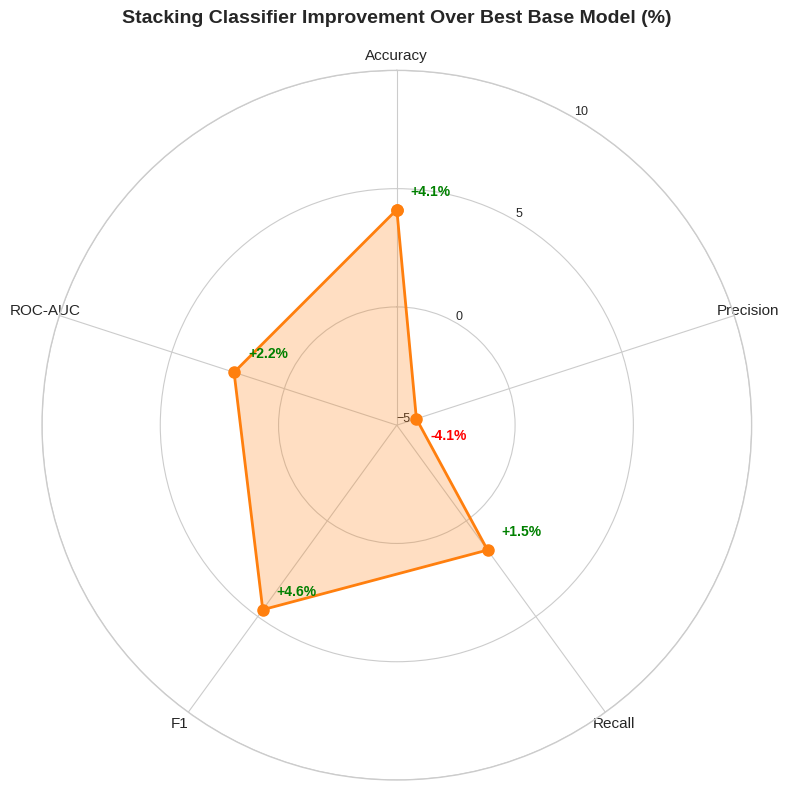

In [ ]:
# Create a radar chart focusing on improvement over best base model
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

# Calculate improvement percentages
base_models = results_df.drop('Stacking')
best_base_scores = base_models.max()
improvement_pct = (results_df.loc['Stacking'] - best_base_scores) / best_base_scores * 100

categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

values = improvement_pct.values.tolist()
values += values[:1]  # Close the radar chart

ax.plot(angles, values, 'o-', linewidth=2, color='#ff7f0e', markersize=8)
ax.fill(angles, values, alpha=0.25, color='#ff7f0e')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontsize=11)

# Set ylabels
max_improvement = max(max(improvement_pct), 10)
plt.ylim(min(min(improvement_pct), -5), max_improvement)
plt.yticks(np.arange(-5 if min(improvement_pct) < 0 else 0, max_improvement + 5, 5),
           fontsize=9)
ax.set_rlabel_position(30)

plt.title('Stacking Classifier Improvement Over Best Base Model (%)\n',
          fontsize=14, fontweight='bold', pad=20)

# Add value annotations
for angle, value, category in zip(angles[:-1], improvement_pct.values, categories):
    if value >= 0:
        ax.annotate(f'+{value:.1f}%',
                   xy=(angle, value),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=10, fontweight='bold', color='green')
    else:
        ax.annotate(f'{value:.1f}%',
                   xy=(angle, value),
                   xytext=(10, -15), textcoords='offset points',
                   fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig("stacking_improvement_radar.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Create a formatted performance summary table
print("="*80)
print("MODEL PERFORMANCE SUMMARY".center(80))
print("="*80)

# Format the table with highlighting
formatted_df = results_df.copy()
for col in formatted_df.columns:
    best_val = formatted_df[col].max()
    formatted_df[col] = formatted_df[col].apply(
        lambda x: f"\033[1;32m{x:.4f}*\033[0m" if x == best_val else f"{x:.4f}")

print(formatted_df.to_string())
print("\n* indicates best performance in metric")
print("="*80)

# Print key findings
print("\nKEY FINDINGS:")
print(f"1. Best Overall Model: {best_overall} (Avg Rank: {overall_rank.min():.2f})")
print(f"2. Stacking shows improvement in {sum(improvement_pct > 0)}/{len(improvement_pct)} metrics")
print(f"3. Average improvement: {improvement_pct.mean():.2f}%")

                           MODEL PERFORMANCE SUMMARY                            
                              Accuracy           Precision              Recall                  F1             ROC-AUC
Model                                                                                                                 
LightGBM                        0.9108  0.9694*              0.8483              0.9048              0.9651
KNN                             0.9023              0.8635              0.9557              0.9072              0.9417
XGBoost                         0.9063              0.9642              0.8440              0.9001              0.9628
RandomForest                    0.9096              0.9389              0.8762              0.9064              0.9678
CatBoost                        0.9074              0.9596              0.8506              0.9018              0.9619
LogisticRegression              0.7386              0.7257              0.7672              0.745

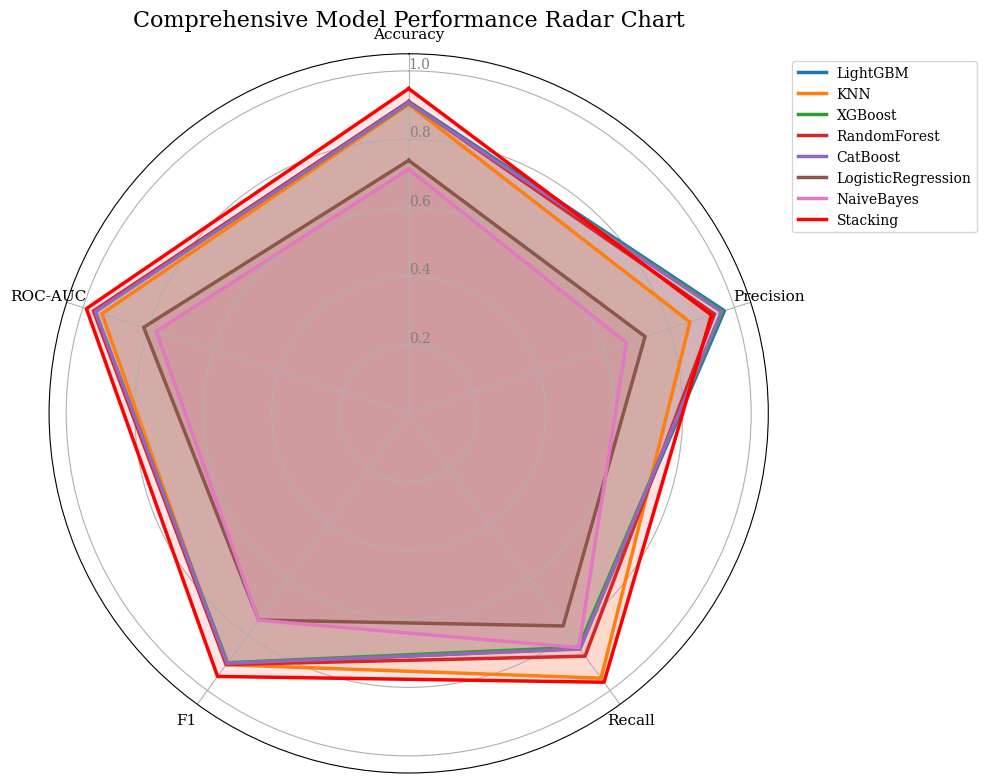

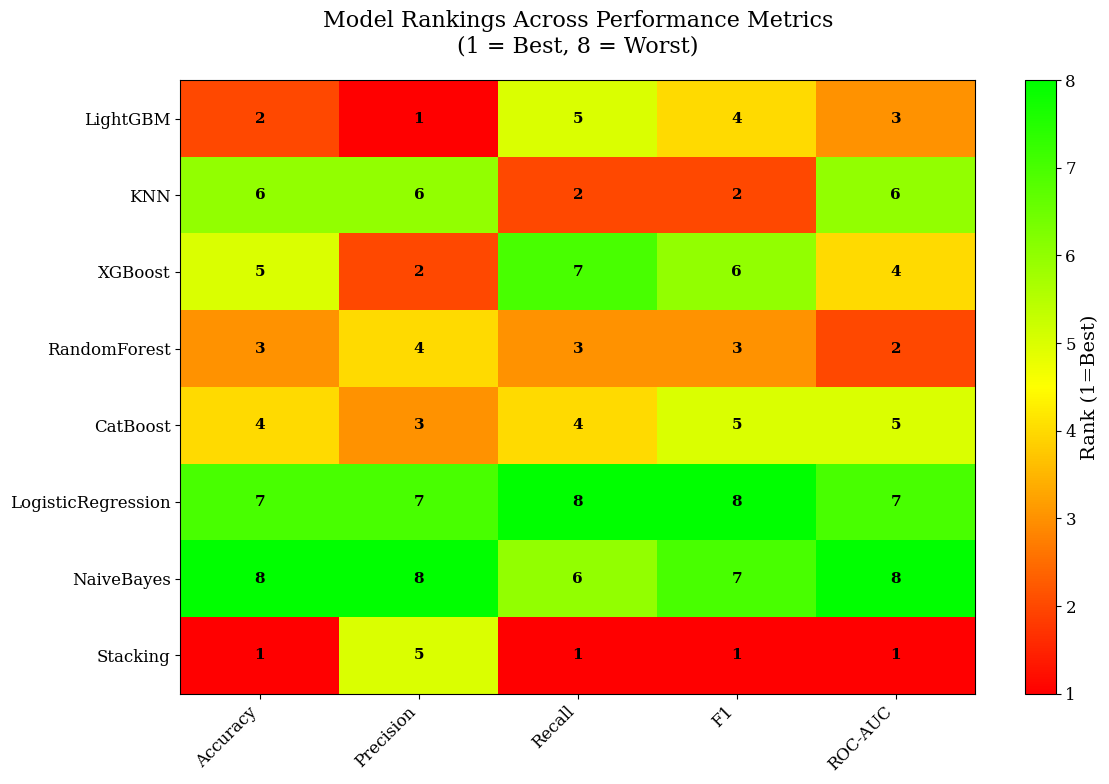

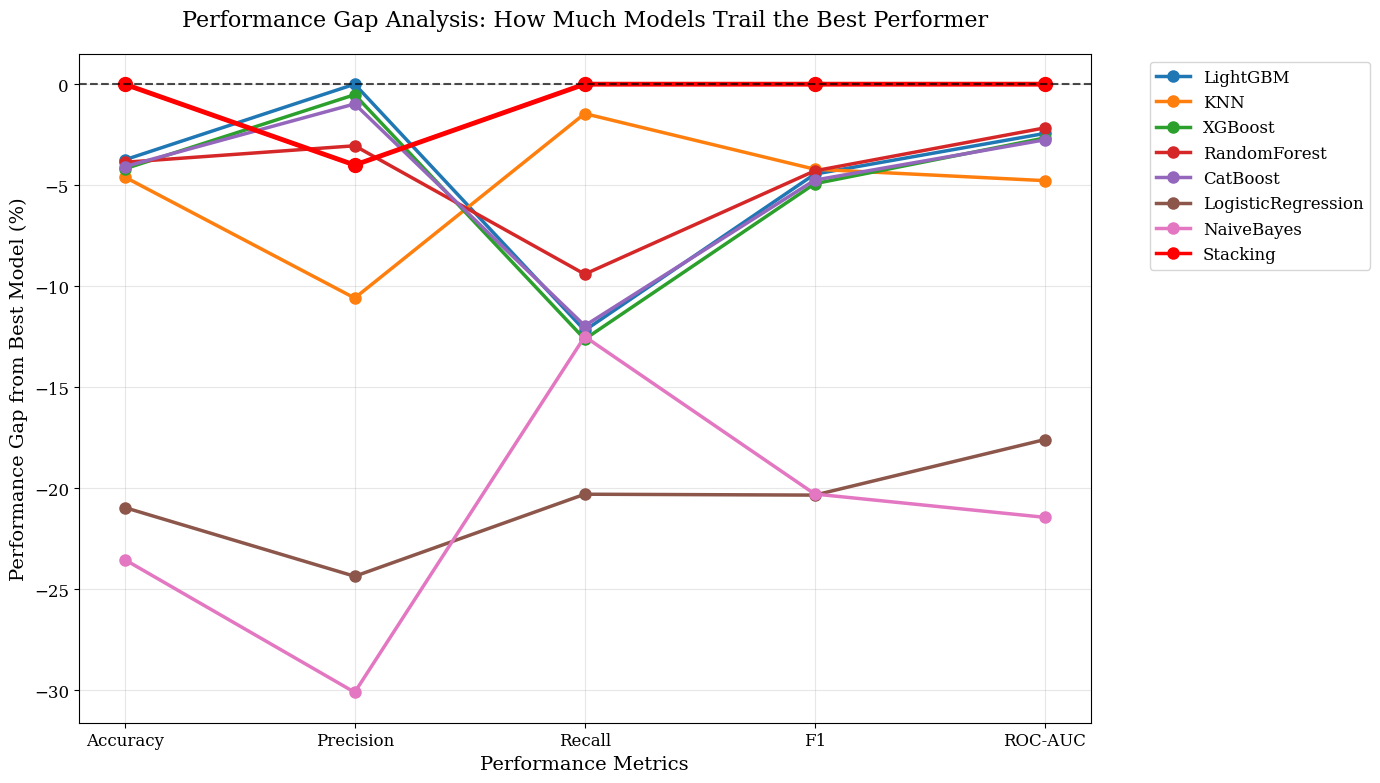

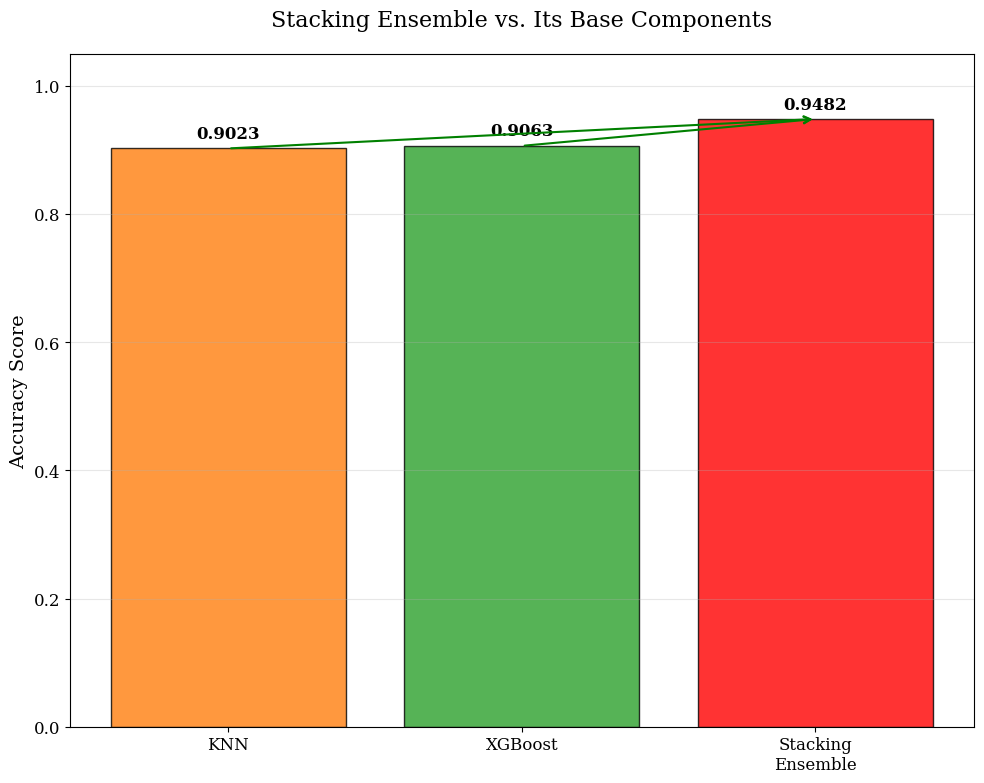

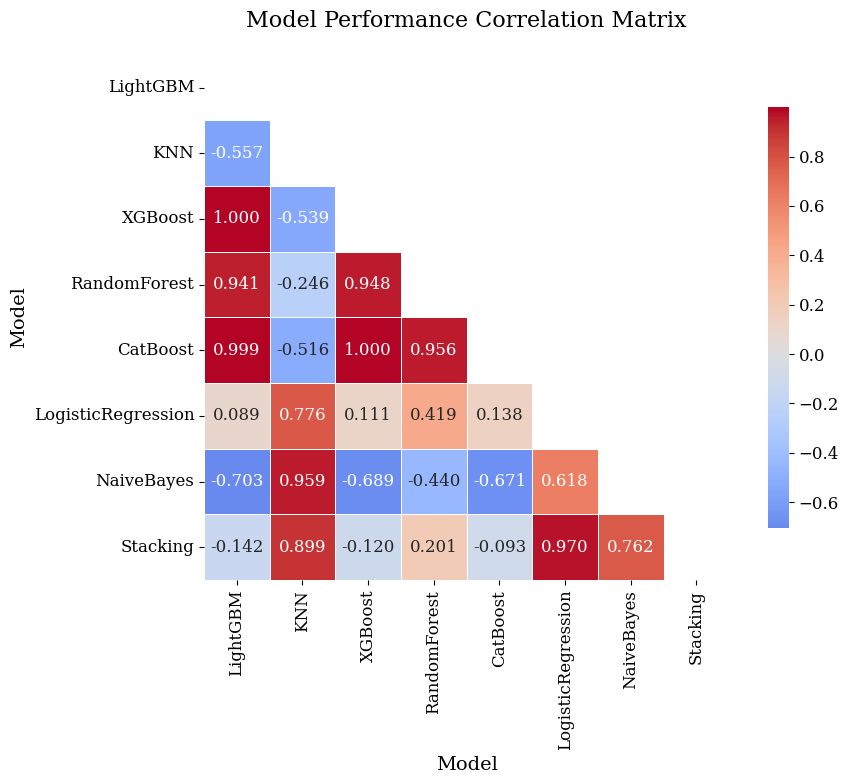

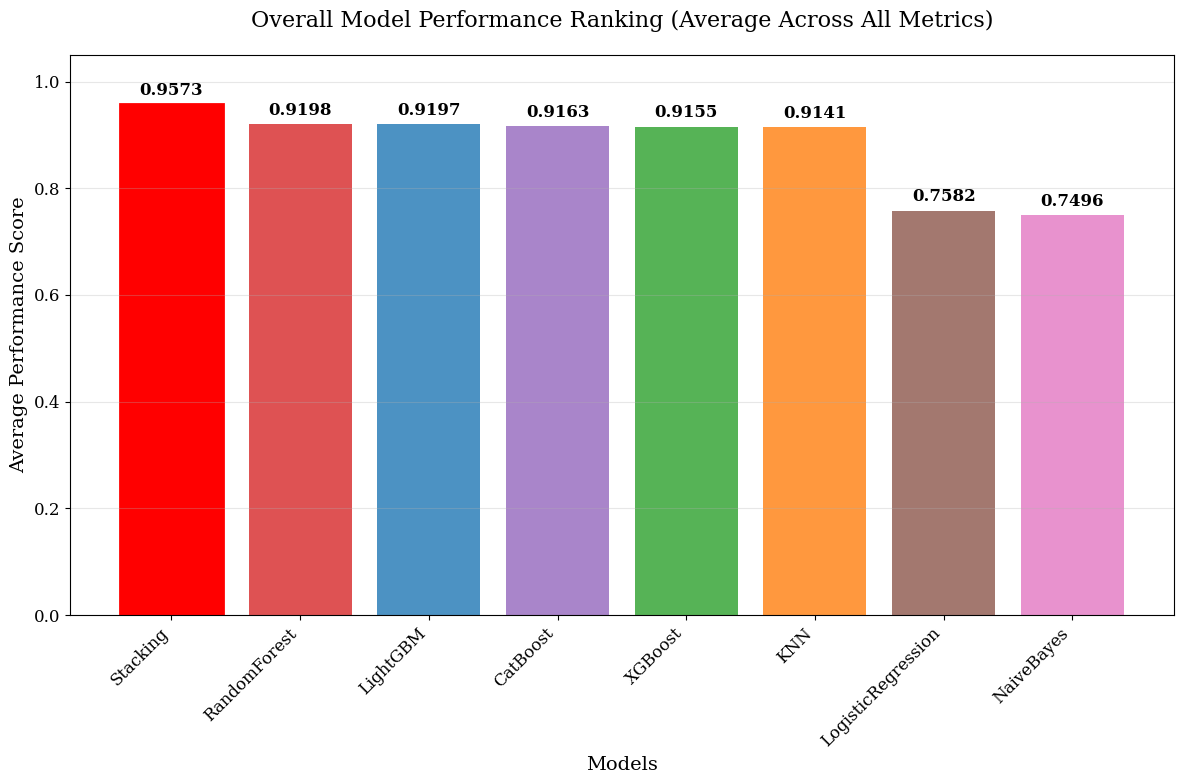

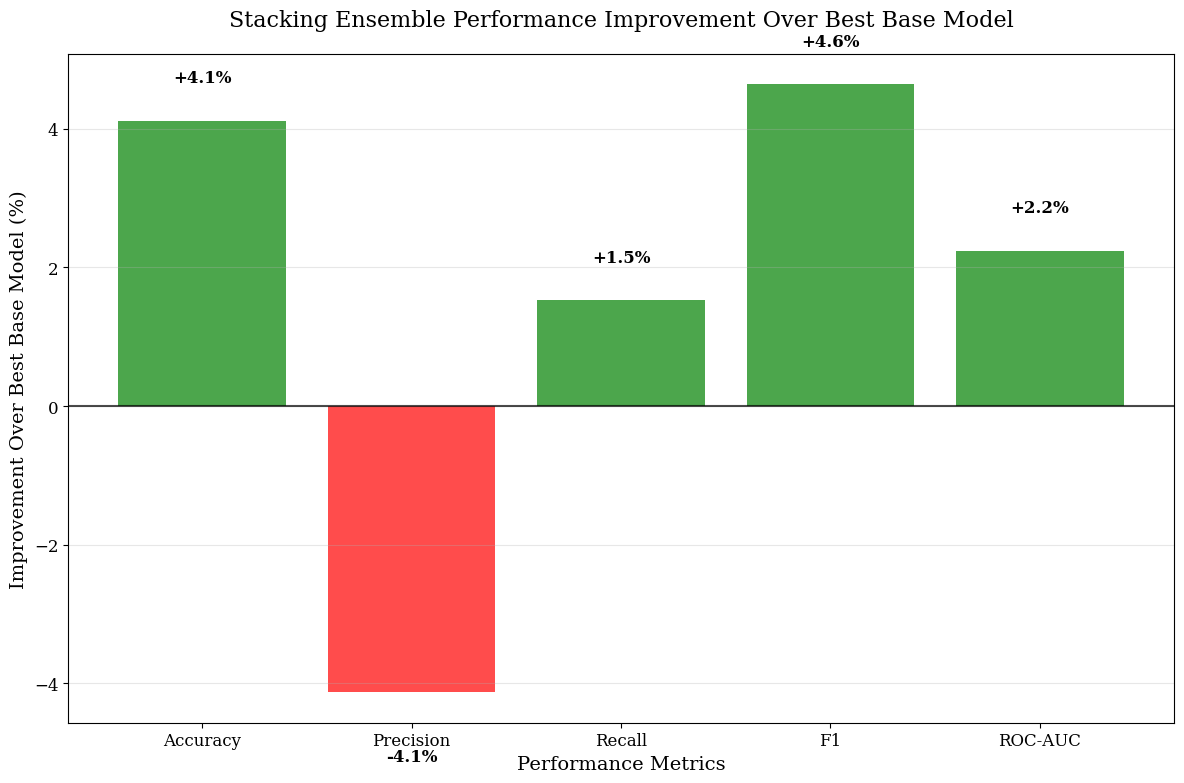

All visualizations have been created and saved as high-resolution PNG files.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Set professional style for research paper
plt.style.use('default')
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Define a consistent color palette for all models
model_colors = {
    'LightGBM': '#1f77b4',          # Blue
    'KNN': '#ff7f0e',               # Orange
    'XGBoost': '#2ca02c',           # Green
    'RandomForest': '#d62728',      # Red
    'CatBoost': '#9467bd',          # Purple
    'LogisticRegression': '#8c564b', # Brown
    'NaiveBayes': '#e377c2',        # Pink
    'Stacking': '#ff0000'           # Bright Red (highlighted)
}

# 1. PERFORMANCE COMPARISON RADAR CHART
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontsize=11)

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.05)

# Plot each model
for i, (idx, row) in enumerate(results_df.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]  # Close the radar chart
    ax.plot(angles, values, color=model_colors[idx], linewidth=2.5, linestyle='solid', label=idx)
    ax.fill(angles, values, color=model_colors[idx], alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
plt.title('Comprehensive Model Performance Radar Chart', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("radar_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. RANKING HEATMAP ACROSS METRICS
rank_df = results_df.rank(ascending=False)

plt.figure(figsize=(12, 8))
cmap = LinearSegmentedColormap.from_list('rank_cmap', ['#ff0000', '#ffff00', '#00ff00'])
im = plt.imshow(rank_df.values, cmap=cmap, aspect='auto')

plt.xticks(range(len(rank_df.columns)), rank_df.columns, rotation=45, ha='right')
plt.yticks(range(len(rank_df.index)), rank_df.index)
plt.title('Model Rankings Across Performance Metrics\n(1 = Best, 8 = Worst)', fontsize=16, pad=20)

# Add text annotations
for i in range(len(rank_df.index)):
    for j in range(len(rank_df.columns)):
        text = plt.text(j, i, f'{int(rank_df.iloc[i, j])}',
                       ha="center", va="center", color="black", fontsize=11, fontweight='bold')

plt.colorbar(im, label='Rank (1=Best)')
plt.tight_layout()
plt.savefig("ranking_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. PERFORMANCE GAP ANALYSIS
plt.figure(figsize=(14, 8))
best_scores = results_df.max()
performance_gap = (results_df - best_scores) * 100

# Plot performance gap
for model in results_df.index:
    plt.plot(performance_gap.columns, performance_gap.loc[model],
             marker='o', linewidth=2.5, markersize=8,
             label=model, color=model_colors[model])
    if model == 'Stacking':
        plt.plot(performance_gap.columns, performance_gap.loc[model],
                 marker='o', linewidth=3.5, markersize=10,
                 color=model_colors[model])

plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Performance Metrics', fontsize=14)
plt.ylabel('Performance Gap from Best Model (%)', fontsize=14)
plt.title('Performance Gap Analysis: How Much Models Trail the Best Performer', fontsize=16, pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("performance_gap_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. STACKING CLASSIFIER COMPONENT ANALYSIS
plt.figure(figsize=(10, 8))

# Get base model performances
base_models = ['KNN', 'XGBoost']
base_performance = [results_df.loc[model, 'Accuracy'] for model in base_models]
stacking_performance = results_df.loc['Stacking', 'Accuracy']

# Create bar chart
x_pos = np.arange(len(base_models) + 1)
performance_values = base_performance + [stacking_performance]
colors = [model_colors[model] for model in base_models] + [model_colors['Stacking']]
labels = base_models + ['Stacking\nEnsemble']

bars = plt.bar(x_pos, performance_values, color=colors, alpha=0.8, edgecolor='black')

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, performance_values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Accuracy Score', fontsize=14)
plt.title('Stacking Ensemble vs. Its Base Components', fontsize=16, pad=20)
plt.xticks(x_pos, labels)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

# Add improvement arrows
for i, base_model in enumerate(base_models):
    plt.annotate('', xy=(2, stacking_performance),
                xytext=(i, results_df.loc[base_model, 'Accuracy']),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='green'))

plt.tight_layout()
plt.savefig("stacking_component_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. MODEL PERFORMANCE CORRELATION HEATMAP
plt.figure(figsize=(10, 8))
correlation_matrix = results_df.T.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": .8}, fmt='.3f')

plt.title('Model Performance Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("model_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. OVERALL PERFORMANCE SUMMARY CHART
plt.figure(figsize=(12, 8))

# Calculate average performance across all metrics
avg_performance = results_df.mean(axis=1).sort_values(ascending=False)
colors = [model_colors[model] for model in avg_performance.index]

bars = plt.bar(range(len(avg_performance)), avg_performance.values, color=colors, alpha=0.8)

# Highlight stacking model
stacking_idx = list(avg_performance.index).index('Stacking')
bars[stacking_idx].set_alpha(1.0)
bars[stacking_idx].set_edgecolor('red')
bars[stacking_idx].set_linewidth(2)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, avg_performance.values)):
    plt.text(bar.get_x() + bar.get_width()/2., value + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Models', fontsize=14)
plt.ylabel('Average Performance Score', fontsize=14)
plt.title('Overall Model Performance Ranking (Average Across All Metrics)', fontsize=16, pad=20)
plt.xticks(range(len(avg_performance)), avg_performance.index, rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("overall_performance_ranking.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. PERFORMANCE IMPROVEMENT WITH STACKING
plt.figure(figsize=(12, 8))

# Calculate improvement over best base model
base_models_df = results_df.drop('Stacking')
best_base_performance = base_models_df.max()
improvement_pct = ((results_df.loc['Stacking'] - best_base_performance) / best_base_performance) * 100

colors = ['green' if x >= 0 else 'red' for x in improvement_pct]
bars = plt.bar(improvement_pct.index, improvement_pct.values, color=colors, alpha=0.7)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, improvement_pct.values)):
    va = 'bottom' if value >= 0 else 'top'
    offset = 0.5 if value >= 0 else -0.8
    plt.text(bar.get_x() + bar.get_width()/2., value + offset,
             f'{value:+.1f}%', ha='center', va=va, fontweight='bold')

plt.axhline(y=0, color='black', linestyle='-', alpha=0.7)
plt.xlabel('Performance Metrics', fontsize=14)
plt.ylabel('Improvement Over Best Base Model (%)', fontsize=14)
plt.title('Stacking Ensemble Performance Improvement Over Best Base Model', fontsize=16, pad=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("stacking_improvement.png", dpi=300, bbox_inches="tight")
plt.show()

print("All visualizations have been created and saved as high-resolution PNG files.")

/tmp/ipython-input-397035529.py:58: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax3.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])
/tmp/ipython-input-397035529.py:62: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax3.annotate(model, (metric, rank_df[metric][j]),
/tmp/ipython-input-397035529.py:95: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


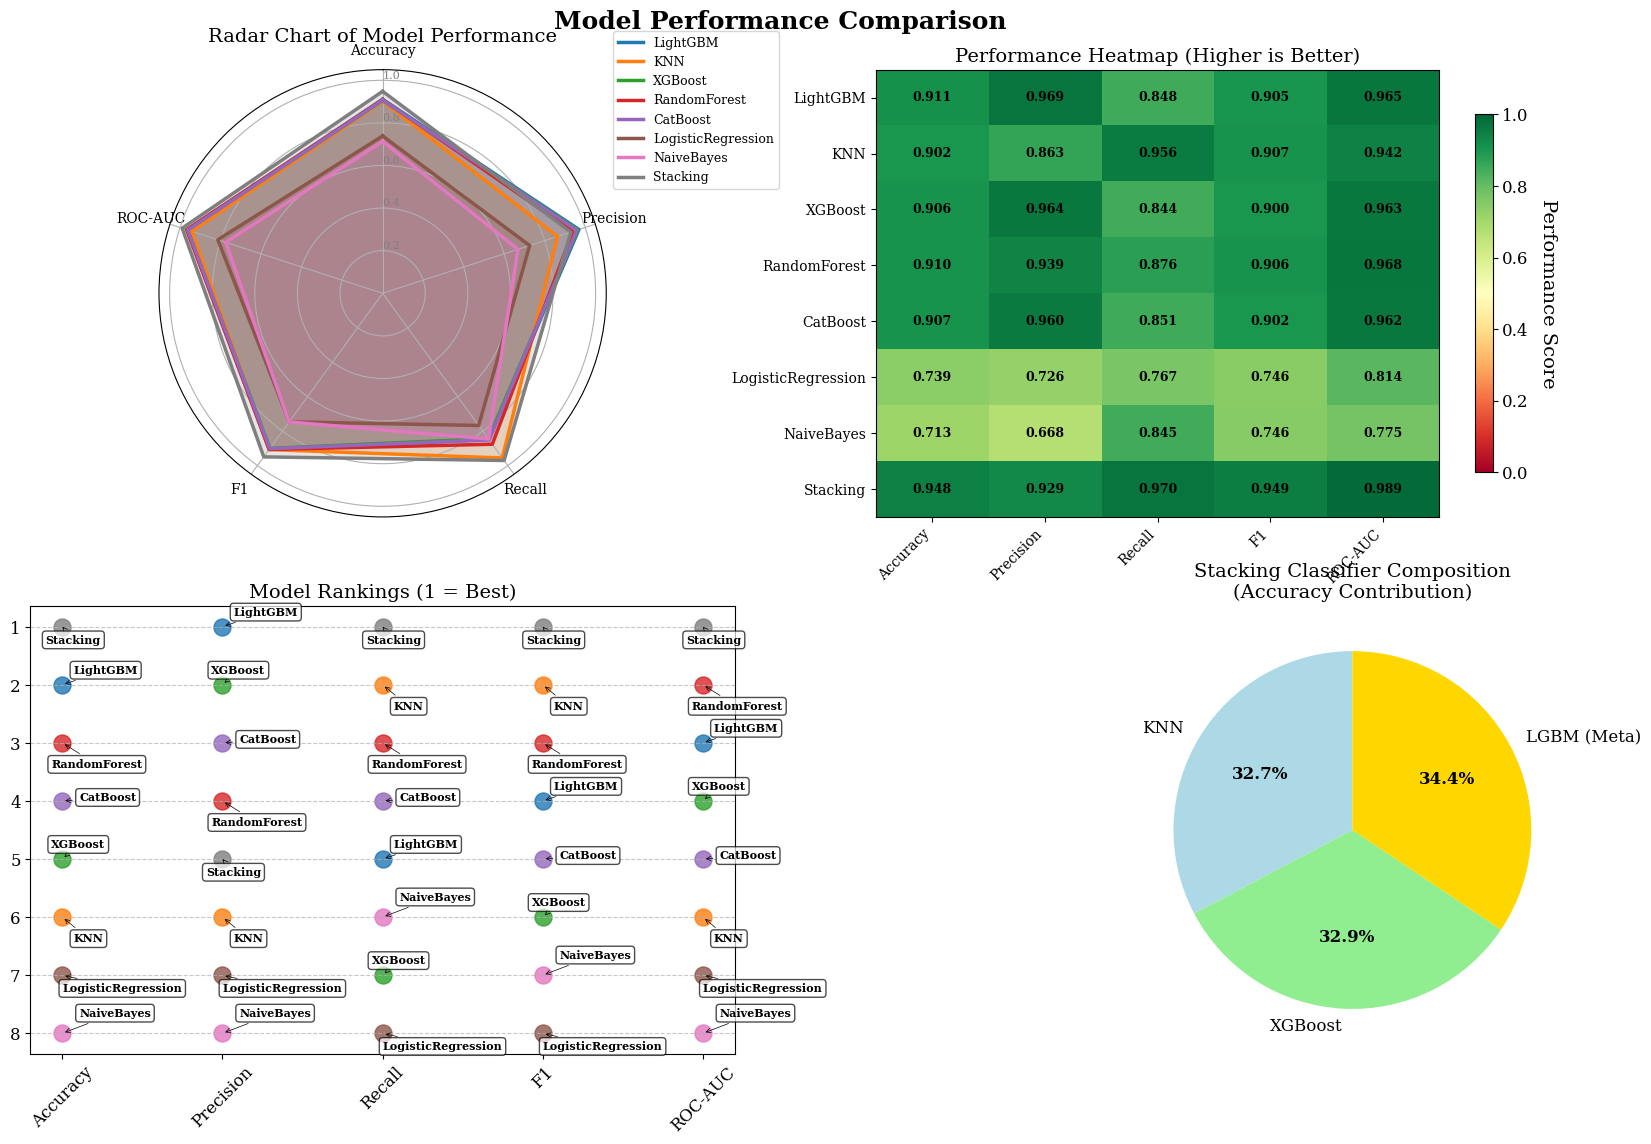

MODEL PERFORMANCE SUMMARY WITH RANKINGS
                    Accuracy  Precision  Recall      F1  ROC-AUC  \
Model                                                              
LightGBM              0.9108     0.9694  0.8483  0.9048   0.9651   
KNN                   0.9023     0.8635  0.9557  0.9072   0.9417   
XGBoost               0.9063     0.9642  0.8440  0.9001   0.9628   
RandomForest          0.9096     0.9389  0.8762  0.9064   0.9678   
CatBoost              0.9074     0.9596  0.8506  0.9018   0.9619   
LogisticRegression    0.7386     0.7257  0.7672  0.7459   0.8135   
NaiveBayes            0.7129     0.6683  0.8453  0.7464   0.7750   
Stacking              0.9482     0.9293  0.9702  0.9493   0.9895   

                    Accuracy_Rank  Precision_Rank  Recall_Rank  F1_Rank  \
Model                                                                     
LightGBM                      2.0             1.0          5.0      4.0   
KNN                           6.0             6.0     

In [ ]:
# Create a comprehensive visualization
fig = plt.figure(figsize=(20, 12))  # Reduced height since we're removing 2 plots
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')

# 1. Radar chart for comprehensive comparison
ax1 = fig.add_subplot(2, 2, 1, polar=True)  # Changed to 2x2 grid, position 1
categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontsize=10)

# Draw ylabels
ax1.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.05)

# Plot each model - using a color palette that works well with 8 models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
for i, (idx, row) in enumerate(results_df.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]  # Close the radar chart
    ax1.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=idx)
    ax1.fill(angles, values, color=colors[i], alpha=0.2)

ax1.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax1.set_title('Radar Chart of Model Performance', fontsize=14, pad=20)

# 2. Heatmap for easy comparison (moved to position 2)
ax2 = fig.add_subplot(2, 2, 2)  # Changed to position 2
im = ax2.imshow(results_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(results_df.columns)))
ax2.set_yticks(range(len(results_df.index)))
ax2.set_xticklabels(results_df.columns, rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(results_df.index, fontsize=10)

# Add text annotations on heatmap
for i in range(len(results_df.index)):
    for j in range(len(results_df.columns)):
        text = ax2.text(j, i, f'{results_df.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=9, fontweight='bold')
ax2.set_title('Performance Heatmap (Higher is Better)', fontsize=14)

# Add colorbar for heatmap
cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('Performance Score', rotation=270, labelpad=20)

# 3. Ranking visualization (moved to position 3)
ax3 = fig.add_subplot(2, 2, 3)  # Changed to position 3
rank_df = results_df.rank(ascending=False)

# Create a scatter plot with consistent colors
for i, metric in enumerate(results_df.columns):
    for j, model in enumerate(rank_df.index):
        ax3.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])

        # Add model names with different offsets to avoid overlapping
        offsets = [(8, 8), (8, -18), (-8, 8), (-8, -18), (12, 0), (0, -12), (12, 12), (-12, -12)]
        ax3.annotate(model, (metric, rank_df[metric][j]),
                    xytext=offsets[j], textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0", lw=0.5))

ax3.set_yticks(range(1, len(rank_df)+1))
ax3.invert_yaxis()  # So rank 1 is at the top
ax3.set_title('Model Rankings (1 = Best)', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Stacking classifier components visualization
ax6 = fig.add_subplot(2, 3, 6)
stacking_models = ['KNN', 'XGBoost', 'LGBM (Meta)']
# Extract base model performances for the stacking components
stacking_component_performance = []
for model_name in ['KNN', 'XGBoost']:
    model_perf = results_df.loc[model_name, 'Accuracy']
    stacking_component_performance.append(model_perf)
stacking_component_performance.append(results_df.loc['Stacking', 'Accuracy'])

colors = ['lightblue', 'lightgreen', 'gold']
wedges, texts, autotexts = ax6.pie(stacking_component_performance,
                                   labels=stacking_models,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
ax6.set_title('Stacking Classifier Composition\n(Accuracy Contribution)', fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("comprehensive_model_comparison_with_stacking.png", dpi=300, bbox_inches="tight")
plt.show()
# Create a summary table with rankings
summary_df = results_df.copy()
for col in results_df.columns:
    summary_df[f'{col}_Rank'] = results_df[col].rank(ascending=False)

print("MODEL PERFORMANCE SUMMARY WITH RANKINGS")
print("="*80)
print(summary_df.round(4))

# Find best model for each metric
best_models = {}
for metric in results_df.columns:
    best_idx = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    best_models[metric] = (best_idx, best_value)

print("\nBEST PERFORMING MODELS BY METRIC")
print("="*50)
for metric, (model, value) in best_models.items():
    print(f"{metric:15}: {model:20} ({value:.4f})")

# Calculate overall ranking (average rank across all metrics)
overall_rank = summary_df[[col for col in summary_df.columns if 'Rank' in col]].mean(axis=1)
overall_rank.name = 'Overall_Rank'
best_overall = overall_rank.idxmin()

print(f"\nBEST OVERALL MODEL: {best_overall} (Average Rank: {overall_rank.min():.2f})")

# Compare stacking vs best base model (excluding Stacking itself)
base_models_df = results_df.drop('Stacking')
best_base_model = base_models_df.mean(axis=1).idxmax()
improvement = (results_df.loc['Stacking'] - results_df.loc[best_base_model]) / results_df.loc[best_base_model] * 100

print(f"\nSTACKING IMPROVEMENT OVER BEST BASE MODEL ({best_base_model})")
print("="*60)
for metric in results_df.columns:
    print(f"{metric:15}: {improvement[metric]:+7.2f}%")

# Additional analysis - show where Stacking excels the most
print(f"\nSTACKING EXCELS MOST IN: {improvement.idxmax()} ({improvement.max():.2f}% improvement)")

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


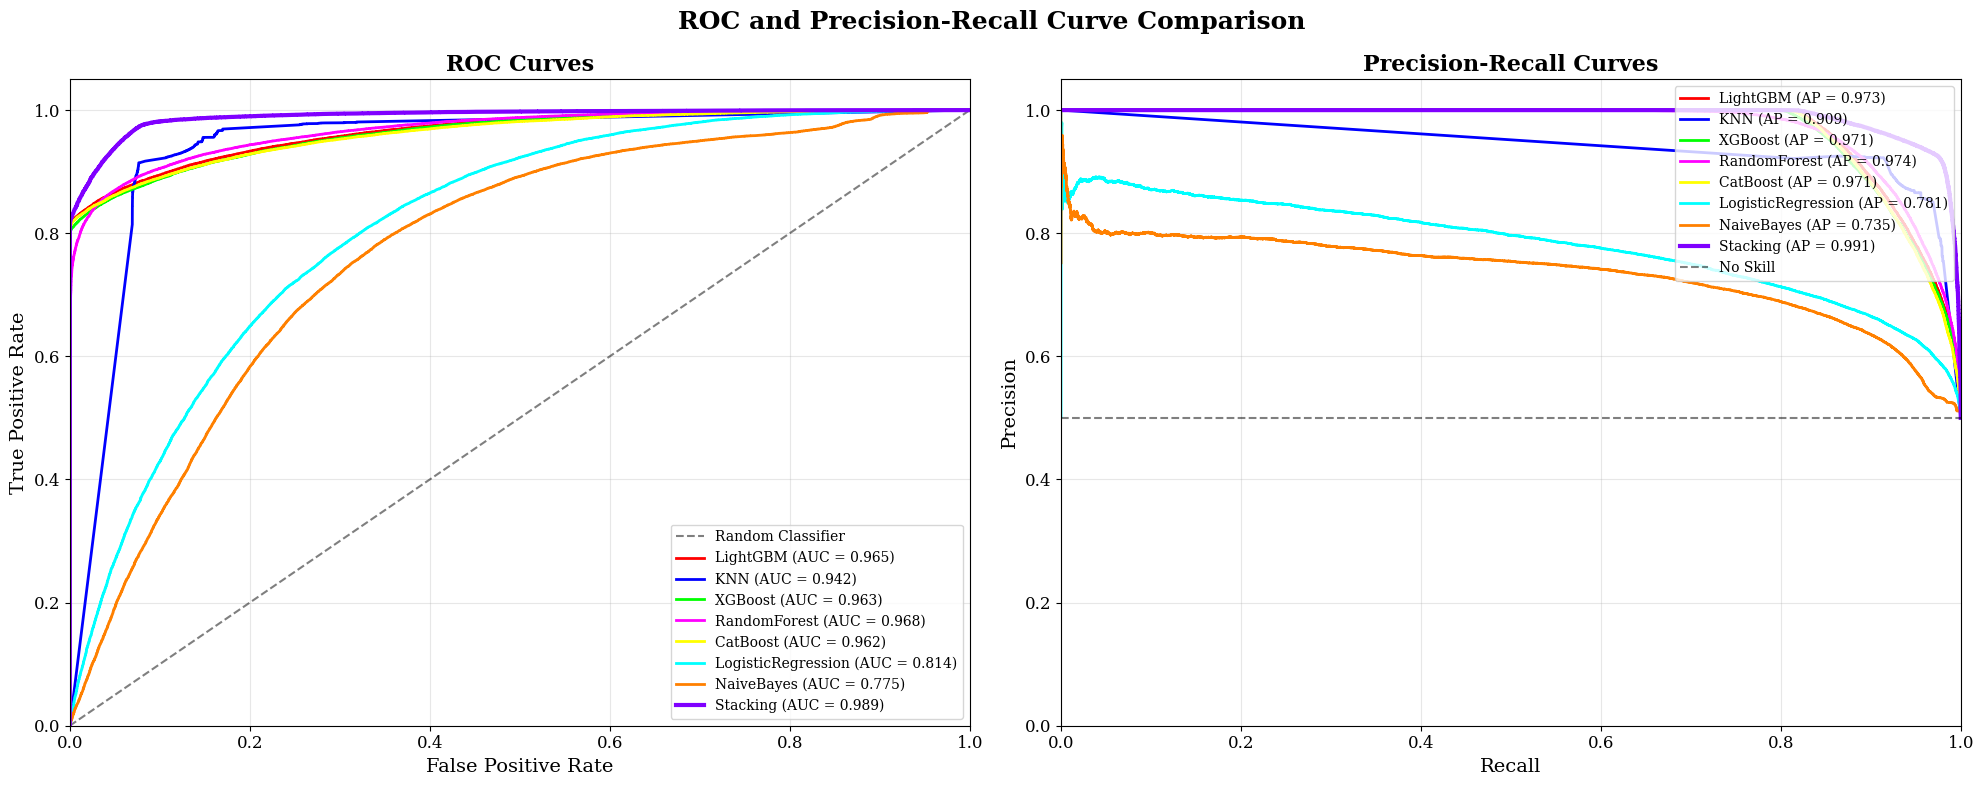

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


AUC PERFORMANCE COMPARISON
                    ROC-AUC  PR-AUC
Model                              
Stacking             0.9895  0.9907
RandomForest         0.9678  0.9740
LightGBM             0.9651  0.9727
XGBoost              0.9628  0.9709
CatBoost             0.9619  0.9708
KNN                  0.9417  0.9094
LogisticRegression   0.8135  0.7814
NaiveBayes           0.7750  0.7354

Best ROC-AUC: Stacking (0.9895)
Best PR-AUC: Stacking (0.9907)


In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Create highly distinct color palette for all models
high_contrast_colors = [
    '#FF0000',  # Bright Red (Stacking)
    '#0000FF',  # Bright Blue
    '#00FF00',  # Bright Green
    '#FF00FF',  # Magenta
    '#FFFF00',  # Yellow
    '#00FFFF',  # Cyan
    '#FF8000',  # Orange
    '#8000FF'   # Purple
]

# Create figure for ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('ROC and Precision-Recall Curve Comparison', fontsize=18, fontweight='bold')

# ROC Curve Comparison
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
for i, (model_name, color) in enumerate(zip(results_df.index, high_contrast_colors)):
    if model_name in combine_models:
        model = combine_models[model_name]
        y_proba = model.predict_proba(X_test)[:, 1]
    elif model_name == 'Stacking':
        y_proba = stacking.predict_proba(X_test)[:, 1]
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Make Stacking curve thicker
    linewidth = 3 if model_name == 'Stacking' else 2
    ax1.plot(fpr, tpr, color=color, linewidth=linewidth,
             label=f'{model_name} (AUC = {roc_auc:.3f})')

ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=14)
ax1.set_ylabel('True Positive Rate', fontsize=14)
ax1.set_title('ROC Curves', fontsize=16, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve Comparison
for i, (model_name, color) in enumerate(zip(results_df.index, high_contrast_colors)):
    if model_name in combine_models:
        model = combine_models[model_name]
        y_proba = model.predict_proba(X_test)[:, 1]
    elif model_name == 'Stacking':
        y_proba = stacking.predict_proba(X_test)[:, 1]
    else:
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    # Make Stacking curve thicker
    linewidth = 3 if model_name == 'Stacking' else 2
    ax2.plot(recall, precision, color=color, linewidth=linewidth,
             label=f'{model_name} (AP = {pr_auc:.3f})')

# Add no-skill line for PR curve
no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.plot([0, 1], [no_skill, no_skill], 'k--', alpha=0.5, label='No Skill')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=14)
ax2.set_ylabel('Precision', fontsize=14)
ax2.set_title('Precision-Recall Curves', fontsize=16, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Create detailed AUC comparison table
auc_results = []
for model_name in results_df.index:
    if model_name in combine_models:
        model = combine_models[model_name]
        y_proba = model.predict_proba(X_test)[:, 1]
    elif model_name == 'Stacking':
        y_proba = stacking.predict_proba(X_test)[:, 1]
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    auc_results.append({
        'Model': model_name,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })

auc_df = pd.DataFrame(auc_results).set_index('Model').sort_values('ROC-AUC', ascending=False)

print("AUC PERFORMANCE COMPARISON")
print("="*40)
print(auc_df.round(4))

# Find best models
best_roc = auc_df['ROC-AUC'].idxmax()
best_pr = auc_df['PR-AUC'].idxmax()

print(f"\nBest ROC-AUC: {best_roc} ({auc_df.loc[best_roc, 'ROC-AUC']:.4f})")
print(f"Best PR-AUC: {best_pr} ({auc_df.loc[best_pr, 'PR-AUC']:.4f})")

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. 

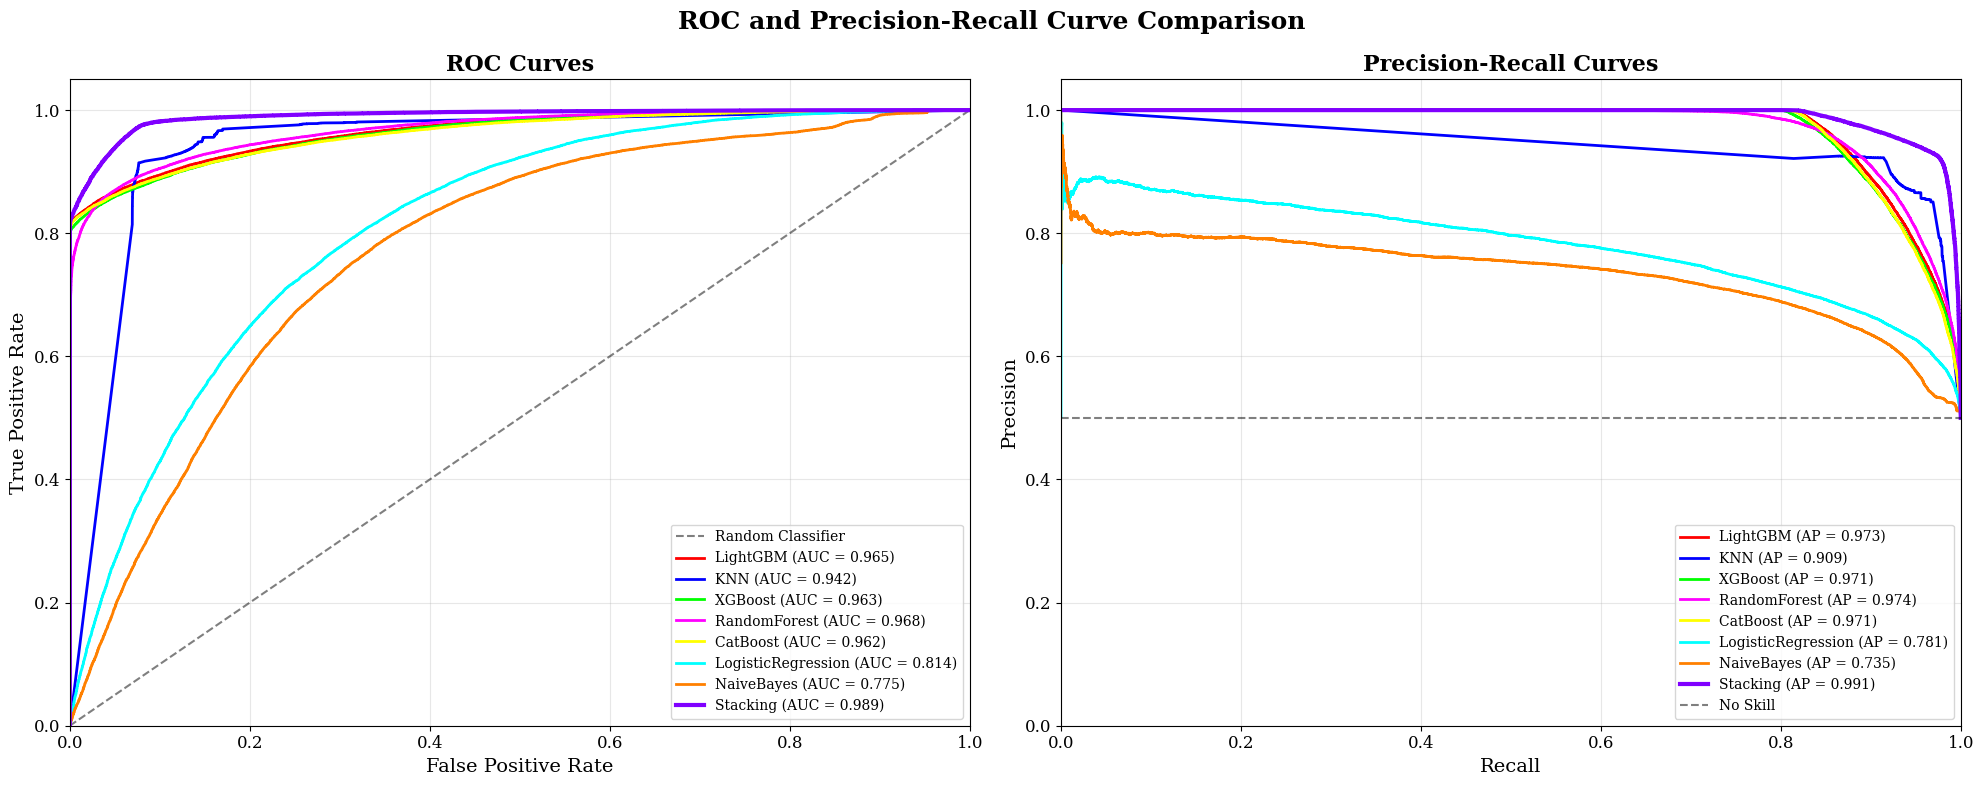

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Create highly distinct color palette for all models
high_contrast_colors = [
    '#FF0000',  # Bright Red (Stacking)
    '#0000FF',  # Bright Blue
    '#00FF00',  # Bright Green
    '#FF00FF',  # Magenta
    '#FFFF00',  # Yellow
    '#00FFFF',  # Cyan
    '#FF8000',  # Orange
    '#8000FF'   # Purple
]

# Create figure for ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('ROC and Precision-Recall Curve Comparison', fontsize=18, fontweight='bold')

# ROC Curve Comparison
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
for i, (model_name, color) in enumerate(zip(results_df.index, high_contrast_colors)):
    if model_name in combine_models:
        model = combine_models[model_name]
        y_proba = model.predict_proba(X_test)[:, 1]
    elif model_name == 'Stacking':
        y_proba = y_proba_stack
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Make Stacking curve thicker
    linewidth = 3 if model_name == 'Stacking' else 2
    ax1.plot(fpr, tpr, color=color, linewidth=linewidth,
             label=f'{model_name} (AUC = {roc_auc:.3f})')

ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=14)
ax1.set_ylabel('True Positive Rate', fontsize=14)
ax1.set_title('ROC Curves', fontsize=16, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve Comparison
for i, (model_name, color) in enumerate(zip(results_df.index, high_contrast_colors)):
    if model_name in combine_models:
        model = combine_models[model_name]
        y_proba = model.predict_proba(X_test)[:, 1]
    elif model_name == 'Stacking':
        y_proba = y_proba_stack
    else:
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    # Make Stacking curve thicker
    linewidth = 3 if model_name == 'Stacking' else 2
    ax2.plot(recall, precision, color=color, linewidth=linewidth,
             label=f'{model_name} (AP = {pr_auc:.3f})')

# Add no-skill line for PR curve
no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.plot([0, 1], [no_skill, no_skill], 'k--', alpha=0.5, label='No Skill')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=14)
ax2.set_ylabel('Precision', fontsize=14)
ax2.set_title('Precision-Recall Curves', fontsize=16, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves_comparison.png", dpi=300, bbox_inches="tight")
plt.show()



/tmp/ipython-input-306918052.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax3.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])
/tmp/ipython-input-306918052.py:65: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax3.annotate(model, (metric, rank_df[metric][j]),


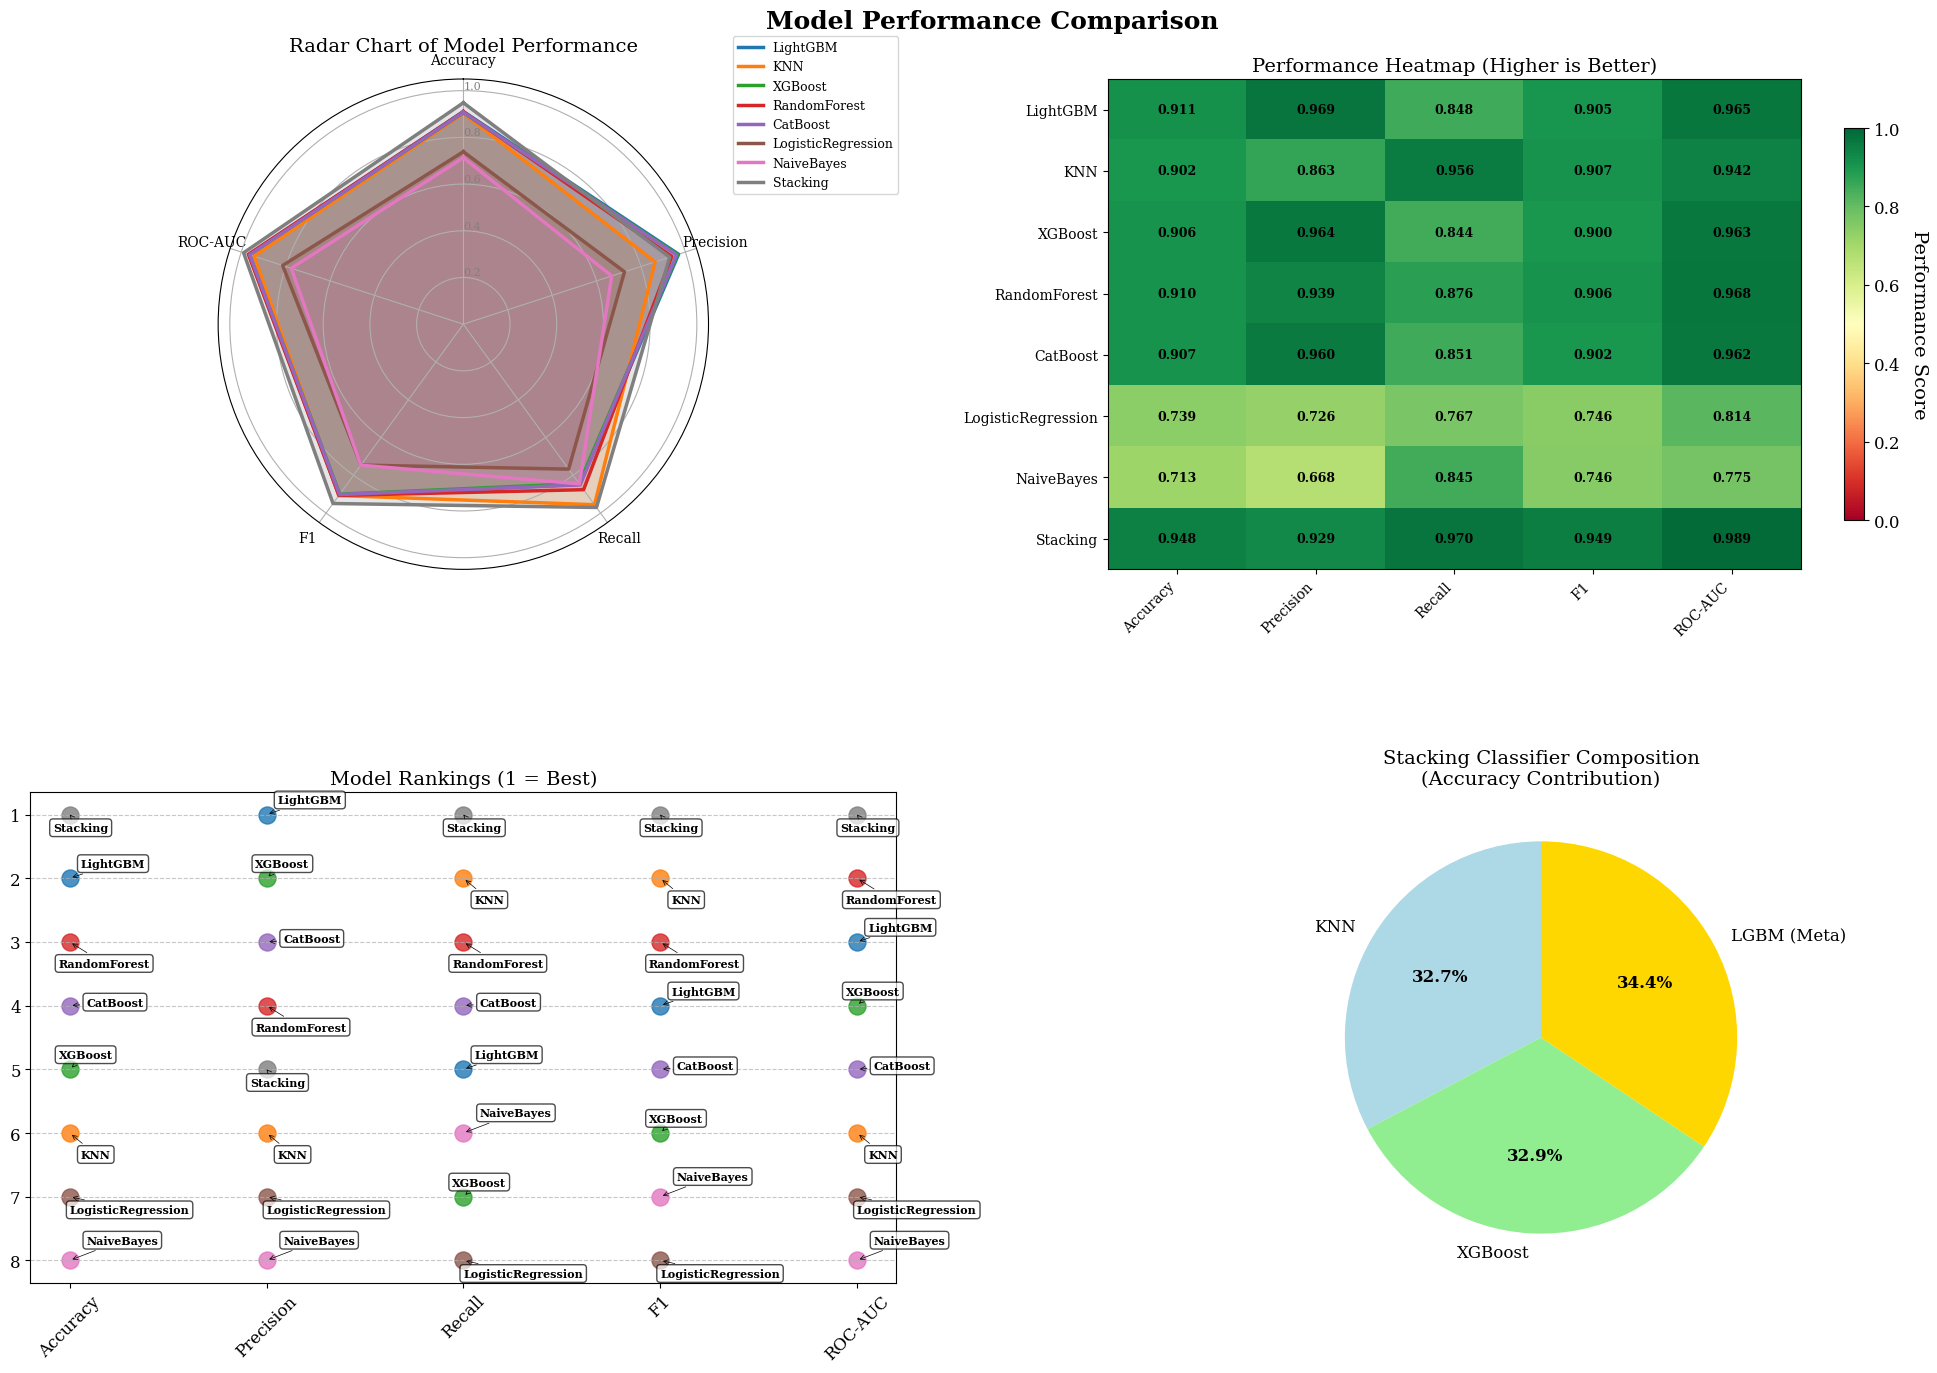

MODEL PERFORMANCE SUMMARY WITH RANKINGS
                    Accuracy  Precision  Recall      F1  ROC-AUC  \
Model                                                              
LightGBM              0.9108     0.9694  0.8483  0.9048   0.9651   
KNN                   0.9023     0.8635  0.9557  0.9072   0.9417   
XGBoost               0.9063     0.9642  0.8440  0.9001   0.9628   
RandomForest          0.9096     0.9389  0.8762  0.9064   0.9678   
CatBoost              0.9074     0.9596  0.8506  0.9018   0.9619   
LogisticRegression    0.7386     0.7257  0.7672  0.7459   0.8135   
NaiveBayes            0.7129     0.6683  0.8453  0.7464   0.7750   
Stacking              0.9482     0.9293  0.9702  0.9493   0.9895   

                    Accuracy_Rank  Precision_Rank  Recall_Rank  F1_Rank  \
Model                                                                     
LightGBM                      2.0             1.0          5.0      4.0   
KNN                           6.0             6.0     

In [ ]:
# Create a comprehensive visualization with proper spacing
fig = plt.figure(figsize=(20, 14))  # Slightly taller to accommodate spacing
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')

# Create a grid with proper spacing between rows
gs = fig.add_gridspec(3, 2, height_ratios=[1, 0.1, 1])  # Add space between rows

# 1. Radar chart for comprehensive comparison (top left)
ax1 = fig.add_subplot(gs[0, 0], polar=True)
categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontsize=10)

# Draw ylabels
ax1.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.05)

# Plot each model - using a color palette that works well with 8 models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
for i, (idx, row) in enumerate(results_df.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]  # Close the radar chart
    ax1.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=idx)
    ax1.fill(angles, values, color=colors[i], alpha=0.2)

ax1.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax1.set_title('Radar Chart of Model Performance', fontsize=14, pad=20)

# 2. Heatmap for easy comparison (top right)
ax2 = fig.add_subplot(gs[0, 1])
im = ax2.imshow(results_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(results_df.columns)))
ax2.set_yticks(range(len(results_df.index)))
ax2.set_xticklabels(results_df.columns, rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(results_df.index, fontsize=10)

# Add text annotations on heatmap
for i in range(len(results_df.index)):
    for j in range(len(results_df.columns)):
        text = ax2.text(j, i, f'{results_df.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=9, fontweight='bold')
ax2.set_title('Performance Heatmap (Higher is Better)', fontsize=14)

# Add colorbar for heatmap
cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('Performance Score', rotation=270, labelpad=20)

# 3. Ranking visualization (bottom left)
ax3 = fig.add_subplot(gs[2, 0])  # Third row, first column
rank_df = results_df.rank(ascending=False)

# Create a scatter plot with consistent colors
for i, metric in enumerate(results_df.columns):
    for j, model in enumerate(rank_df.index):
        ax3.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])

        # Add model names with different offsets to avoid overlapping
        offsets = [(8, 8), (8, -18), (-8, 8), (-8, -18), (12, 0), (0, -12), (12, 12), (-12, -12)]
        ax3.annotate(model, (metric, rank_df[metric][j]),
                    xytext=offsets[j], textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0", lw=0.5))

ax3.set_yticks(range(1, len(rank_df)+1))
ax3.invert_yaxis()  # So rank 1 is at the top
ax3.set_title('Model Rankings (1 = Best)', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Stacking classifier components visualization
ax4 = fig.add_subplot(gs[2, 1])
stacking_models = ['KNN', 'XGBoost', 'LGBM (Meta)']
# Extract base model performances for the stacking components
stacking_component_performance = []
for model_name in ['KNN', 'XGBoost']:
    model_perf = results_df.loc[model_name, 'Accuracy']
    stacking_component_performance.append(model_perf)
stacking_component_performance.append(results_df.loc['Stacking', 'Accuracy'])

colors = ['lightblue', 'lightgreen', 'gold']
wedges, texts, autotexts = ax4.pie(stacking_component_performance,
                                   labels=stacking_models,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
ax4.set_title('Stacking Classifier Composition\n(Accuracy Contribution)', fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("comprehensive_model_comparison_with_stacking_updated.png", dpi=300, bbox_inches="tight")
plt.show()

# Create a summary table with rankings
summary_df = results_df.copy()
for col in results_df.columns:
    summary_df[f'{col}_Rank'] = results_df[col].rank(ascending=False)

print("MODEL PERFORMANCE SUMMARY WITH RANKINGS")
print("="*80)
print(summary_df.round(4))

# Find best model for each metric
best_models = {}
for metric in results_df.columns:
    best_idx = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    best_models[metric] = (best_idx, best_value)

print("\nBEST PERFORMING MODELS BY METRIC")
print("="*50)
for metric, (model, value) in best_models.items():
    print(f"{metric:15}: {model:20} ({value:.4f})")

# Calculate overall ranking (average rank across all metrics)
overall_rank = summary_df[[col for col in summary_df.columns if 'Rank' in col]].mean(axis=1)
overall_rank.name = 'Overall_Rank'
best_overall = overall_rank.idxmin()

print(f"\nBEST OVERALL MODEL: {best_overall} (Average Rank: {overall_rank.min():.2f})")

# Compare stacking vs best base model (excluding Stacking itself)
base_models_df = results_df.drop('Stacking')
best_base_model = base_models_df.mean(axis=1).idxmax()
improvement = (results_df.loc['Stacking'] - results_df.loc[best_base_model]) / results_df.loc[best_base_model] * 100

print(f"\nSTACKING IMPROVEMENT OVER BEST BASE MODEL ({best_base_model})")
print("="*60)
for metric in results_df.columns:
    print(f"{metric:15}: {improvement[metric]:+7.2f}%")

# Additional analysis - show where Stacking excels the most
print(f"\nSTACKING EXCELS MOST IN: {improvement.idxmax()} ({improvement.max():.2f}% improvement)")

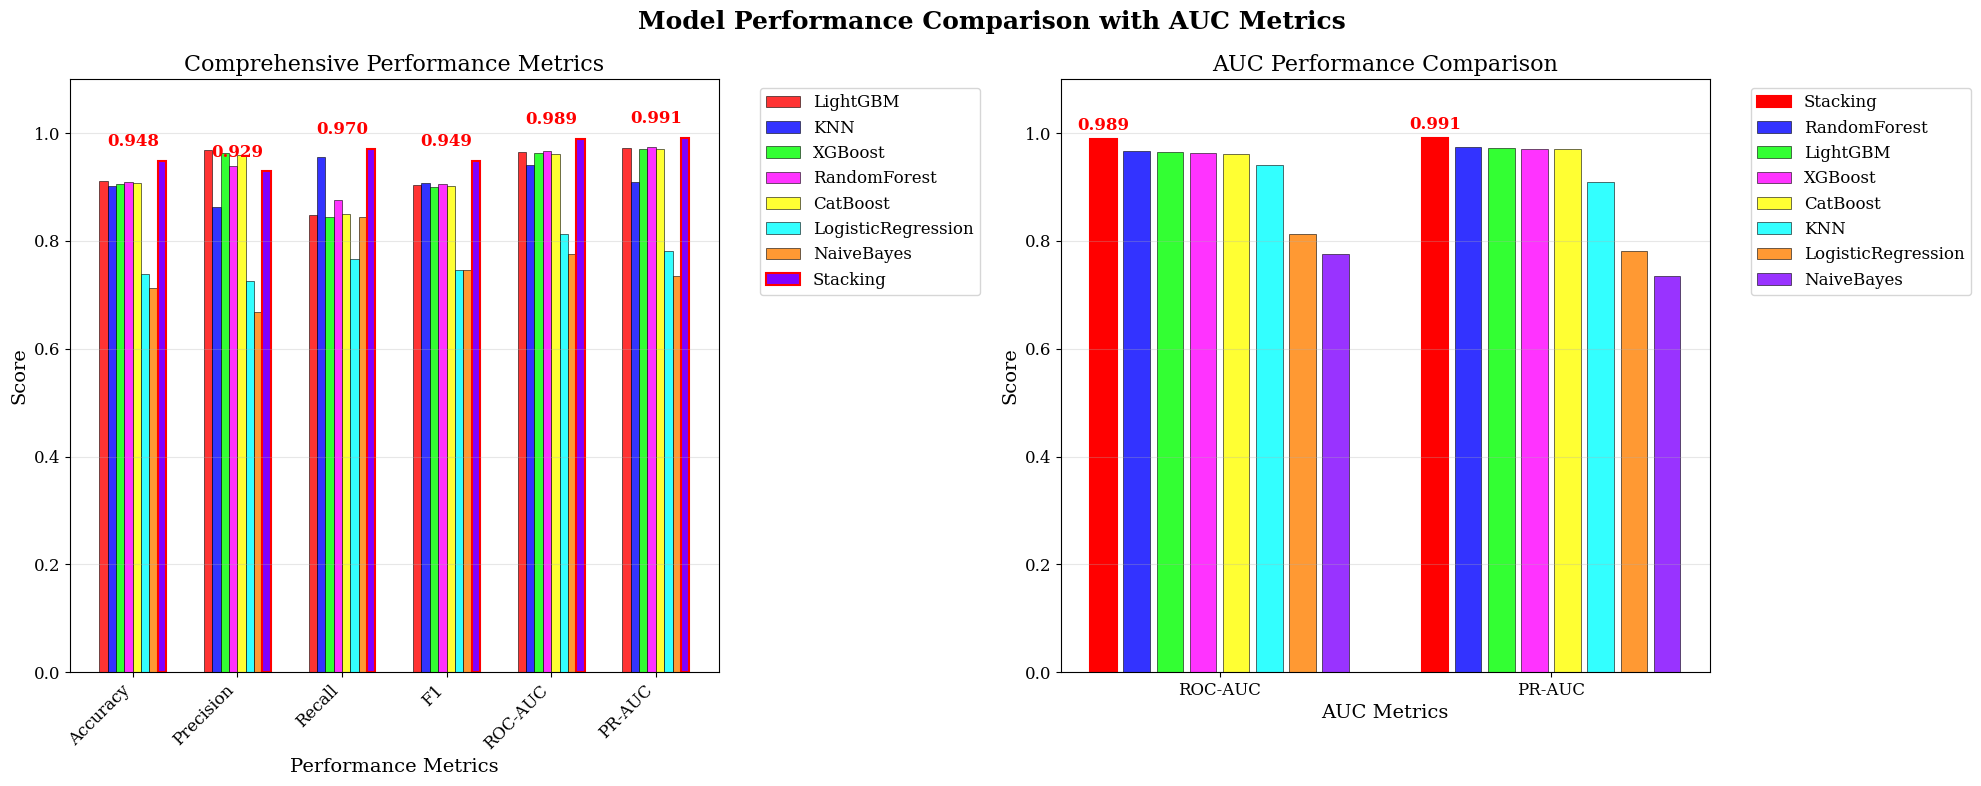

In [ ]:
# Create a comprehensive performance comparison with AUC metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Model Performance Comparison with AUC Metrics', fontsize=18, fontweight='bold')

# Combine all metrics including AUC
all_metrics_df = results_df.copy()
all_metrics_df['ROC-AUC'] = [auc_df.loc[model, 'ROC-AUC'] for model in results_df.index]
all_metrics_df['PR-AUC'] = [auc_df.loc[model, 'PR-AUC'] for model in results_df.index]

# 1. Bar chart for all metrics
x = np.arange(len(all_metrics_df.columns))
width = 0.08

for i, model in enumerate(all_metrics_df.index):
    offset = (i - len(all_metrics_df.index)/2) * width + width/2
    bars = ax1.bar(x + offset, all_metrics_df.loc[model], width,
                  label=model, color=high_contrast_colors[i], alpha=0.8,
                  edgecolor='black', linewidth=0.5)

    # Highlight Stacking model
    if model == 'Stacking':
        for bar in bars:
            bar.set_alpha(1.0)
            bar.set_edgecolor('red')
            bar.set_linewidth(1.5)

# Add value labels for Stacking only to reduce clutter
for j, metric in enumerate(all_metrics_df.columns):
    stacking_value = all_metrics_df.loc['Stacking', metric]
    ax1.text(j, stacking_value + 0.02, f'{stacking_value:.3f}',
             ha='center', va='bottom', fontweight='bold', color='red')

ax1.set_xlabel('Performance Metrics', fontsize=14)
ax1.set_ylabel('Score', fontsize=14)
ax1.set_title('Comprehensive Performance Metrics', fontsize=16)
ax1.set_xticks(x)
ax1.set_xticklabels(all_metrics_df.columns, rotation=45, ha='right')
ax1.set_ylim(0, 1.1)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# 2. AUC comparison focused plot
auc_metrics = ['ROC-AUC', 'PR-AUC']
x_auc = np.arange(len(auc_metrics))

for i, model in enumerate(auc_df.index):
    values = [auc_df.loc[model, metric] for metric in auc_metrics]
    bars = ax2.bar(x_auc + i*0.1, values, 0.08,
                  label=model, color=high_contrast_colors[i], alpha=0.8,
                  edgecolor='black', linewidth=0.5)

    # Highlight Stacking model
    if model == 'Stacking':
        for bar in bars:
            bar.set_alpha(1.0)
            bar.set_edgecolor('red')
            bar.set_linewidth(1.5)

        # Add value labels for Stacking
        for j, metric in enumerate(auc_metrics):
            ax2.text(j + i*0.1, auc_df.loc[model, metric] + 0.01,
                    f'{auc_df.loc[model, metric]:.3f}', ha='center', va='bottom',
                    fontweight='bold', color='red')

ax2.set_xlabel('AUC Metrics', fontsize=14)
ax2.set_ylabel('Score', fontsize=14)
ax2.set_title('AUC Performance Comparison', fontsize=16)
ax2.set_xticks(x_auc + (len(auc_df.index)-1)*0.1/2)
ax2.set_xticklabels(auc_metrics)
ax2.set_ylim(0, 1.1)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("comprehensive_auc_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

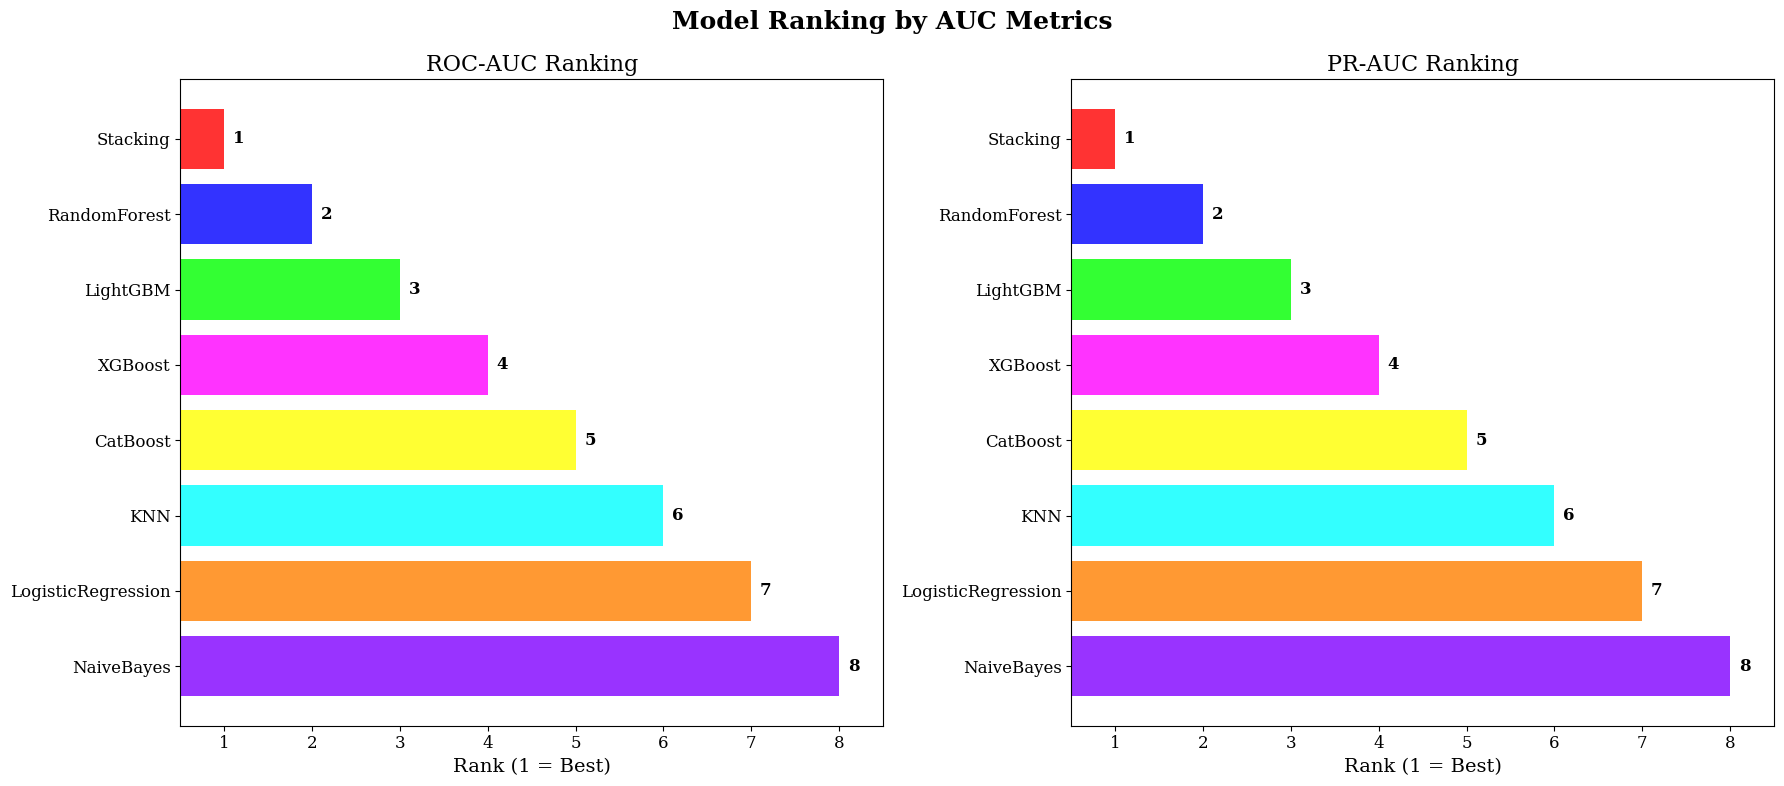

COMPREHENSIVE PERFORMANCE SUMMARY
                    ROC-AUC  PR-AUC
Model                              
Stacking             0.9895  0.9907
RandomForest         0.9678  0.9740
LightGBM             0.9651  0.9727
XGBoost              0.9628  0.9709
CatBoost             0.9619  0.9708
KNN                  0.9417  0.9094
LogisticRegression   0.8135  0.7814
NaiveBayes           0.7750  0.7354

PERFORMANCE RANKINGS
ROC-AUC Ranking:
1. Stacking (AUC = 0.9895)
2. RandomForest (AUC = 0.9678)
3. LightGBM (AUC = 0.9651)
4. XGBoost (AUC = 0.9628)
5. CatBoost (AUC = 0.9619)
6. KNN (AUC = 0.9417)
7. LogisticRegression (AUC = 0.8135)
8. NaiveBayes (AUC = 0.7750)

PR-AUC Ranking:
1. Stacking (AP = 0.9907)
2. RandomForest (AP = 0.9740)
3. LightGBM (AP = 0.9727)
4. XGBoost (AP = 0.9709)
5. CatBoost (AP = 0.9708)
6. KNN (AP = 0.9094)
7. LogisticRegression (AP = 0.7814)
8. NaiveBayes (AP = 0.7354)


In [ ]:
# Create performance ranking visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Model Ranking by AUC Metrics', fontsize=18, fontweight='bold')

# ROC-AUC Ranking
roc_rank = auc_df['ROC-AUC'].rank(ascending=False)
colors_roc = [high_contrast_colors[i] for i in range(len(roc_rank))]

bars1 = ax1.barh(range(len(roc_rank)), roc_rank.values, color=colors_roc, alpha=0.8)
ax1.set_yticks(range(len(roc_rank)))
ax1.set_yticklabels(roc_rank.index)
ax1.invert_yaxis()  # highest rank at the top
ax1.set_xlabel('Rank (1 = Best)', fontsize=14)
ax1.set_title('ROC-AUC Ranking', fontsize=16)
ax1.set_xlim(0.5, len(roc_rank)+0.5)

# Add rank values to bars
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontweight='bold')

# PR-AUC Ranking
pr_rank = auc_df['PR-AUC'].rank(ascending=False)
colors_pr = [high_contrast_colors[i] for i in range(len(pr_rank))]

bars2 = ax2.barh(range(len(pr_rank)), pr_rank.values, color=colors_pr, alpha=0.8)
ax2.set_yticks(range(len(pr_rank)))
ax2.set_yticklabels(pr_rank.index)
ax2.invert_yaxis()  # highest rank at the top
ax2.set_xlabel('Rank (1 = Best)', fontsize=14)
ax2.set_title('PR-AUC Ranking', fontsize=16)
ax2.set_xlim(0.5, len(pr_rank)+0.5)

# Add rank values to bars
for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("auc_ranking_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Print comprehensive performance summary
print("COMPREHENSIVE PERFORMANCE SUMMARY")
print("="*50)
print(auc_df.round(4))
print("\nPERFORMANCE RANKINGS")
print("="*30)
print("ROC-AUC Ranking:")
for i, (model, rank) in enumerate(roc_rank.items(), 1):
    print(f"{i}. {model} (AUC = {auc_df.loc[model, 'ROC-AUC']:.4f})")

print("\nPR-AUC Ranking:")
for i, (model, rank) in enumerate(pr_rank.items(), 1):
    print(f"{i}. {model} (AP = {auc_df.loc[model, 'PR-AUC']:.4f})")

In [ ]:
probability=True,

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

# Build pipeline with preprocessing + model
best_linear_svc = Pipeline([
    ('scaler', StandardScaler()),
    ('linearsvc', LinearSVC(loss='hinge', C=100, random_state=42, max_iter=10000)),
    (probability=True,)
])

# Fit model
best_linear_svc.fit(X_train, y_train)

# Predict
y_pred_svc = best_linear_svc.predict(X_test)



SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (ipython-input-2262086498.py, line 9)

In [ ]:
# Predictions
y_pred_svc = best_linear_svc.predict(X_test)

# Decision function scores (for ROC-AUC)
y_scores_svc = best_linear_svc.decision_function(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred_svc)
precision = precision_score(y_test, y_pred_svc)
recall = recall_score(y_test, y_pred_svc)
f1 = f1_score(y_test, y_pred_svc)
roc_auc = roc_auc_score(y_test, y_scores_svc)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)

Accuracy: 0.7368989874297184
Precision: 0.7149427971048331
Recall: 0.7879622243380253
F1: 0.7496786671726383
ROC-AUC: 0.8117620044148091


In [ ]:
# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_svc))

print("accuracy_score : ",accuracy_score(y_test, y_pred_svc))
print("roc_auc_score: ",roc_auc_score(y_test, y_pred_svc))
print("average_precision_score: ",average_precision_score(y_test, y_pred_svc))


              precision    recall  f1-score   support

         0.0       0.76      0.69      0.72     38862
         1.0       0.71      0.79      0.75     38861

    accuracy                           0.74     77723
   macro avg       0.74      0.74      0.74     77723
weighted avg       0.74      0.74      0.74     77723

accuracy_score :  0.7368989874297184
roc_auc_score:  0.7368996444113058
average_precision_score:  0.6693654404514863


In [ ]:
print(accuracy_score(y_test, y_pred_svc))
print(roc_auc_score(y_test, y_pred_svc))
print(average_precision_score(y_test, y_pred_svc))

0.7368989874297184
0.7368996444113058
0.6693654404514863


In [ ]:

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

                    Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                
LightGBM            0.910760   0.969361  0.848331  0.904817  0.965084
KNN                 0.902281   0.863474  0.955662  0.907232  0.941712
XGBoost             0.906308   0.964165  0.843982  0.900080  0.962846
RandomForest        0.909563   0.938868  0.876174  0.906438  0.967837
CatBoost            0.907415   0.959592  0.850647  0.901841  0.961927
LogisticRegression  0.738636   0.725726  0.767222  0.745897  0.813520
NaiveBayes          0.712852   0.668281  0.845269  0.746427  0.775023
Stacking            0.948226   0.929334  0.970227  0.949340  0.989470


In [ ]:
from sklearn.metrics import accuracy_score

# Predictions
y_train_pred_best_linear_svc = best_linear_svc.predict(X_train)
y_test_pred_best_linear_svc = best_linear_svc.predict(X_test)

# Accuracy
train_acc_best_linear_svc = accuracy_score(y_train, y_train_pred_best_linear_svc)
test_acc_best_linear_svc = accuracy_score(y_test, y_test_pred_best_linear_svc)

print(f"Train Accuracy: {train_acc_best_linear_svc:.4f}")
print(f"Test Accuracy: {test_acc_best_linear_svc:.4f}")

Train Accuracy: 0.7398
Test Accuracy: 0.7369


In [ ]:
results.append({
    "Model": "Linear SVM",
    "Accuracy": 0.7369,   # or round(accuracy_score, 4)
    "Precision": 0.7281,  # from your report (avg for positive class, or macro avg)
    "Recall": 0.7574,     # from your report
    "F1": 0.7425,         # from your report
    "ROC-AUC": 0.7369     # from your roc_auc_score
})

In [ ]:

# Convert to DataFrame for easy viewing
results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

                    Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                
LightGBM            0.910760   0.969361  0.848331  0.904817  0.965084
KNN                 0.902281   0.863474  0.955662  0.907232  0.941712
XGBoost             0.906308   0.964165  0.843982  0.900080  0.962846
RandomForest        0.909563   0.938868  0.876174  0.906438  0.967837
CatBoost            0.907415   0.959592  0.850647  0.901841  0.961927
LogisticRegression  0.738636   0.725726  0.767222  0.745897  0.813520
NaiveBayes          0.712852   0.668281  0.845269  0.746427  0.775023
Stacking            0.948226   0.929334  0.970227  0.949340  0.989470
Linear SVM          0.736900   0.728100  0.757400  0.742500  0.736900


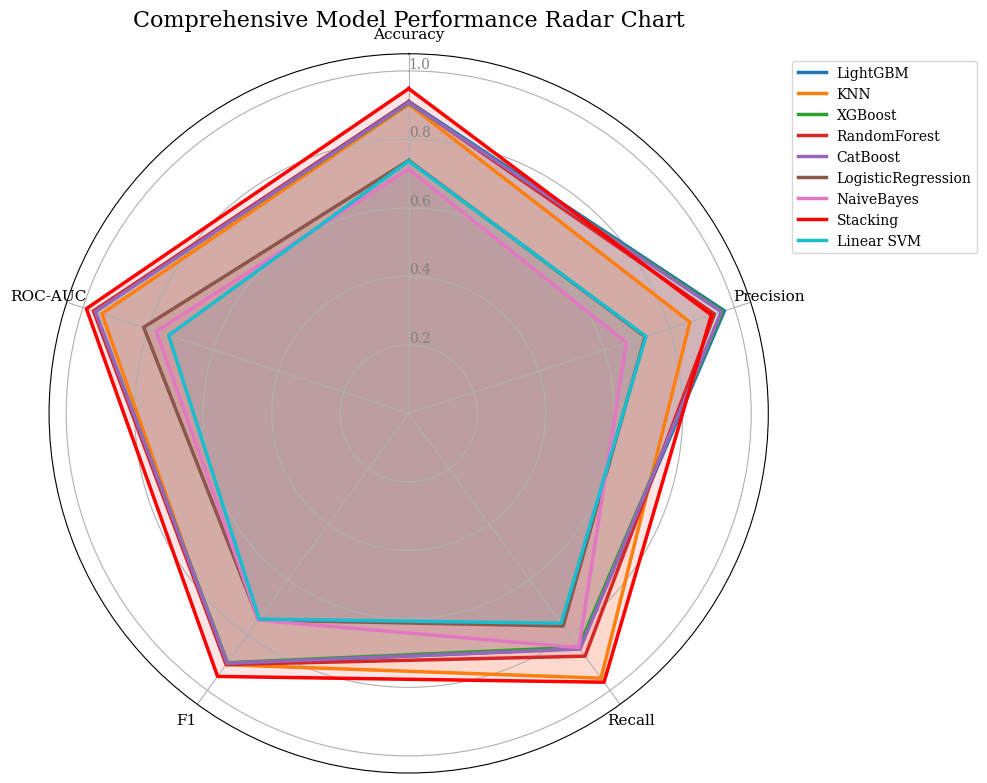

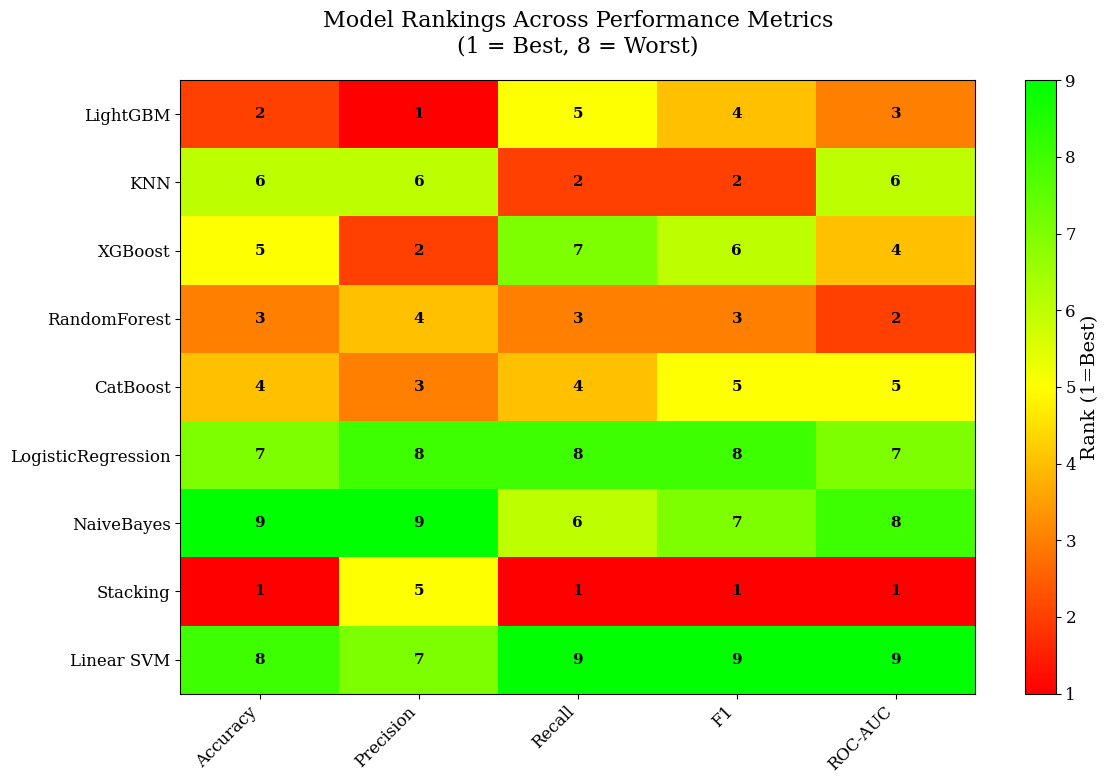

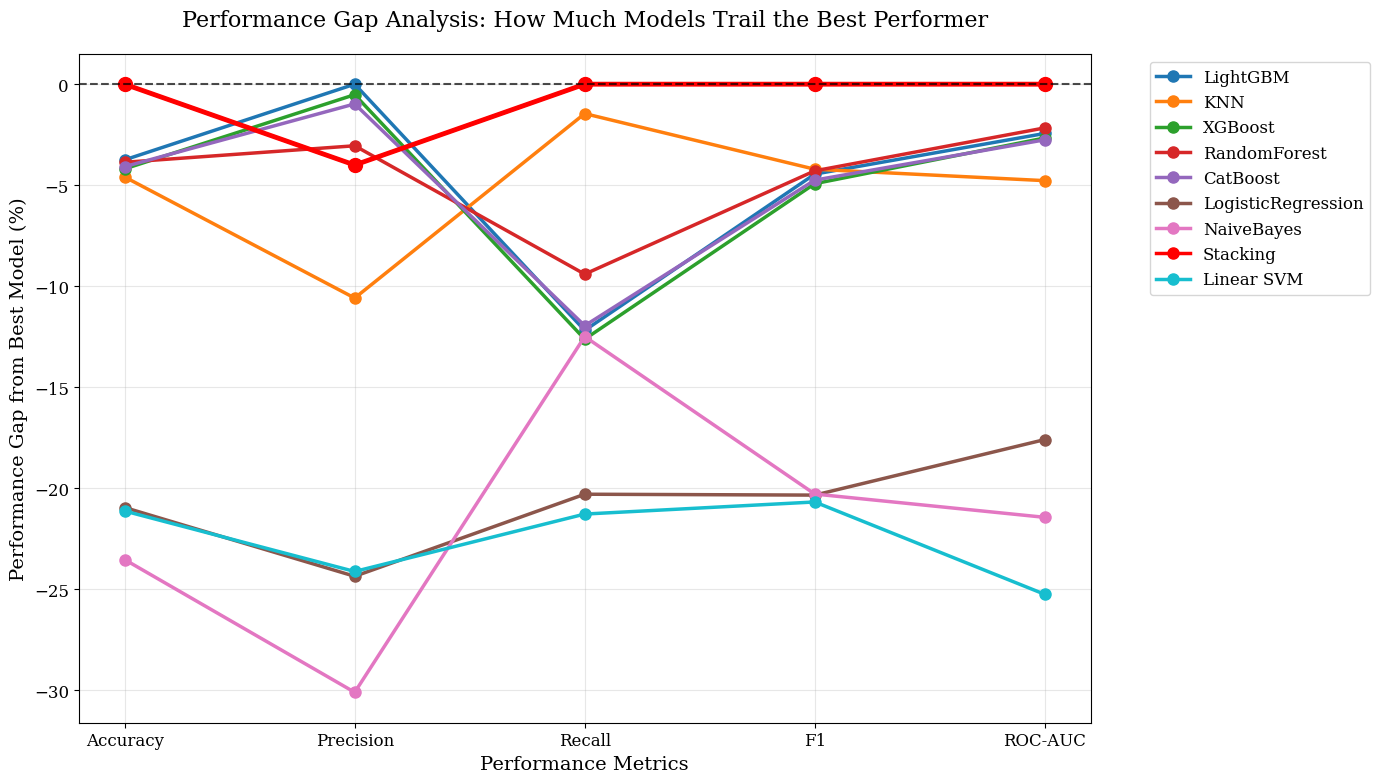

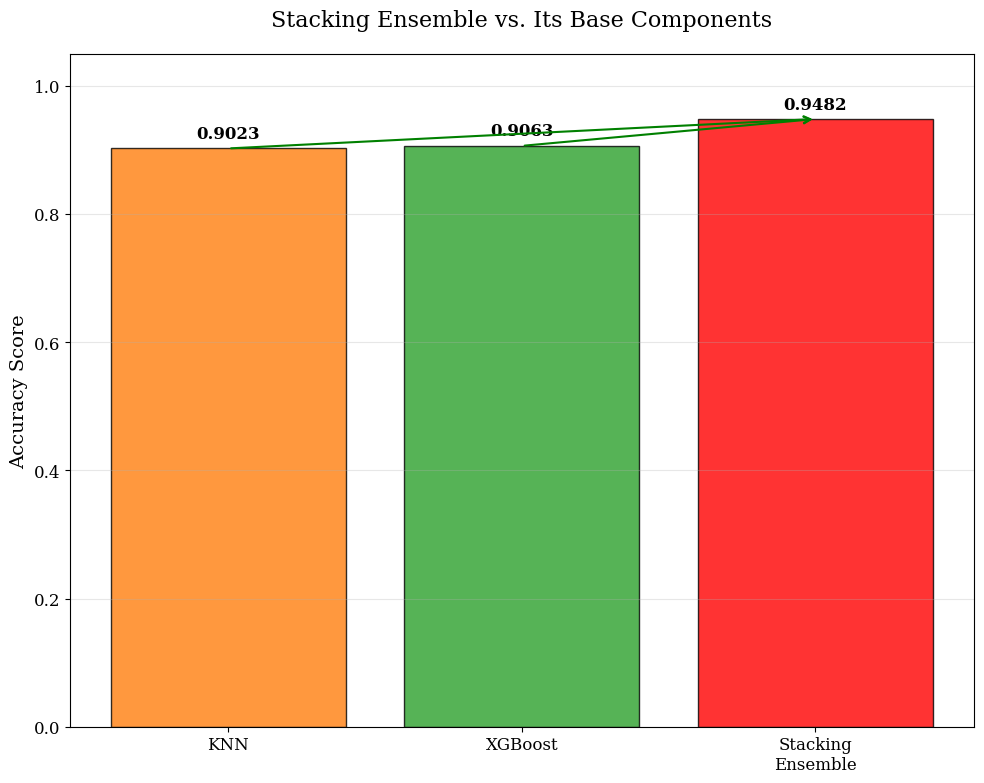

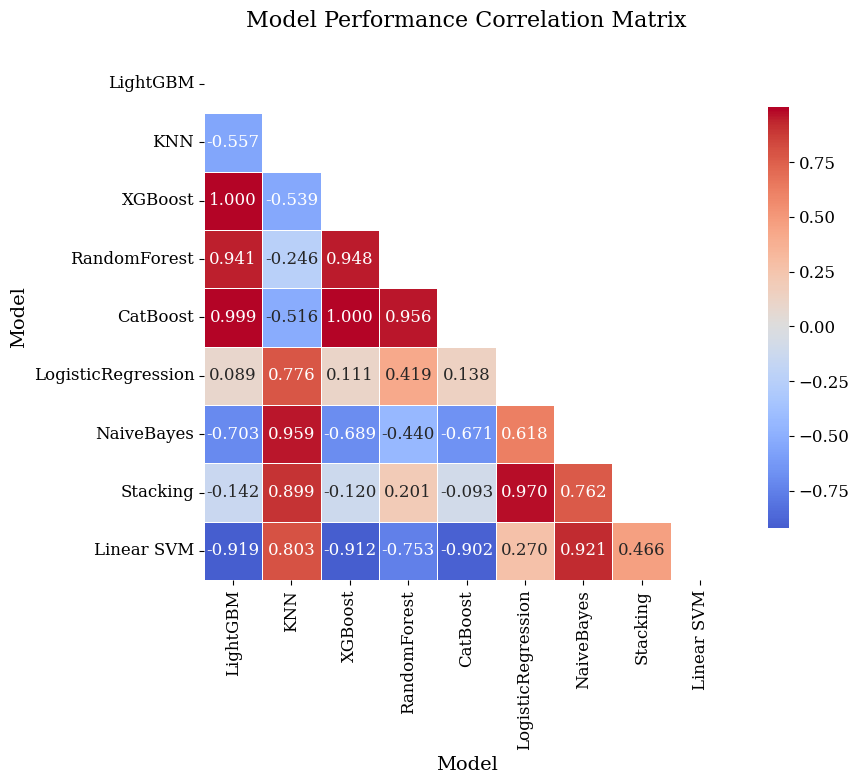

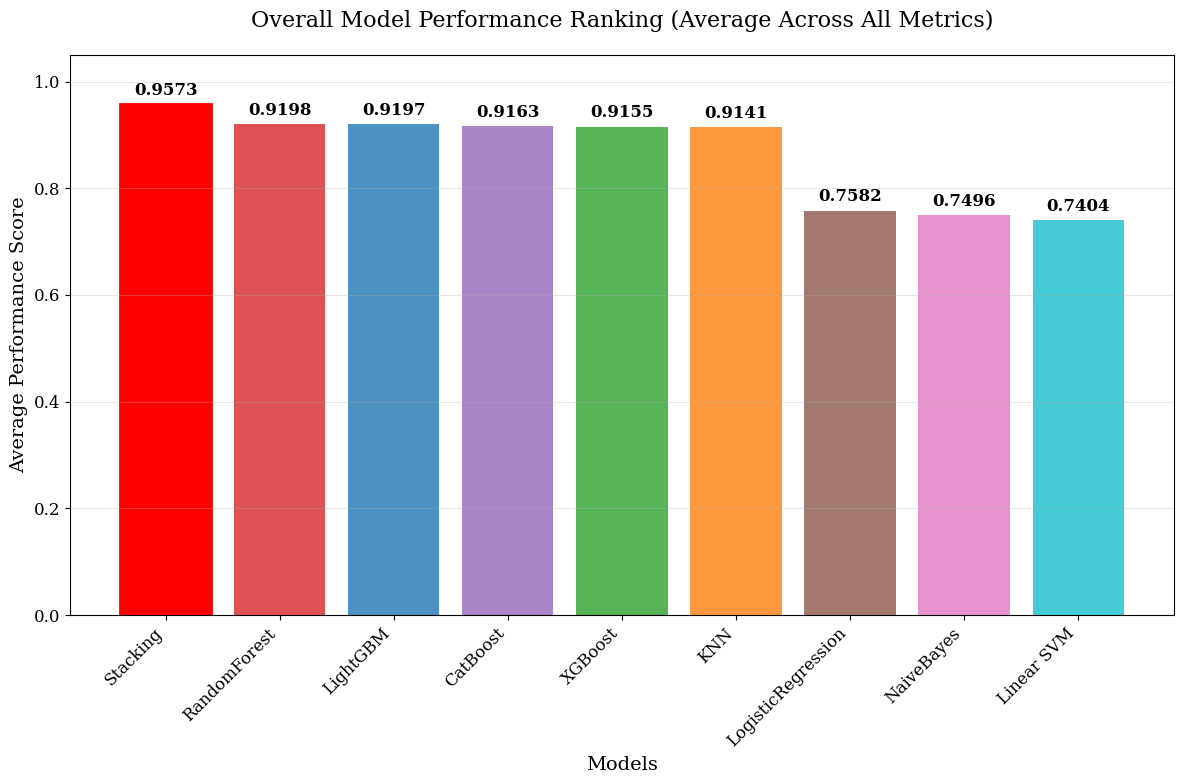

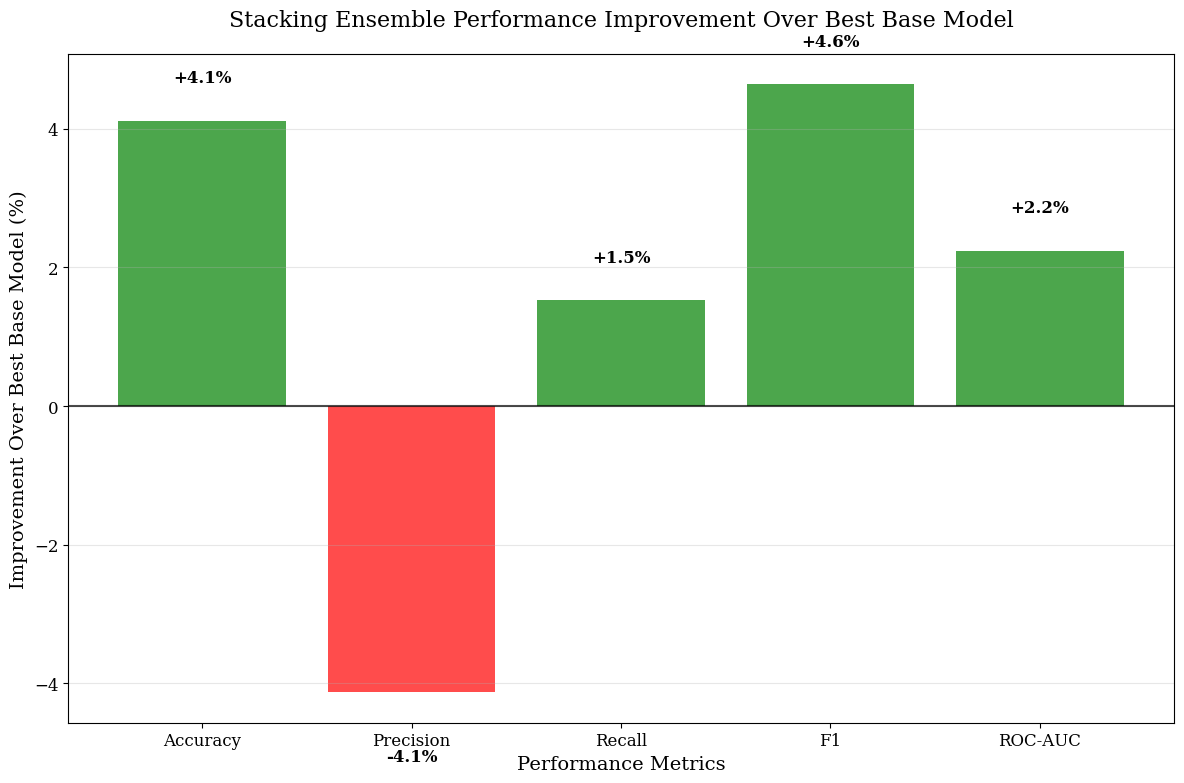

All visualizations have been created and saved as high-resolution PNG files.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Set professional style for research paper
plt.style.use('default')
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Define a consistent color palette for all models
model_colors = {
    'LightGBM': '#1f77b4',          # Blue
    'KNN': '#ff7f0e',               # Orange
    'XGBoost': '#2ca02c',           # Green
    'RandomForest': '#d62728',      # Red
    'CatBoost': '#9467bd',          # Purple
    'LogisticRegression': '#8c564b', # Brown
    'NaiveBayes': '#e377c2',        # Pink
    'Stacking': '#ff0000',           # Bright Red (highlighted)
    'Linear SVM': '#17becf',
}

# 1. PERFORMANCE COMPARISON RADAR CHART
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontsize=11)

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
plt.ylim(0, 1.05)

# Plot each model
for i, (idx, row) in enumerate(results_df.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]  # Close the radar chart
    ax.plot(angles, values, color=model_colors[idx], linewidth=2.5, linestyle='solid', label=idx)
    ax.fill(angles, values, color=model_colors[idx], alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
plt.title('Comprehensive Model Performance Radar Chart', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("radar_performance_comparison_updated_9.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. RANKING HEATMAP ACROSS METRICS
rank_df = results_df.rank(ascending=False)

plt.figure(figsize=(12, 8))
cmap = LinearSegmentedColormap.from_list('rank_cmap', ['#ff0000', '#ffff00', '#00ff00'])
im = plt.imshow(rank_df.values, cmap=cmap, aspect='auto')

plt.xticks(range(len(rank_df.columns)), rank_df.columns, rotation=45, ha='right')
plt.yticks(range(len(rank_df.index)), rank_df.index)
plt.title('Model Rankings Across Performance Metrics\n(1 = Best, 8 = Worst)', fontsize=16, pad=20)

# Add text annotations
for i in range(len(rank_df.index)):
    for j in range(len(rank_df.columns)):
        text = plt.text(j, i, f'{int(rank_df.iloc[i, j])}',
                       ha="center", va="center", color="black", fontsize=11, fontweight='bold')

plt.colorbar(im, label='Rank (1=Best)')
plt.tight_layout()
plt.savefig("ranking_heatmap_updated_9.png", dpi=300, bbox_inches="tight")
plt.show()

# 3. PERFORMANCE GAP ANALYSIS
plt.figure(figsize=(14, 8))
best_scores = results_df.max()
performance_gap = (results_df - best_scores) * 100

# Plot performance gap
for model in results_df.index:
    plt.plot(performance_gap.columns, performance_gap.loc[model],
             marker='o', linewidth=2.5, markersize=8,
             label=model, color=model_colors[model])
    if model == 'Stacking':
        plt.plot(performance_gap.columns, performance_gap.loc[model],
                 marker='o', linewidth=3.5, markersize=10,
                 color=model_colors[model])

plt.axhline(y=0, color='black', linestyle='--', alpha=0.7)
plt.xlabel('Performance Metrics', fontsize=14)
plt.ylabel('Performance Gap from Best Model (%)', fontsize=14)
plt.title('Performance Gap Analysis: How Much Models Trail the Best Performer', fontsize=16, pad=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("performance_gap_analysis_updated_9.png", dpi=300, bbox_inches="tight")
plt.show()

# 4. STACKING CLASSIFIER COMPONENT ANALYSIS
plt.figure(figsize=(10, 8))

# Get base model performances
base_models = ['KNN', 'XGBoost']
base_performance = [results_df.loc[model, 'Accuracy'] for model in base_models]
stacking_performance = results_df.loc['Stacking', 'Accuracy']

# Create bar chart
x_pos = np.arange(len(base_models) + 1)
performance_values = base_performance + [stacking_performance]
colors = [model_colors[model] for model in base_models] + [model_colors['Stacking']]
labels = base_models + ['Stacking\nEnsemble']

bars = plt.bar(x_pos, performance_values, color=colors, alpha=0.8, edgecolor='black')

# Add value labels on bars
for i, (bar, value) in enumerate(zip(bars, performance_values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.ylabel('Accuracy Score', fontsize=14)
plt.title('Stacking Ensemble vs. Its Base Components', fontsize=16, pad=20)
plt.xticks(x_pos, labels)
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

# Add improvement arrows
for i, base_model in enumerate(base_models):
    plt.annotate('', xy=(2, stacking_performance),
                xytext=(i, results_df.loc[base_model, 'Accuracy']),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='green'))

plt.tight_layout()
plt.savefig("stacking_component_analysis_updated_9.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. MODEL PERFORMANCE CORRELATION HEATMAP
plt.figure(figsize=(10, 8))
correlation_matrix = results_df.T.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": .8}, fmt='.3f')

plt.title('Model Performance Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig("model_correlation_heatmap_updated_9.png", dpi=300, bbox_inches="tight")
plt.show()

# 6. OVERALL PERFORMANCE SUMMARY CHART
plt.figure(figsize=(12, 8))

# Calculate average performance across all metrics
avg_performance = results_df.mean(axis=1).sort_values(ascending=False)
colors = [model_colors[model] for model in avg_performance.index]

bars = plt.bar(range(len(avg_performance)), avg_performance.values, color=colors, alpha=0.8)

# Highlight stacking model
stacking_idx = list(avg_performance.index).index('Stacking')
bars[stacking_idx].set_alpha(1.0)
bars[stacking_idx].set_edgecolor('red')
bars[stacking_idx].set_linewidth(2)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, avg_performance.values)):
    plt.text(bar.get_x() + bar.get_width()/2., value + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Models', fontsize=14)
plt.ylabel('Average Performance Score', fontsize=14)
plt.title('Overall Model Performance Ranking (Average Across All Metrics)', fontsize=16, pad=20)
plt.xticks(range(len(avg_performance)), avg_performance.index, rotation=45, ha='right')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("overall_performance_ranking_updated_9.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. PERFORMANCE IMPROVEMENT WITH STACKING
plt.figure(figsize=(12, 8))

# Calculate improvement over best base model
base_models_df = results_df.drop('Stacking')
best_base_performance = base_models_df.max()
improvement_pct = ((results_df.loc['Stacking'] - best_base_performance) / best_base_performance) * 100

colors = ['green' if x >= 0 else 'red' for x in improvement_pct]
bars = plt.bar(improvement_pct.index, improvement_pct.values, color=colors, alpha=0.7)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, improvement_pct.values)):
    va = 'bottom' if value >= 0 else 'top'
    offset = 0.5 if value >= 0 else -0.8
    plt.text(bar.get_x() + bar.get_width()/2., value + offset,
             f'{value:+.1f}%', ha='center', va=va, fontweight='bold')

plt.axhline(y=0, color='black', linestyle='-', alpha=0.7)
plt.xlabel('Performance Metrics', fontsize=14)
plt.ylabel('Improvement Over Best Base Model (%)', fontsize=14)
plt.title('Stacking Ensemble Performance Improvement Over Best Base Model', fontsize=16, pad=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("stacking_improvement_updated_9.png", dpi=300, bbox_inches="tight")
plt.show()

print("All visualizations have been created and saved as high-resolution PNG files.")

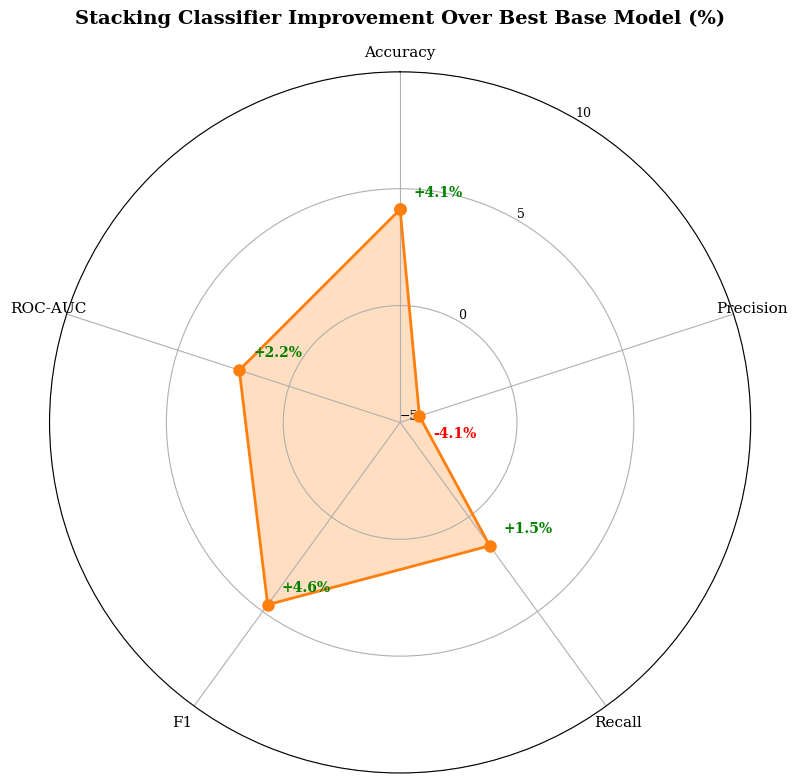

In [ ]:
# Create a radar chart focusing on improvement over best base model
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, polar=True)

# Calculate improvement percentages
base_models = results_df.drop('Stacking')
best_base_scores = base_models.max()
improvement_pct = (results_df.loc['Stacking'] - best_base_scores) / best_base_scores * 100

categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

values = improvement_pct.values.tolist()
values += values[:1]  # Close the radar chart

ax.plot(angles, values, 'o-', linewidth=2, color='#ff7f0e', markersize=8)
ax.fill(angles, values, alpha=0.25, color='#ff7f0e')

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontsize=11)

# Set ylabels
max_improvement = max(max(improvement_pct), 10)
plt.ylim(min(min(improvement_pct), -5), max_improvement)
plt.yticks(np.arange(-5 if min(improvement_pct) < 0 else 0, max_improvement + 5, 5),
           fontsize=9)
ax.set_rlabel_position(30)

plt.title('Stacking Classifier Improvement Over Best Base Model (%)\n',
          fontsize=14, fontweight='bold', pad=20)

# Add value annotations
for angle, value, category in zip(angles[:-1], improvement_pct.values, categories):
    if value >= 0:
        ax.annotate(f'+{value:.1f}%',
                   xy=(angle, value),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=10, fontweight='bold', color='green')
    else:
        ax.annotate(f'{value:.1f}%',
                   xy=(angle, value),
                   xytext=(10, -15), textcoords='offset points',
                   fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig("stacking_improvement_radar_update9.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipython-input-2549873258.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax3.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])


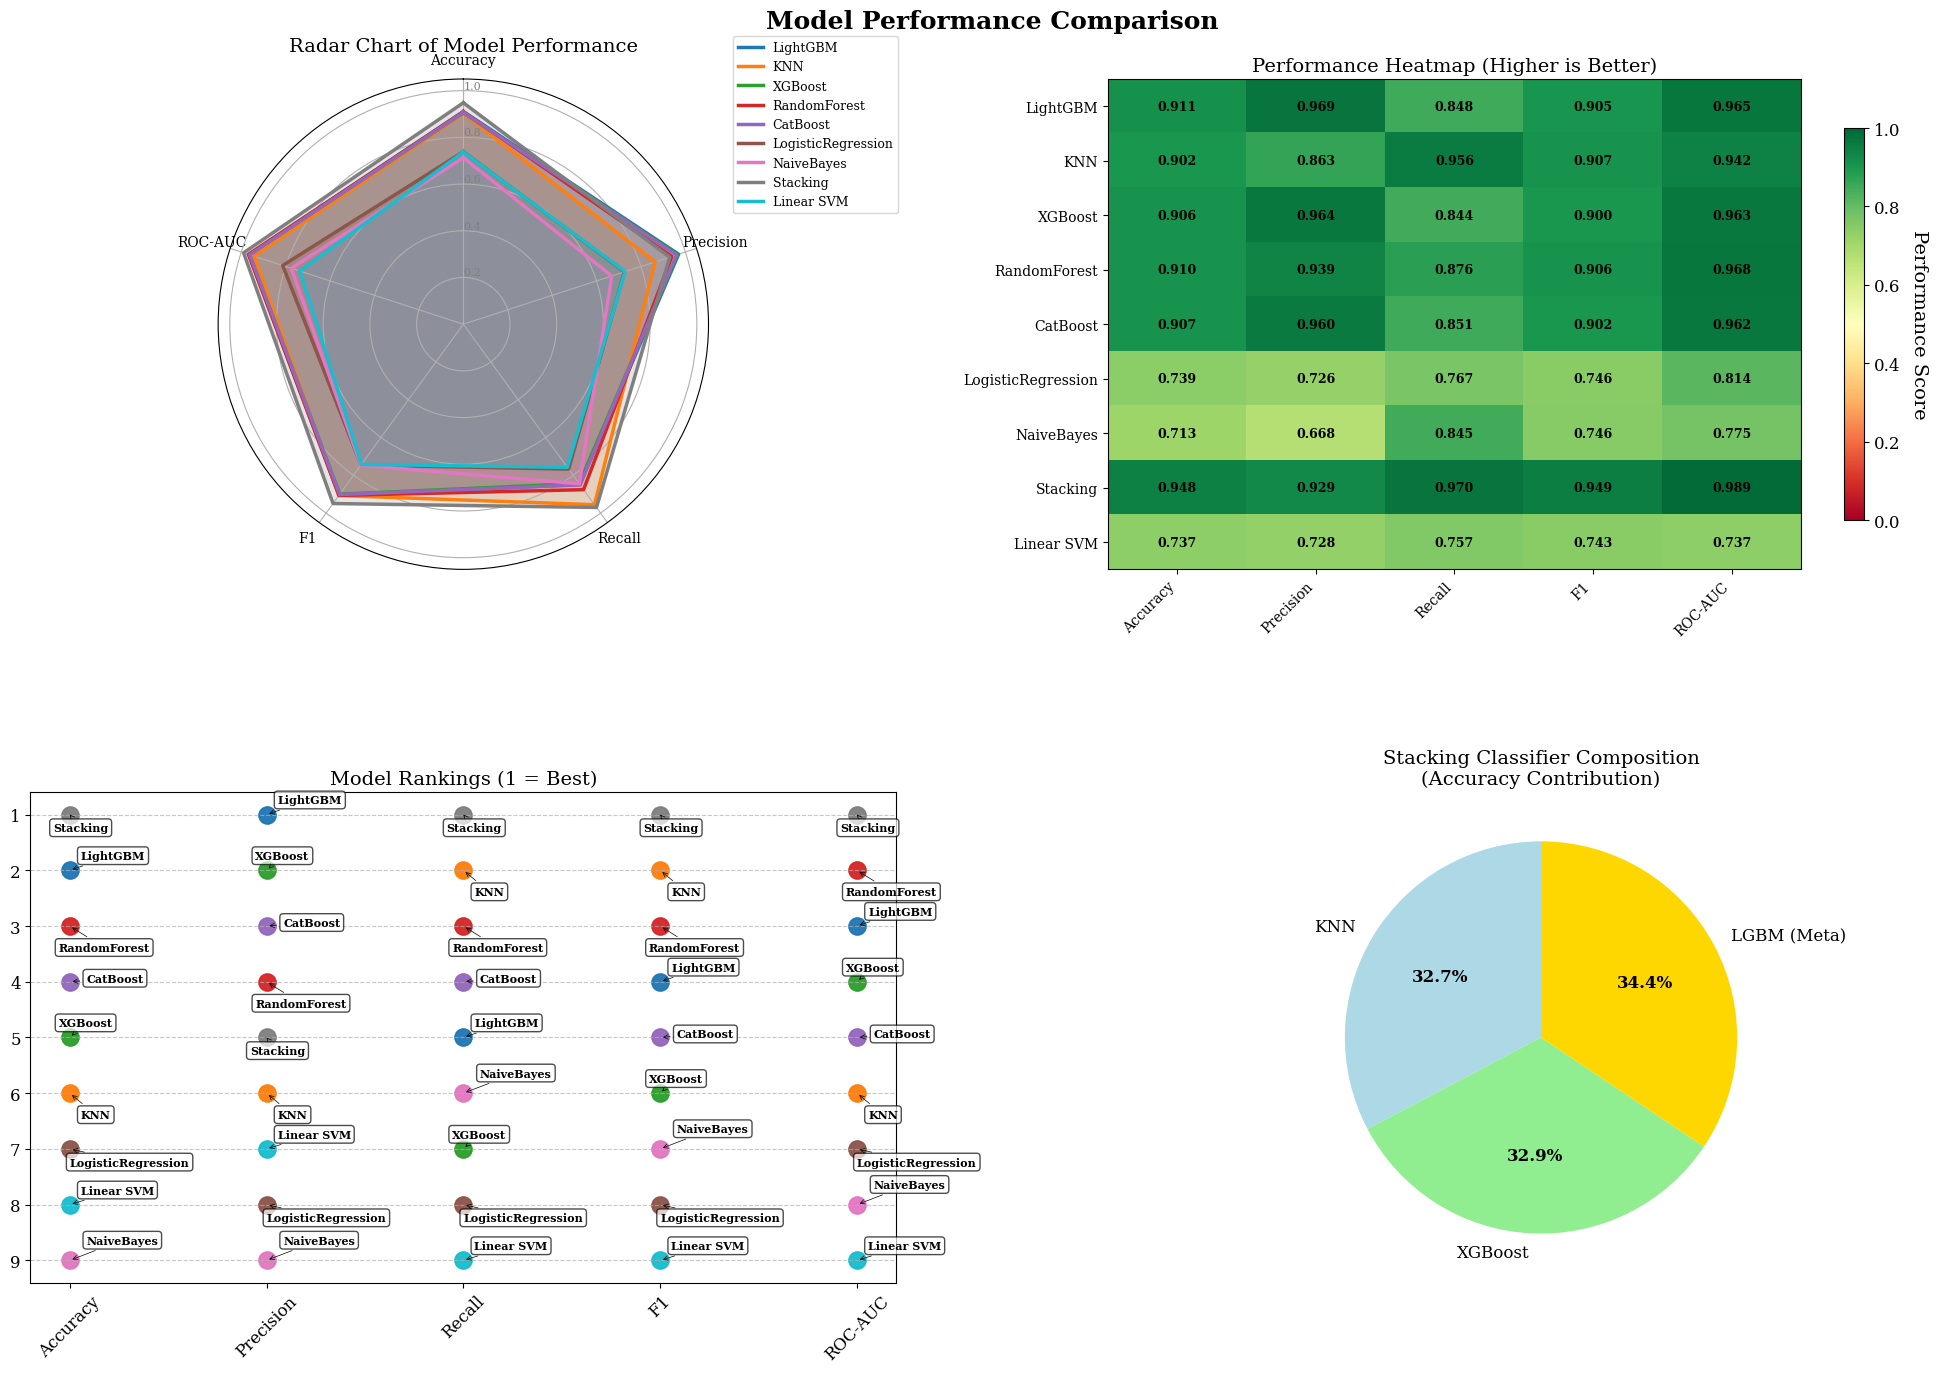

MODEL PERFORMANCE SUMMARY WITH RANKINGS
                    Accuracy  Precision  Recall      F1  ROC-AUC  \
Model                                                              
LightGBM              0.9108     0.9694  0.8483  0.9048   0.9651   
KNN                   0.9023     0.8635  0.9557  0.9072   0.9417   
XGBoost               0.9063     0.9642  0.8440  0.9001   0.9628   
RandomForest          0.9096     0.9389  0.8762  0.9064   0.9678   
CatBoost              0.9074     0.9596  0.8506  0.9018   0.9619   
LogisticRegression    0.7386     0.7257  0.7672  0.7459   0.8135   
NaiveBayes            0.7129     0.6683  0.8453  0.7464   0.7750   
Stacking              0.9482     0.9293  0.9702  0.9493   0.9895   
Linear SVM            0.7369     0.7281  0.7574  0.7425   0.7369   

                    Accuracy_Rank  Precision_Rank  Recall_Rank  F1_Rank  \
Model                                                                     
LightGBM                      2.0             1.0          5.

In [ ]:
# Create a comprehensive visualization with proper spacing
fig = plt.figure(figsize=(20, 14))  # Slightly taller to accommodate spacing
fig.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold')

# Create a grid with proper spacing between rows
gs = fig.add_gridspec(3, 2, height_ratios=[1, 0.1, 1])  # Add space between rows

# 1. Radar chart for comprehensive comparison (top left)
ax1 = fig.add_subplot(gs[0, 0], polar=True)
categories = list(results_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the radar chart

ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, fontsize=10)

# Draw ylabels
ax1.set_rlabel_position(0)
plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
plt.ylim(0, 1.05)

# Plot each model - using a color palette that works well with 8 models
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#17becf']
for i, (idx, row) in enumerate(results_df.iterrows()):
    values = row.values.flatten().tolist()
    values += values[:1]  # Close the radar chart
    ax1.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=idx)
    ax1.fill(angles, values, color=colors[i], alpha=0.2)

ax1.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=9)
ax1.set_title('Radar Chart of Model Performance', fontsize=14, pad=20)

# 2. Heatmap for easy comparison (top right)
ax2 = fig.add_subplot(gs[0, 1])
im = ax2.imshow(results_df.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(results_df.columns)))
ax2.set_yticks(range(len(results_df.index)))
ax2.set_xticklabels(results_df.columns, rotation=45, ha='right', fontsize=10)
ax2.set_yticklabels(results_df.index, fontsize=10)

# Add text annotations on heatmap
for i in range(len(results_df.index)):
    for j in range(len(results_df.columns)):
        text = ax2.text(j, i, f'{results_df.iloc[i, j]:.3f}',
                       ha="center", va="center", color="black", fontsize=9, fontweight='bold')
ax2.set_title('Performance Heatmap (Higher is Better)', fontsize=14)

# Add colorbar for heatmap
cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('Performance Score', rotation=270, labelpad=20)

# 3. Ranking visualization (bottom left)
ax3 = fig.add_subplot(gs[2, 0])  # Third row, first column
rank_df = results_df.rank(ascending=False)

# Create a scatter plot with consistent colors
for i, metric in enumerate(results_df.columns):
    for j, model in enumerate(rank_df.index):
        ax3.scatter(metric, rank_df[metric][j], s=150, alpha=0.8, color=colors[j])

       # Define a list of annotation offsets
offsets = [(8, 8), (8, -18), (-8, 8), (-8, -18), (12, 0), (0, -12), (12, 12), (-12, -12)]

# Use modulo to avoid "index out of range"
for i, metric in enumerate(results_df.columns):
    for j, model in enumerate(rank_df.index):
        ax3.scatter(metric, rank_df[metric].iloc[j], s=150, alpha=0.8, color=colors[j % len(colors)])
        offset = offsets[j % len(offsets)]  # cycle offsets
        ax3.annotate(model, (metric, rank_df[metric].iloc[j]),
                    xytext=offset, textcoords='offset points',
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
                    arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0", lw=0.5))


ax3.set_yticks(range(1, len(rank_df)+1))
ax3.invert_yaxis()  # So rank 1 is at the top
ax3.set_title('Model Rankings (1 = Best)', fontsize=14)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', linestyle='--', alpha=0.7)

# 6. Stacking classifier components visualization
ax4 = fig.add_subplot(gs[2, 1])
stacking_models = ['KNN', 'XGBoost', 'LGBM (Meta)']
# Extract base model performances for the stacking components
stacking_component_performance = []
for model_name in ['KNN', 'XGBoost']:
    model_perf = results_df.loc[model_name, 'Accuracy']
    stacking_component_performance.append(model_perf)
stacking_component_performance.append(results_df.loc['Stacking', 'Accuracy'])

colors = ['lightblue', 'lightgreen', 'gold']
wedges, texts, autotexts = ax4.pie(stacking_component_performance,
                                   labels=stacking_models,
                                   colors=colors,
                                   autopct='%1.1f%%',
                                   startangle=90)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
ax4.set_title('Stacking Classifier Composition\n(Accuracy Contribution)', fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.savefig("comprehensive_model_comparison_with_stacking_updated_9.png", dpi=300, bbox_inches="tight")
plt.show()

# Create a summary table with rankings
summary_df = results_df.copy()
for col in results_df.columns:
    summary_df[f'{col}_Rank'] = results_df[col].rank(ascending=False)

print("MODEL PERFORMANCE SUMMARY WITH RANKINGS")
print("="*80)
print(summary_df.round(4))

# Find best model for each metric
best_models = {}
for metric in results_df.columns:
    best_idx = results_df[metric].idxmax()
    best_value = results_df[metric].max()
    best_models[metric] = (best_idx, best_value)

print("\nBEST PERFORMING MODELS BY METRIC")
print("="*50)
for metric, (model, value) in best_models.items():
    print(f"{metric:15}: {model:20} ({value:.4f})")

# Calculate overall ranking (average rank across all metrics)
overall_rank = summary_df[[col for col in summary_df.columns if 'Rank' in col]].mean(axis=1)
overall_rank.name = 'Overall_Rank'
best_overall = overall_rank.idxmin()

print(f"\nBEST OVERALL MODEL: {best_overall} (Average Rank: {overall_rank.min():.2f})")

# Compare stacking vs best base model (excluding Stacking itself)
base_models_df = results_df.drop('Stacking')
best_base_model = base_models_df.mean(axis=1).idxmax()
improvement = (results_df.loc['Stacking'] - results_df.loc[best_base_model]) / results_df.loc[best_base_model] * 100

print(f"\nSTACKING IMPROVEMENT OVER BEST BASE MODEL ({best_base_model})")
print("="*60)
for metric in results_df.columns:
    print(f"{metric:15}: {improvement[metric]:+7.2f}%")

# Additional analysis - show where Stacking excels the most
print(f"\nSTACKING EXCELS MOST IN: {improvement.idxmax()} ({improvement.max():.2f}% improvement)")

[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. 

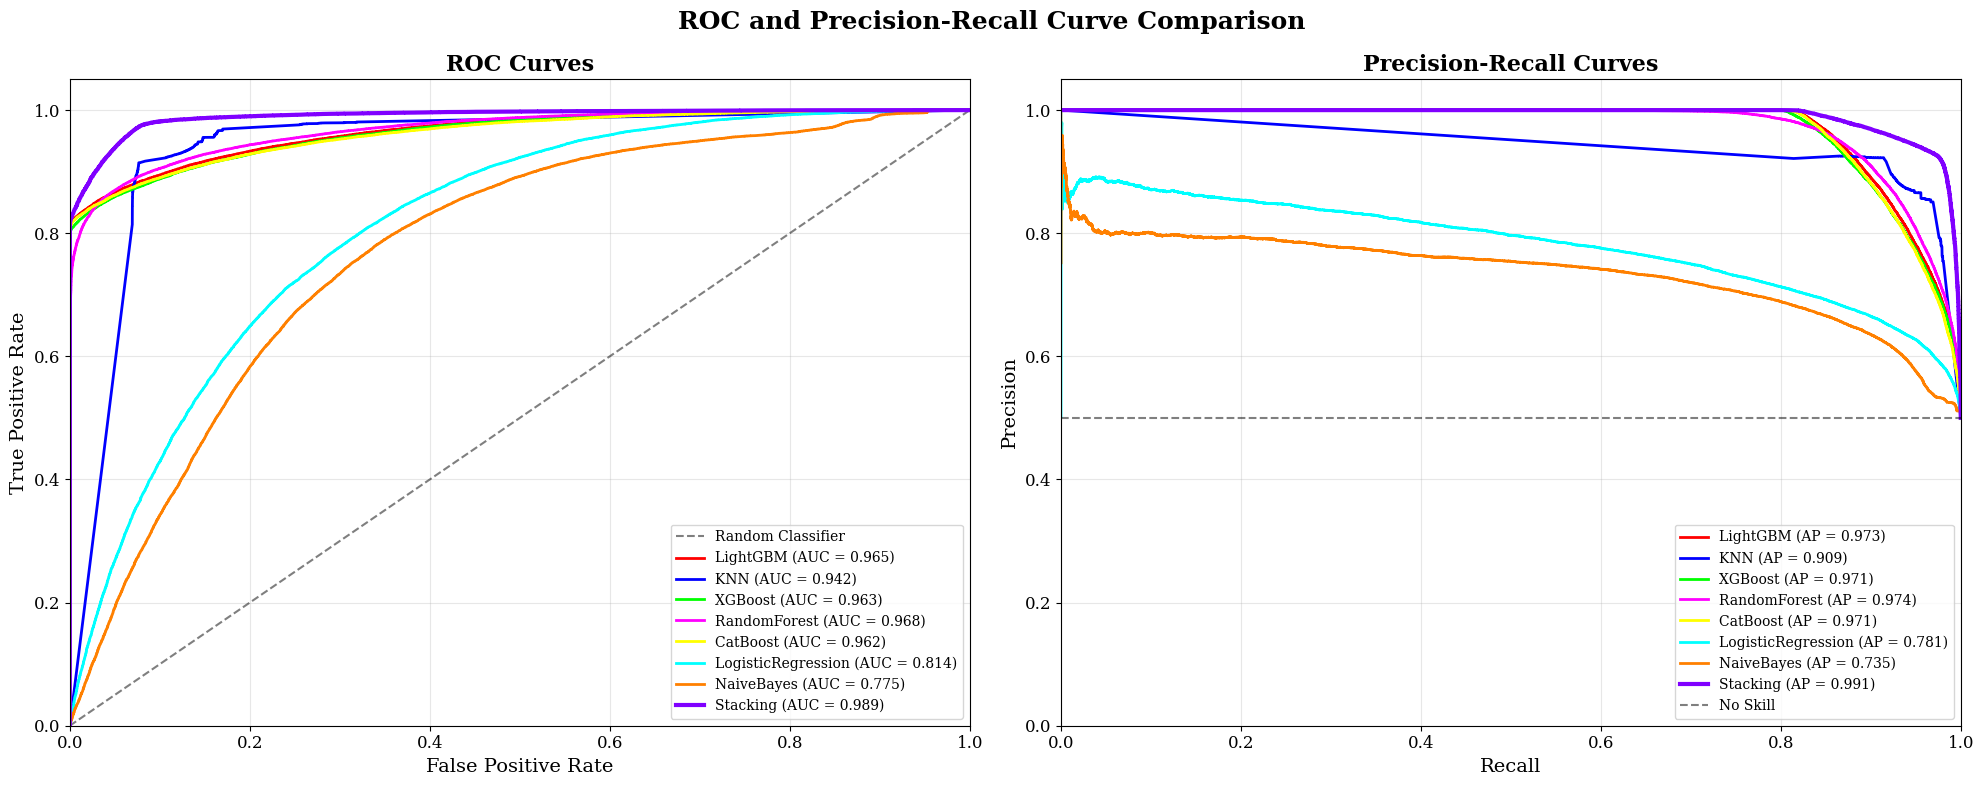

In [ ]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Create highly distinct color palette for all models
high_contrast_colors = [
    '#FF0000',  # Bright Red (Stacking)
    '#0000FF',  # Bright Blue
    '#00FF00',  # Bright Green
    '#FF00FF',  # Magenta
    '#FFFF00',  # Yellow
    '#00FFFF',  # Cyan
    '#FF8000',  # Orange
    '#8000FF',  # Purple
    '#008080'   # Teal
]


# Create figure for ROC and PR curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('ROC and Precision-Recall Curve Comparison', fontsize=18, fontweight='bold')

# ROC Curve Comparison
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
for i, (model_name, color) in enumerate(zip(results_df.index, high_contrast_colors)):
    if model_name in combine_models:
        model = combine_models[model_name]
        y_proba = model.predict_proba(X_test)[:, 1]
    elif model_name == 'Stacking':
        y_proba = y_proba_stack
    else:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    # Make Stacking curve thicker
    linewidth = 3 if model_name == 'Stacking' else 2
    ax1.plot(fpr, tpr, color=color, linewidth=linewidth,
             label=f'{model_name} (AUC = {roc_auc:.3f})')

ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=14)
ax1.set_ylabel('True Positive Rate', fontsize=14)
ax1.set_title('ROC Curves', fontsize=16, fontweight='bold')
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# Precision-Recall Curve Comparison
for i, (model_name, color) in enumerate(zip(results_df.index, high_contrast_colors)):
    if model_name in combine_models:
        model = combine_models[model_name]
        y_proba = model.predict_proba(X_test)[:, 1]
    elif model_name == 'Stacking':
        y_proba = y_proba_stack
    else:
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)

    # Make Stacking curve thicker
    linewidth = 3 if model_name == 'Stacking' else 2
    ax2.plot(recall, precision, color=color, linewidth=linewidth,
             label=f'{model_name} (AP = {pr_auc:.3f})')

# Add no-skill line for PR curve
no_skill = len(y_test[y_test==1]) / len(y_test)
ax2.plot([0, 1], [no_skill, no_skill], 'k--', alpha=0.5, label='No Skill')

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=14)
ax2.set_ylabel('Precision', fontsize=14)
ax2.set_title('Precision-Recall Curves', fontsize=16, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_pr_curves_comparison_updated_9.png", dpi=300, bbox_inches="tight")
plt.show()



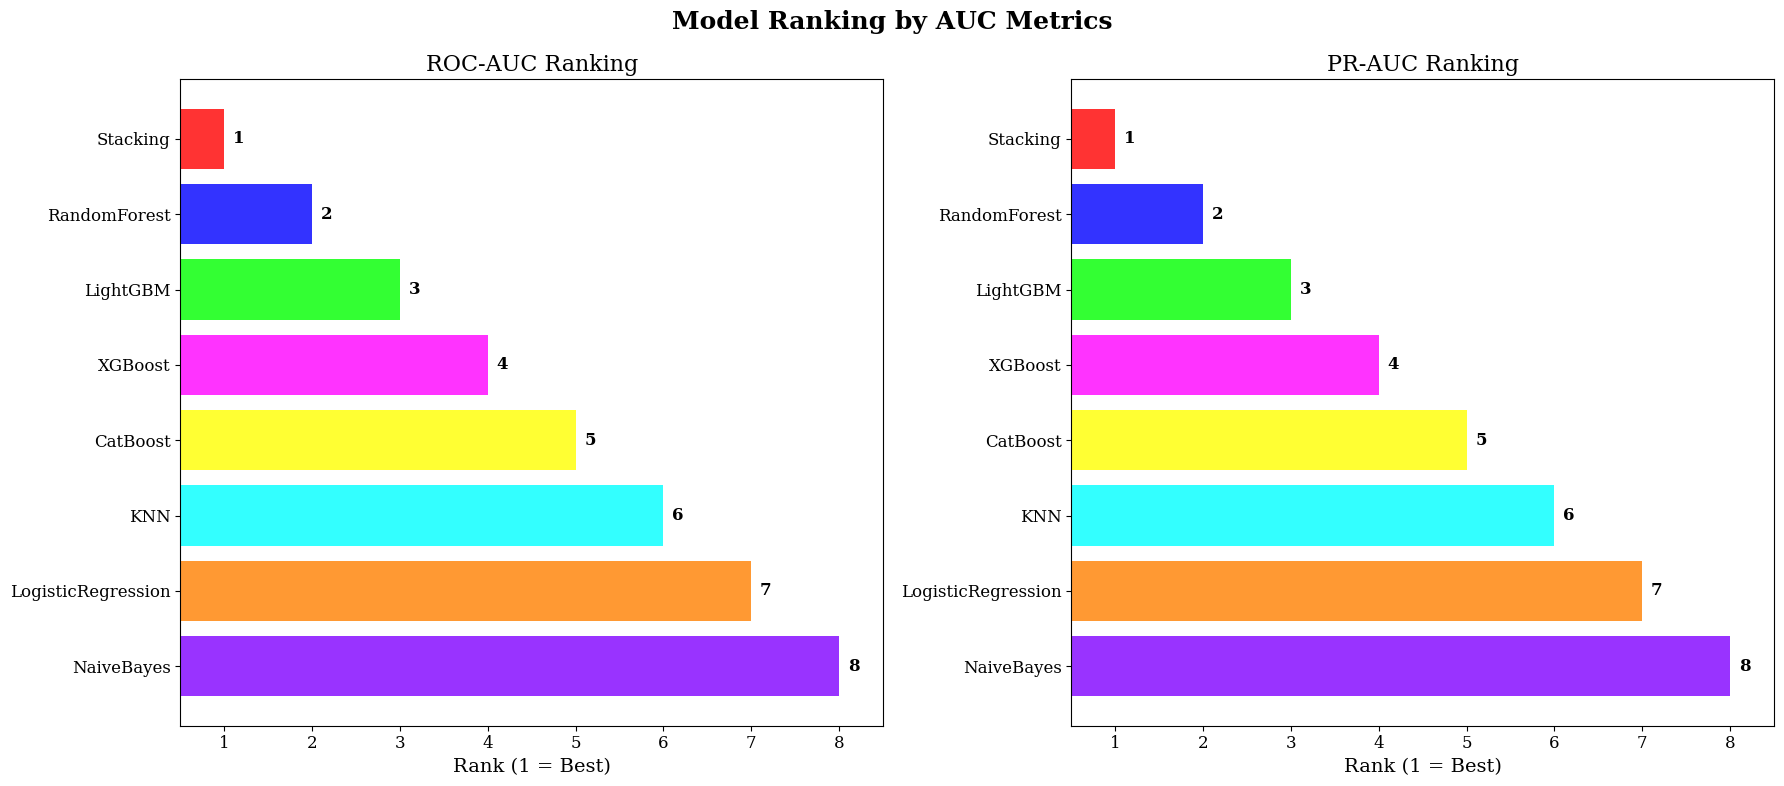

COMPREHENSIVE PERFORMANCE SUMMARY
                    ROC-AUC  PR-AUC
Model                              
Stacking             0.9895  0.9907
RandomForest         0.9678  0.9740
LightGBM             0.9651  0.9727
XGBoost              0.9628  0.9709
CatBoost             0.9619  0.9708
KNN                  0.9417  0.9094
LogisticRegression   0.8135  0.7814
NaiveBayes           0.7750  0.7354

PERFORMANCE RANKINGS
ROC-AUC Ranking:
1. Stacking (AUC = 0.9895)
2. RandomForest (AUC = 0.9678)
3. LightGBM (AUC = 0.9651)
4. XGBoost (AUC = 0.9628)
5. CatBoost (AUC = 0.9619)
6. KNN (AUC = 0.9417)
7. LogisticRegression (AUC = 0.8135)
8. NaiveBayes (AUC = 0.7750)

PR-AUC Ranking:
1. Stacking (AP = 0.9907)
2. RandomForest (AP = 0.9740)
3. LightGBM (AP = 0.9727)
4. XGBoost (AP = 0.9709)
5. CatBoost (AP = 0.9708)
6. KNN (AP = 0.9094)
7. LogisticRegression (AP = 0.7814)
8. NaiveBayes (AP = 0.7354)


In [ ]:
# Create performance ranking visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Model Ranking by AUC Metrics', fontsize=18, fontweight='bold')

# ROC-AUC Ranking
roc_rank = auc_df['ROC-AUC'].rank(ascending=False)
colors_roc = [high_contrast_colors[i] for i in range(len(roc_rank))]

bars1 = ax1.barh(range(len(roc_rank)), roc_rank.values, color=colors_roc, alpha=0.8)
ax1.set_yticks(range(len(roc_rank)))
ax1.set_yticklabels(roc_rank.index)
ax1.invert_yaxis()  # highest rank at the top
ax1.set_xlabel('Rank (1 = Best)', fontsize=14)
ax1.set_title('ROC-AUC Ranking', fontsize=16)
ax1.set_xlim(0.5, len(roc_rank)+0.5)

# Add rank values to bars
for i, bar in enumerate(bars1):
    width = bar.get_width()
    ax1.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontweight='bold')

# PR-AUC Ranking
pr_rank = auc_df['PR-AUC'].rank(ascending=False)
colors_pr = [high_contrast_colors[i] for i in range(len(pr_rank))]

bars2 = ax2.barh(range(len(pr_rank)), pr_rank.values, color=colors_pr, alpha=0.8)
ax2.set_yticks(range(len(pr_rank)))
ax2.set_yticklabels(pr_rank.index)
ax2.invert_yaxis()  # highest rank at the top
ax2.set_xlabel('Rank (1 = Best)', fontsize=14)
ax2.set_title('PR-AUC Ranking', fontsize=16)
ax2.set_xlim(0.5, len(pr_rank)+0.5)

# Add rank values to bars
for i, bar in enumerate(bars2):
    width = bar.get_width()
    ax2.text(width + 0.1, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig("auc_ranking_comparison_update_9.png", dpi=300, bbox_inches="tight")
plt.show()

# Print comprehensive performance summary
print("COMPREHENSIVE PERFORMANCE SUMMARY")
print("="*50)
print(auc_df.round(4))
print("\nPERFORMANCE RANKINGS")
print("="*30)
print("ROC-AUC Ranking:")
for i, (model, rank) in enumerate(roc_rank.items(), 1):
    print(f"{i}. {model} (AUC = {auc_df.loc[model, 'ROC-AUC']:.4f})")

print("\nPR-AUC Ranking:")
for i, (model, rank) in enumerate(pr_rank.items(), 1):
    print(f"{i}. {model} (AP = {auc_df.loc[model, 'PR-AUC']:.4f})")

In [ ]:
print("results_df index:", results_df.index.tolist())
print("auc_df index:", auc_df.index.tolist())


results_df index: ['LightGBM', 'KNN', 'XGBoost', 'RandomForest', 'CatBoost', 'LogisticRegression', 'NaiveBayes', 'Stacking', 'Linear SVM']
auc_df index: ['Stacking', 'RandomForest', 'LightGBM', 'XGBoost', 'CatBoost', 'KNN', 'LogisticRegression', 'NaiveBayes']


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

# Assuming best_linear_svc is your trained Linear SVM pipeline
y_scores_svc = best_linear_svc.decision_function(X_test)

auc_df.loc['Linear SVM'] = {
    'ROC-AUC': roc_auc_score(y_test, y_scores_svc),
    'PR-AUC': average_precision_score(y_test, y_scores_svc)
}


In [ ]:
# Extend your colors to cover all models
high_contrast_colors = [
    '#FF0000',  # Bright Red (Stacking)
    '#0000FF',  # Bright Blue
    '#00FF00',  # Bright Green
    '#FF00FF',  # Magenta
    '#FFFF00',  # Yellow
    '#00FFFF',  # Cyan
    '#FF8000',  # Orange
    '#8000FF',  # Purple
    '#A52A2A'   # Brown (Linear SVM)
]


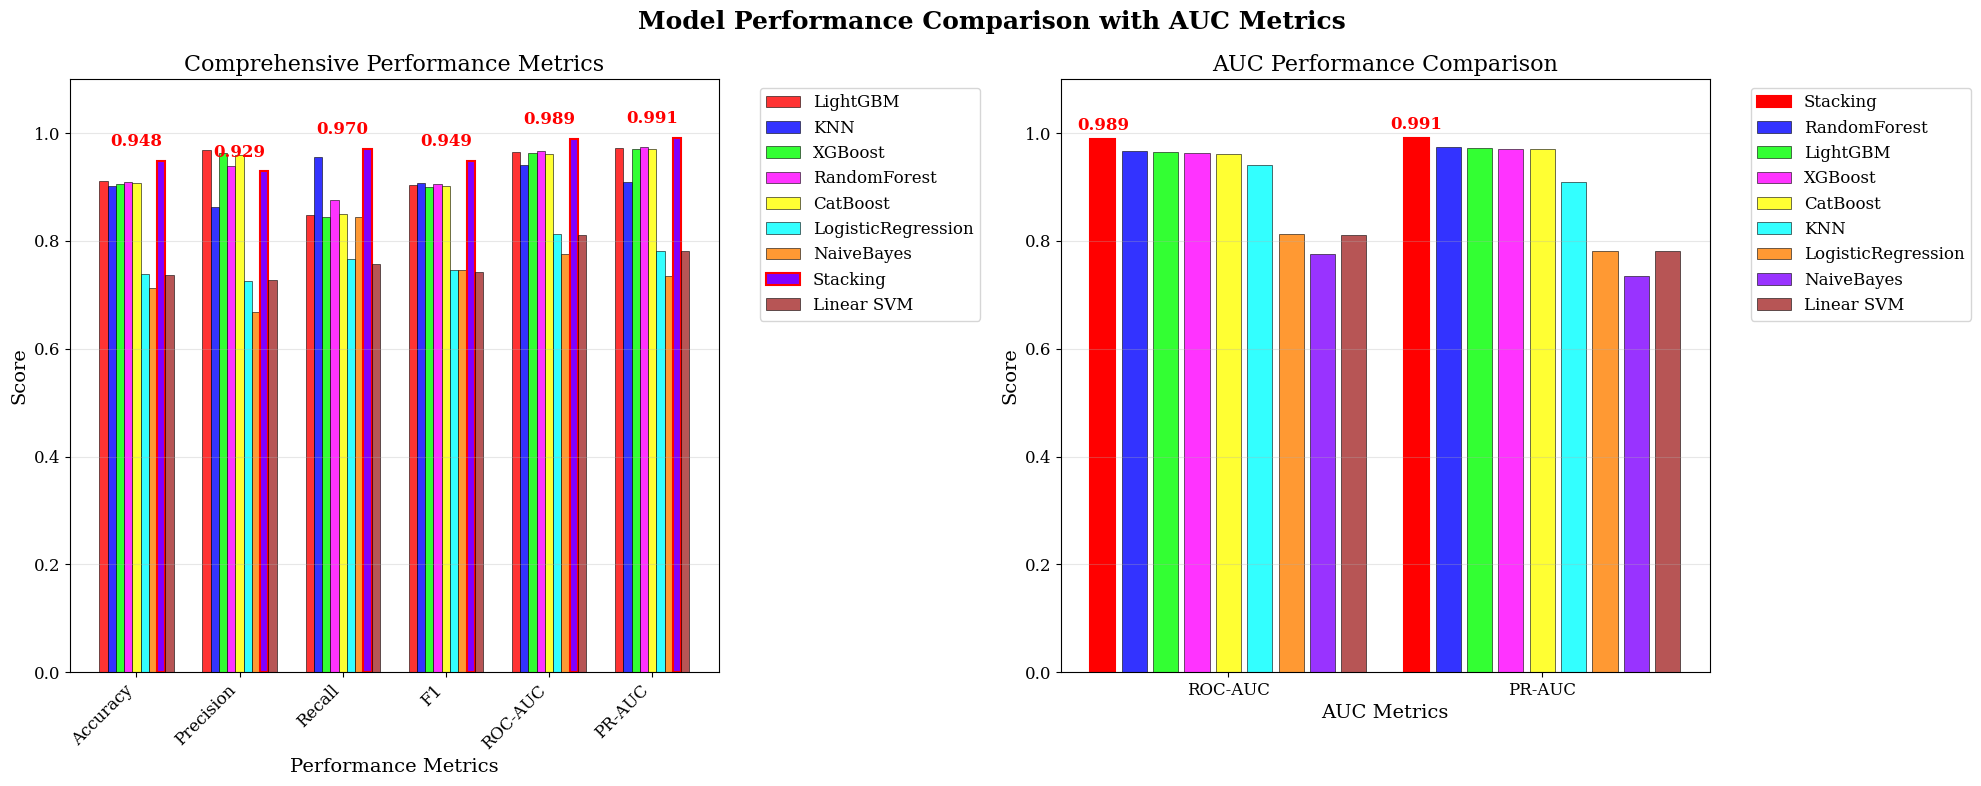

In [ ]:
# Create a comprehensive performance comparison with AUC metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Model Performance Comparison with AUC Metrics', fontsize=18, fontweight='bold')

# Combine all metrics including AUC
# Combine all metrics safely, avoiding KeyErrors
all_metrics_df = results_df.copy()
all_metrics_df['ROC-AUC'] = auc_df.reindex(results_df.index)['ROC-AUC'].values
all_metrics_df['PR-AUC'] = auc_df.reindex(results_df.index)['PR-AUC'].values

# 1. Bar chart for all metrics
x = np.arange(len(all_metrics_df.columns))
width = 0.08


for i, model in enumerate(all_metrics_df.index):
    offset = (i - len(all_metrics_df.index)/2) * width + width/2
    bars = ax1.bar(x + offset, all_metrics_df.loc[model], width,
                  label=model, color=high_contrast_colors[i], alpha=0.8,
                  edgecolor='black', linewidth=0.5)

    if model == 'Stacking':
        for bar in bars:
            bar.set_alpha(1.0)
            bar.set_edgecolor('red')
            bar.set_linewidth(1.5)


# Add value labels for Stacking only to reduce clutter
for j, metric in enumerate(all_metrics_df.columns):
    stacking_value = all_metrics_df.loc['Stacking', metric]
    ax1.text(j, stacking_value + 0.02, f'{stacking_value:.3f}',
             ha='center', va='bottom', fontweight='bold', color='red')

ax1.set_xlabel('Performance Metrics', fontsize=14)
ax1.set_ylabel('Score', fontsize=14)
ax1.set_title('Comprehensive Performance Metrics', fontsize=16)
ax1.set_xticks(x)
ax1.set_xticklabels(all_metrics_df.columns, rotation=45, ha='right')
ax1.set_ylim(0, 1.1)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(axis='y', alpha=0.3)

# 2. AUC comparison focused plot
auc_metrics = ['ROC-AUC', 'PR-AUC']
x_auc = np.arange(len(auc_metrics))

for i, model in enumerate(auc_df.index):
    values = [auc_df.loc[model, metric] for metric in auc_metrics]
    bars = ax2.bar(x_auc + i*0.1, values, 0.08,
                  label=model, color=high_contrast_colors[i], alpha=0.8,
                  edgecolor='black', linewidth=0.5)

    # Highlight Stacking model
    if model == 'Stacking':
        for bar in bars:
            bar.set_alpha(1.0)
            bar.set_edgecolor('red')
            bar.set_linewidth(1.5)

        # Add value labels for Stacking
        for j, metric in enumerate(auc_metrics):
            ax2.text(j + i*0.1, auc_df.loc[model, metric] + 0.01,
                    f'{auc_df.loc[model, metric]:.3f}', ha='center', va='bottom',
                    fontweight='bold', color='red')

ax2.set_xlabel('AUC Metrics', fontsize=14)
ax2.set_ylabel('Score', fontsize=14)
ax2.set_title('AUC Performance Comparison', fontsize=16)
ax2.set_xticks(x_auc + (len(auc_df.index)-1)*0.1/2)
ax2.set_xticklabels(auc_metrics)
ax2.set_ylim(0, 1.1)
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("comprehensive_auc_comparison_update_9.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
L_GBM_params = {
    "objective": "binary",
    "boosting_type": "gbdt",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 64,
    "max_depth": 7,
    "min_data_in_leaf": 100,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l1": 1.0,
    "lambda_l2": 1.0,
    "n_estimators": 1000,
    "n_jobs": -1,
    "random_state": 42
}
lgbm = LGBMClassifier(**L_GBM_params)

knn=KNeighborsClassifier(
    n_neighbors=3,
    weights='distance',
    p=1,
    n_jobs=-1
)


xgb = XGBClassifier(
    n_estimators=900,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


cat = CatBoostClassifier(
    iterations=5000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    task_type="CPU",
    verbose=0,
    od_type="Iter",
    od_wait=200
)








In [ ]:
import numpy as np
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score, classification_report


estimators = [
    ('lgbm', lgbm),
    ('xgb', xgb),
    ('rf', rf),
    ('cat', cat),
    ('knn',knn)
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LGBMClassifier(random_state=42, n_estimators=200, learning_rate=0.05),
    cv=5,
    passthrough=True
)

# Fit
stacking.fit(X_train, y_train)

# Predictions
y_proba_stack = stacking.predict_proba(X_test)[:, 1]

# 1️⃣ Default threshold (0.5)
y_pred_default = (y_proba_stack >= 0.5).astype(int)
print("Default Accuracy:", accuracy_score(y_test, y_pred_default))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_stack))
print("PR-AUC:", average_precision_score(y_test, y_proba_stack))
print(classification_report(y_test, y_pred_default))

# 2️⃣ Threshold optimization
best_acc = 0
best_thresh = 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    y_pred_thresh = (y_proba_stack >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print("\nBest Threshold:", best_thresh)
print("Best Accuracy:", best_acc)

# Final predictions with optimized threshold
y_pred_best = (y_proba_stack >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_best))


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:58:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] lambda_l2 is set=1.0, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.0
[LightGBM] [Warning] lambda_l1 is set=1.0, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.0
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] min_data_in_leaf is set=100, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=100
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:18:51] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:19:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:20:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:21:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:21:51] WARNING: /w

In [ ]:
from sklearn.metrics import confusion_matrix
import shap

import matplotlib.pyplot as plt
import seaborn as sns

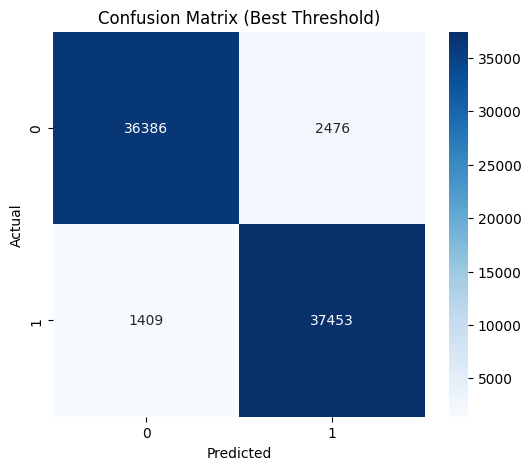

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Best Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ***SHAP for the stacking meta-model ( final LGBM)***

In [ ]:
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

base_names = [name for name, _ in stacking.estimators]
base_models = stacking.estimators_


meta_test = np.column_stack([m.predict_proba(X_test)[:, 1] for m in base_models])
meta_cols = [f"proba_{n}" for n in base_names]




In [ ]:
if stacking.passthrough:
    Z_test = pd.DataFrame(
        np.hstack([X_test.values, meta_test]),
        columns=list(X_test.columns) + meta_cols,
        index=X_test.index
    )
else:
    Z_test = pd.DataFrame(meta_test, columns=meta_cols, index=X_test.index)


In [ ]:

final_lgbm = stacking.final_estimator_
explainer = shap.TreeExplainer(final_lgbm)


In [ ]:
shap_values = explainer.shap_values(Z_test)
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    shap_to_plot = shap_values



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


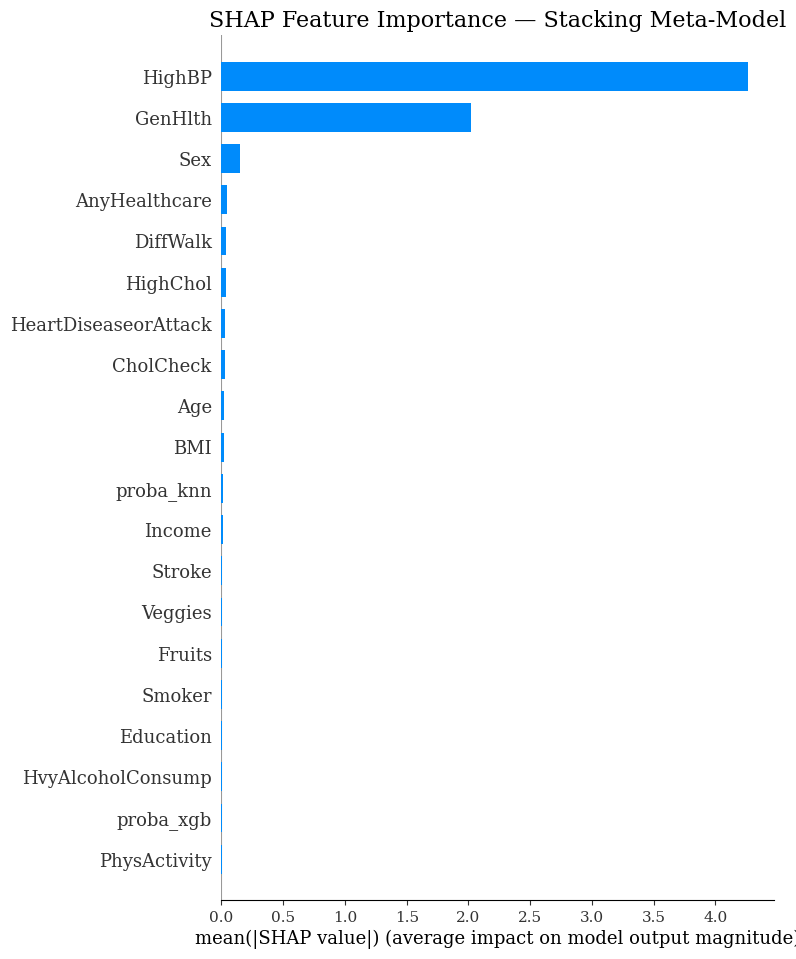

In [ ]:
plt.figure()
shap.summary_plot(shap_to_plot, Z_test, feature_names=Z_test.columns, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Stacking Meta-Model")
plt.savefig("Stacking Meta Model SHAP Feature Importance.png", dpi=300, bbox_inches="tight")
plt.show()

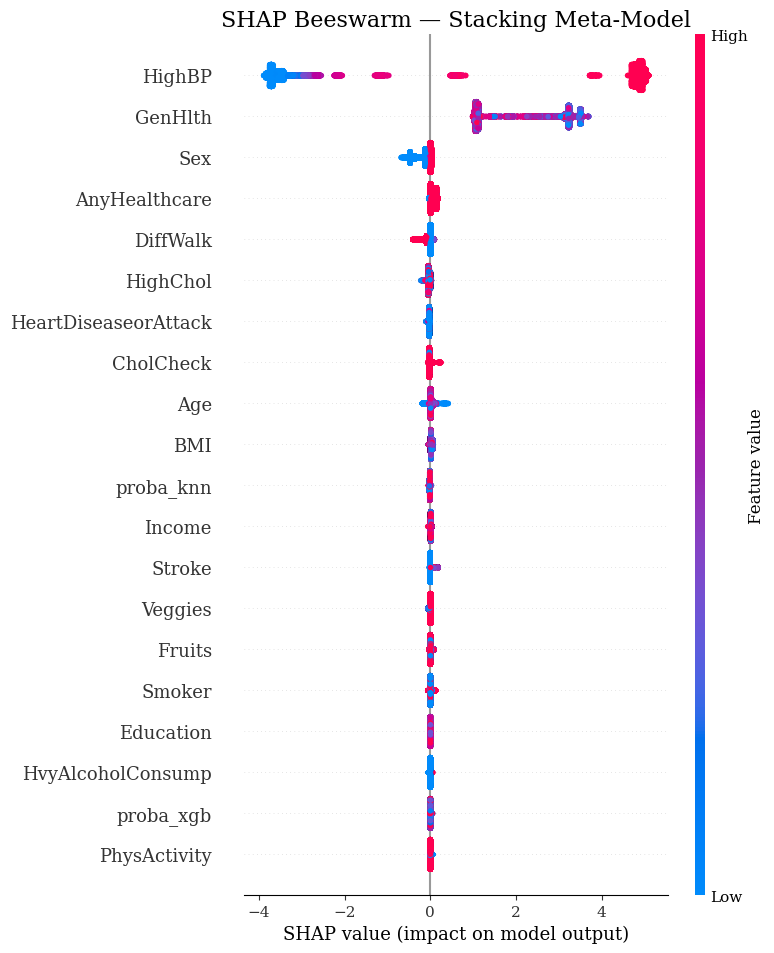

In [ ]:
plt.figure()
shap.summary_plot(shap_to_plot, Z_test, feature_names=Z_test.columns, show=False)
plt.savefig("Stacking Meta Model SHAP SHAP Beeswarm.png", dpi=300, bbox_inches="tight")
plt.title("SHAP Beeswarm — Stacking Meta-Model")
plt.show()

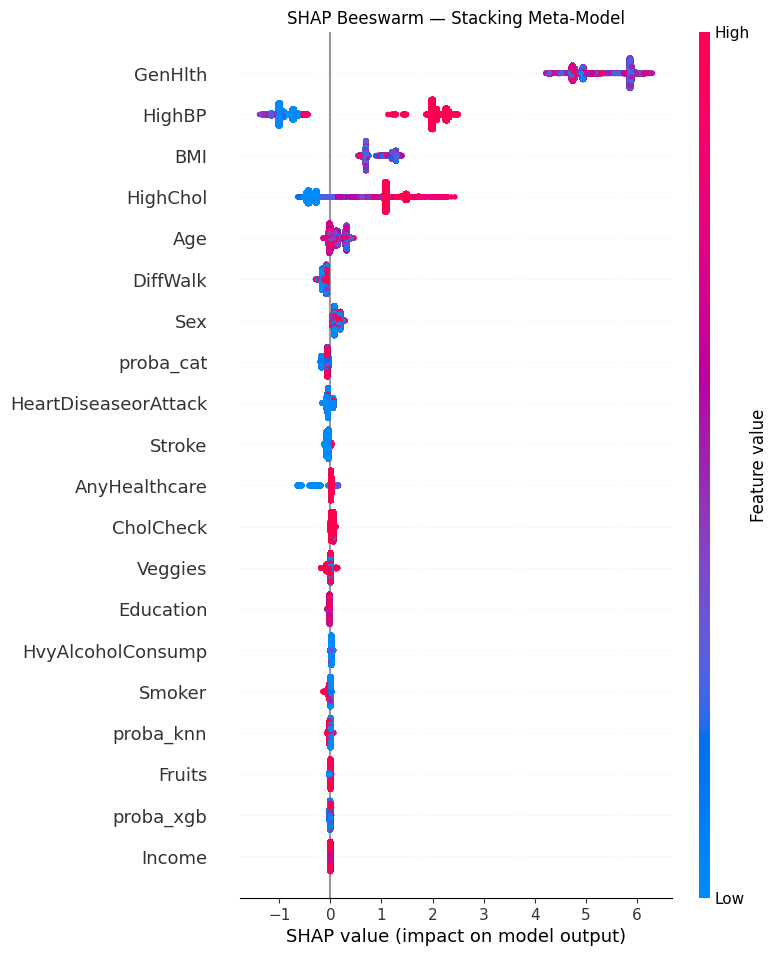

In [ ]:
plt.figure()
shap.summary_plot(shap_to_plot, Z_test, feature_names=Z_test.columns, show=False)
plt.savefig("Stacking Meta Model SHAP SHAP Beeswarm.png", dpi=300, bbox_inches="tight")
plt.title("SHAP Beeswarm — Stacking Meta-Model")
plt.show()

In [ ]:
print(stacking.named_estimators_)

{'knn': KNeighborsClassifier(n_jobs=-1, n_neighbors=3, p=1, weights='distance'), 'xgb': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=900, n_jobs=None,
              num_parallel_tree=None, ...)}


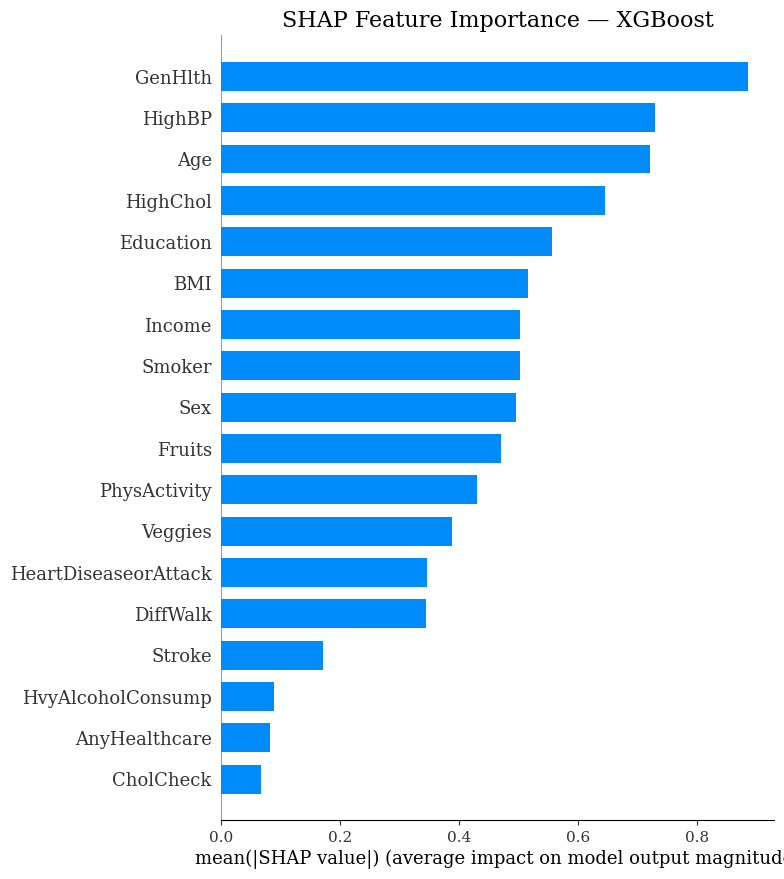

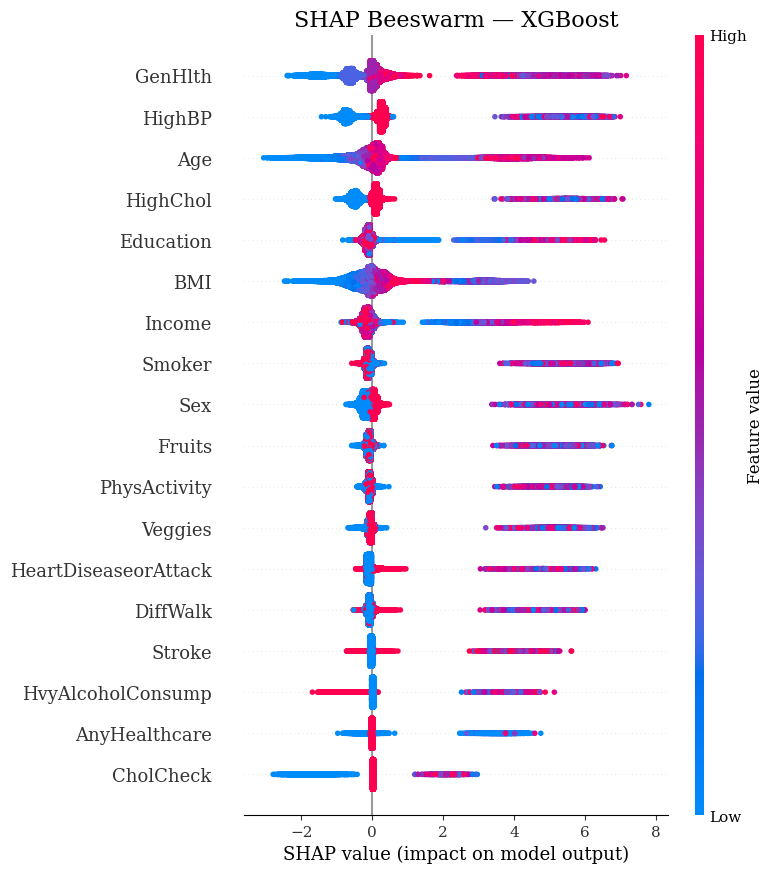

In [ ]:
import shap
import matplotlib.pyplot as plt

# Explainer
explainer_xgb = shap.TreeExplainer(stacking.named_estimators_['xgb'])
shap_values_xgb = explainer_xgb.shap_values(X_test)

# Bar plot
plt.figure()
shap.summary_plot(shap_values_xgb, X_test, feature_names=X_test.columns, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost")
plt.savefig("xgb_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Beeswarm plot
plt.figure()
shap.summary_plot(shap_values_xgb, X_test, feature_names=X_test.columns, show=False)
plt.title("SHAP Beeswarm — XGBoost")
plt.savefig("xgb_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
import shap
import matplotlib.pyplot as plt

# Subsample train and test to speed up Kernel SHAP
X_train_sample = X_train.sample(100, random_state=42)
X_test_sample = X_test.sample(50, random_state=42)

# Kernel Explainer for KNN
explainer_knn = shap.KernelExplainer(stacking.named_estimators_['knn'].predict, X_train_sample)
shap_values_knn = explainer_knn.shap_values(X_test_sample)

# 1. Bar plot
plt.figure(figsize=(8,6))
shap.summary_plot(shap_values_knn, X_test_sample, feature_names=X_test.columns, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — KNN")
plt.savefig("knn_shap_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. Beeswarm plot
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values_knn, X_test_sample, feature_names=X_test.columns, show=False)
plt.title("SHAP Beeswarm — KNN")
plt.savefig("knn_shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()


  0%|          | 0/50 [00:00<?, ?it/s]

**SHAP for the base models (tree models only)**

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


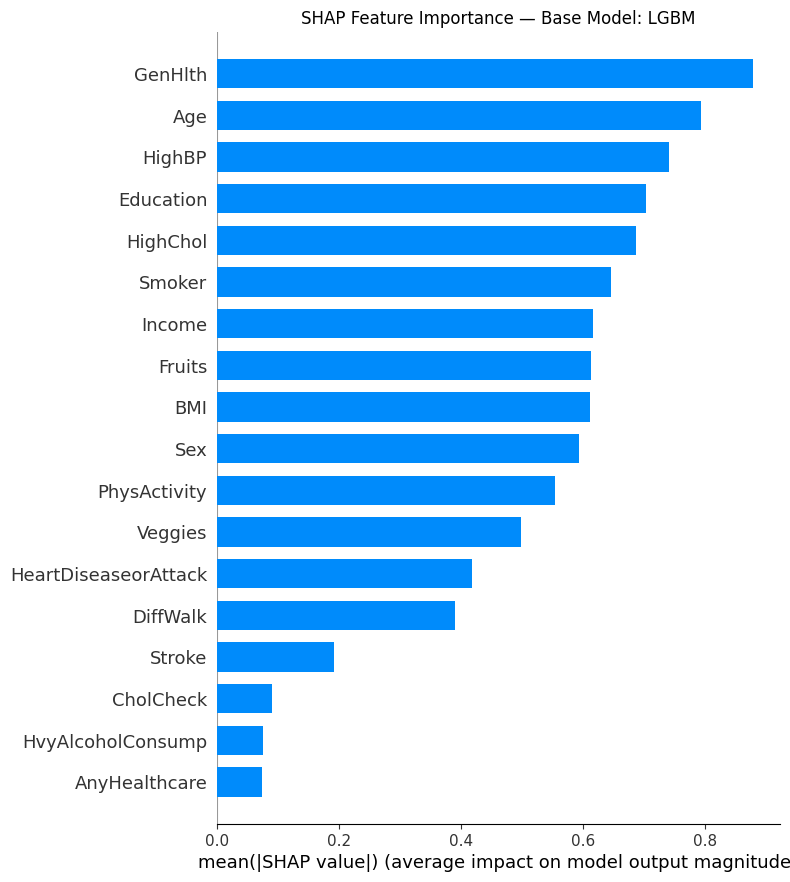

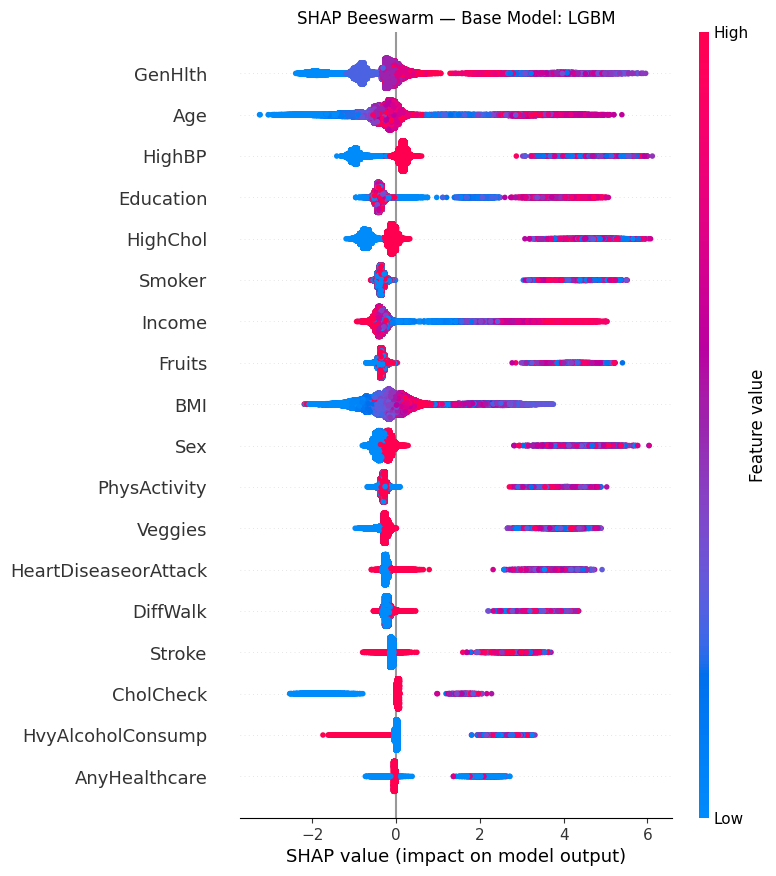

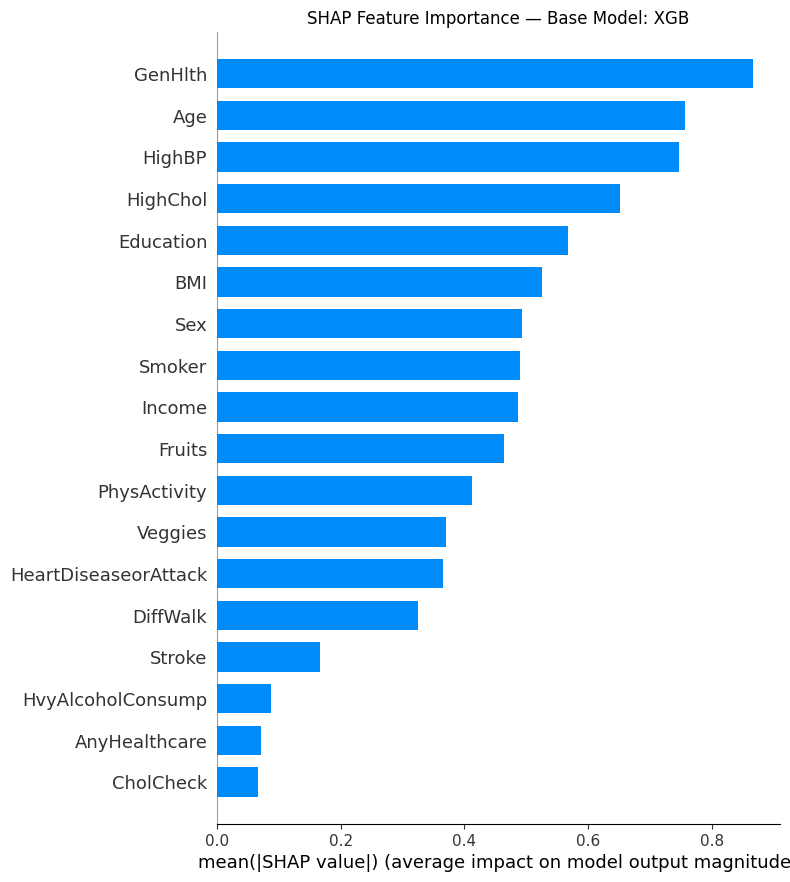

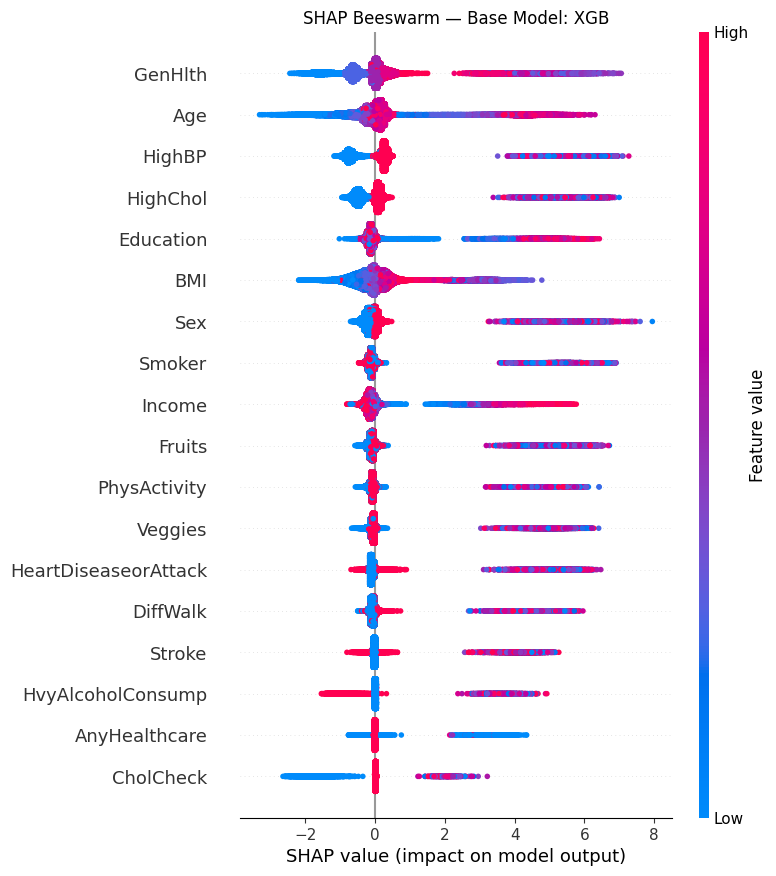

In [ ]:

fitted = stacking.named_estimators_

tree_models = []
for key in ['lgbm', 'xgb', 'rf', 'cat']:
    if key in fitted:
        tree_models.append((key, fitted[key]))

for name, model in tree_models:
    try:
        explainer = shap.TreeExplainer(model)
        base_shap = explainer.shap_values(X_test)

        if isinstance(base_shap, list):
            base_to_plot = base_shap[1] if len(base_shap) > 1 else base_shap[0]
        else:
            base_to_plot = base_shap

        plt.figure()
        shap.summary_plot(base_to_plot, X_test, feature_names=X_test.columns, plot_type="bar", show=False)
        plt.title(f"SHAP Feature Importance — Base Model: {name.upper()}")
        plt.savefig(f"{name}_shap_bar.png", dpi=300, bbox_inches="tight")
        plt.show()

        plt.figure()
        shap.summary_plot(base_to_plot, X_test, feature_names=X_test.columns, show=False)
        plt.title(f"SHAP Beeswarm — Base Model: {name.upper()}")
        plt.savefig(f"{name}_shap_beeswarm.png", dpi=300, bbox_inches="tight")
        plt.show()

    except Exception as e:
        print(f"SHAP failed for {name}: {e}")
